# Day 2 보너스: 전이학습 — HAM10000 Skin Lesion (7-class)

TB 데이터는 쉬워서 4가지 전략 간 차이가 잘 안 보인다 (거의 다 AUROC 0.99). 여기선 **극단적 불균형 + 7-class + 시각적 유사 쌍**을 가진 HAM10000 으로 전략/샘플링 효과를 눈에 띄게 확인한다.

## 사전 준비
- 런타임: **Accelerator → GPU T4 x2** (또는 P100)
- 데이터: 우측 `+ Add Input` → `Skin Cancer MNIST: HAM10000` (by kmader) 검색 후 add
  - 경로: `/kaggle/input/skin-cancer-mnist-ham10000/`
  - 메타데이터 CSV + 이미지 두 폴더 (`HAM10000_images_part_1`, `HAM10000_images_part_2`)

## 이 노트북의 차이점 (vs TB baseline)
1. **ImageFolder 못 씀** — CSV + 분할 이미지 폴더 구조 → Custom Dataset 필요
2. **main metric = macro-AUROC (One-vs-Rest)** — 다중 클래스용
3. 클래스별 AUROC / recall 리포트 (소수 클래스 `df`, `vasc` 성능 편차가 핵심)


## 데이터 소개 — HAM10000

- **10,015장** dermatoscopic 피부병변 사진, **7개 클래스**
- 분포: `nv 6,705 / mel 1,113 / bkl 1,099 / bcc 514 / akiec 327 / vasc 142 / df 115`
- 최다 vs 최소 = **약 58:1** — TB(5:1)보다 훨씬 심함
- 멜라노마(mel) ↔ 색소성 모반(nv) 같이 육안 구분이 어려운 쌍 다수
- 원본: [Kaggle — Skin Cancer MNIST: HAM10000](https://www.kaggle.com/datasets/kmader/skin-cancer-mnist-ham10000)


## 셀 1 — 공통 import & 경로

In [1]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 56.2 MB/s eta 0:00:0000:0100:01


In [2]:
# 한글 폰트 자동 설정
import subprocess, os, glob
import matplotlib as mpl, matplotlib.font_manager as fm, matplotlib.pyplot as plt
import koreanize_matplotlib

# def setup_korean_font():
#     is_colab = False
#     try:
#         import google.colab; is_colab = True
#     except ImportError: pass
#     if is_colab:
#         FONT_PATH = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
#         if not os.path.exists(FONT_PATH):
#             subprocess.run(["apt-get", "install", "-y", "fonts-nanum"], check=True)
#         for f in glob.glob(os.path.join(mpl.get_cachedir(), "*.json")):
#             os.remove(f)
#         if os.path.exists(FONT_PATH):
#             fm.fontManager.addfont(FONT_PATH)
#             plt.rcParams["font.family"] = "NanumGothic"
#     else:
#         import platform
#         os_name = platform.system()
#         font_name = 'AppleGothic' if os_name == 'Darwin' else 'Malgun Gothic' if os_name == 'Windows' else 'NanumGothic'
#         if any(font_name.lower() in f.name.lower() for f in fm.fontManager.ttflist):
#             plt.rcPa

In [3]:
import os
import copy
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm

try:
    import timm
except ImportError:
    os.system("pip install -q timm")
    import timm

# DATA_DIR = "/kaggle/input/skin-cancer-mnist-ham10000"
DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
META_CSV = f"{DATA_DIR}/HAM10000_metadata.csv"
IMG_DIRS = [f"{DATA_DIR}/HAM10000_images_part_1",
            f"{DATA_DIR}/HAM10000_images_part_2"]

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)
print("timm:", timm.__version__)
print("meta exists:", os.path.isfile(META_CSV), "->", META_CSV)


device: cuda
timm: 1.0.26
meta exists: True -> /kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv


## 셀 2 — 데이터 탐색 & 경로 매핑

이미지가 두 개의 폴더로 쪼개져 있고 메타데이터가 CSV 로 주어진다. 먼저 `image_id → file path` 맵을 만들고 CSV 에 붙인다.

총 10015 장
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64 

classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']


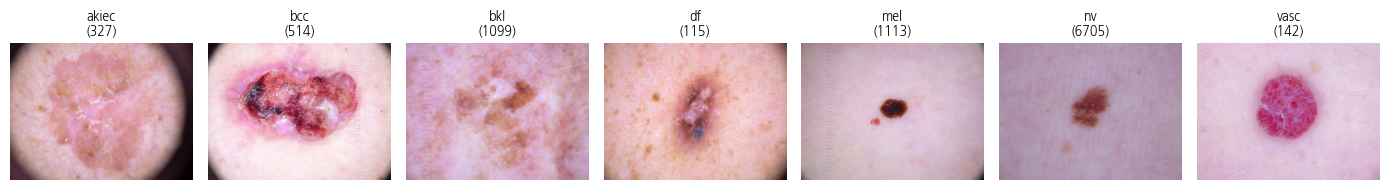

In [4]:
meta = pd.read_csv(META_CSV)
print("총", len(meta), "장")
print(meta["dx"].value_counts(), "\n")

CLASSES = sorted(meta["dx"].unique())      # ['akiec','bcc','bkl','df','mel','nv','vasc']
CLS2IDX = {c: i for i, c in enumerate(CLASSES)}
print("classes:", CLASSES)

# image_id → 실제 파일 경로
id2path = {}
for d in IMG_DIRS:
    for f in os.listdir(d):
        id2path[os.path.splitext(f)[0]] = os.path.join(d, f)

meta["path"]  = meta["image_id"].map(id2path)
meta["label"] = meta["dx"].map(CLS2IDX)
assert meta["path"].notna().all(), "매핑 안 된 image_id 있음"

# 샘플: 클래스별 한 장씩
fig, axes = plt.subplots(1, len(CLASSES), figsize=(14, 2.5))
for ax, c in zip(axes, CLASSES):
    row = meta[meta["dx"] == c].iloc[0]
    ax.imshow(Image.open(row["path"]))
    ax.set_title(f"{c}\n({(meta['dx']==c).sum()})", fontsize=9)
    ax.axis("off")
plt.tight_layout(); plt.show()


## 셀 2-b — 서브그룹 분석 (age / sex / localization)

HAM10000 메타데이터에는 진단 라벨 외에도 **환자 정보(나이/성별)와 병변 위치**가 같이 들어있다. 이걸 보면 불균형이 단순히 전체 수치 문제가 아니라 **구조적 패턴**이 있음을 알 수 있다 — 예) 특정 질환이 특정 나이대·부위에 집중돼 있는지, val 에서 편향이 성능 편차로 이어지는지.

아래 세 셀은 클래스 분포를 **age / sex / localization** 축으로 나눠 시각화한다. 학습 전에 데이터의 모양을 먼저 이해하는 게 목적 — 오류 분석(셀 11 이후)에서 "왜 그 클래스가 틀리나?" 에 힌트를 준다.

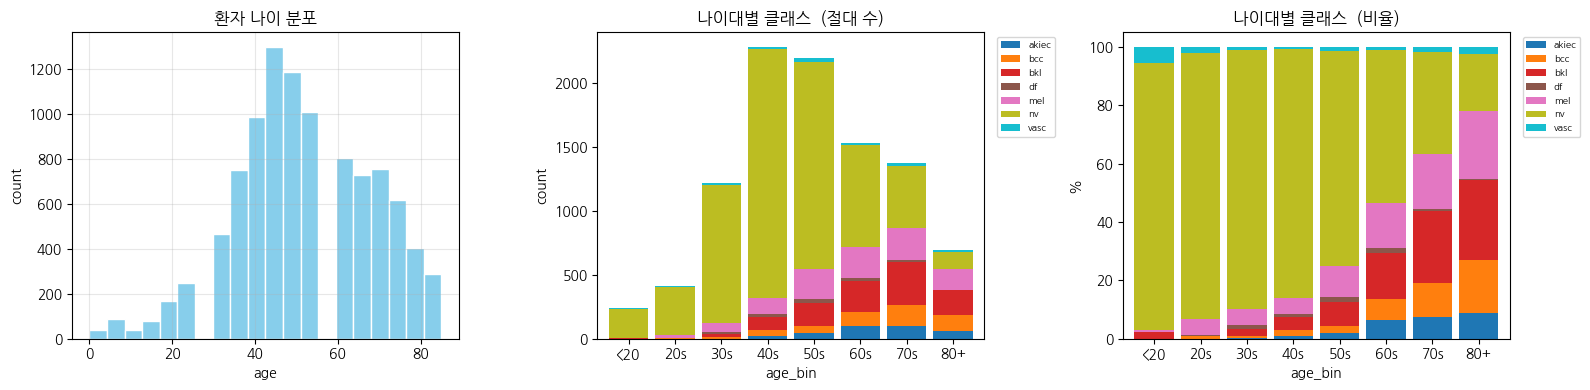

클래스별 나이 통계  (mean / median / std)
       mean  median   std
dx                       
akiec  66.5    70.0  11.5
bcc    66.8    70.0  13.7
bkl    64.3    65.0  14.1
df     53.0    50.0  13.6
mel    60.7    60.0  15.2
nv     46.5    45.0  15.2
vasc   51.4    55.0  21.6


In [13]:
# ── 나이 (age) ─────────────────────────────────────
age_bins  = [0, 20, 30, 40, 50, 60, 70, 80, 100]
age_label = ["<20", "20s", "30s", "40s", "50s", "60s", "70s", "80+"]
meta["age_bin"] = pd.cut(meta["age"], bins=age_bins, labels=age_label, right=False)

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

# (1) 나이 히스토그램
ax[0].hist(meta["age"].dropna(), bins=20, color="#87CEEB", edgecolor="white")
ax[0].set_xlabel("age"); ax[0].set_ylabel("count")
ax[0].set_title("환자 나이 분포"); ax[0].grid(alpha=0.3)

# (2) 나이대별 클래스 — 절대 수 (stacked)
counts = pd.crosstab(meta["age_bin"], meta["dx"])[CLASSES]
counts.plot(kind="bar", stacked=True, ax=ax[1], colormap="tab10", width=0.85)
ax[1].set_ylabel("count"); ax[1].set_title("나이대별 클래스  (절대 수)")
ax[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
ax[1].tick_params(axis="x", rotation=0)

# (3) 나이대별 클래스 — 비율 (stacked, row-normalize)
ratios = pd.crosstab(meta["age_bin"], meta["dx"], normalize="index")[CLASSES] * 100
ratios.plot(kind="bar", stacked=True, ax=ax[2], colormap="tab10", width=0.85)
ax[2].set_ylabel("%"); ax[2].set_title("나이대별 클래스  (비율)")
ax[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
ax[2].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

print("클래스별 나이 통계  (mean / median / std)")
print(meta.groupby("dx")["age"].agg(["mean", "median", "std"]).round(1))

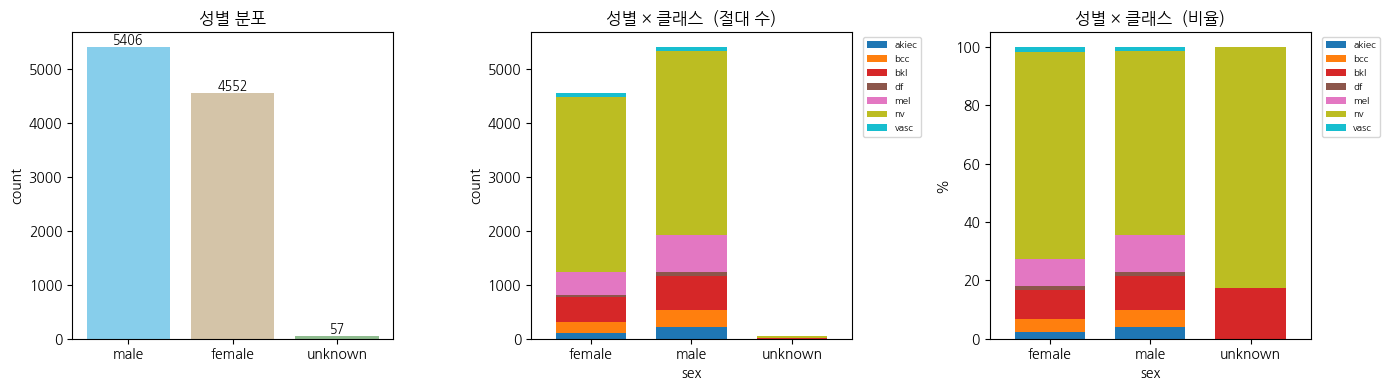

성별 × 클래스 교차표
dx       akiec  bcc   bkl   df   mel    nv  vasc    All
sex                                                    
female     106  197   463   52   424  3237    73   4552
male       221  317   626   63   689  3421    69   5406
unknown      0    0    10    0     0    47     0     57
All        327  514  1099  115  1113  6705   142  10015


In [14]:
# ── 성별 (sex) ─────────────────────────────────────
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# (1) 성별 샘플 수
sex_counts = meta["sex"].fillna("unknown").value_counts()
bar_colors = ["#87CEEB", "#D4C4A8", "#8FBC8F"][:len(sex_counts)]
ax[0].bar(sex_counts.index.astype(str), sex_counts.values, color=bar_colors)
ax[0].set_ylabel("count"); ax[0].set_title("성별 분포")
for i, v in enumerate(sex_counts.values):
    ax[0].text(i, v + max(sex_counts.values) * 0.01, str(v), ha="center", fontsize=9)

# (2) 성별 × 클래스 — 절대 수
counts = pd.crosstab(meta["sex"].fillna("unknown"), meta["dx"])[CLASSES]
counts.plot(kind="bar", stacked=True, ax=ax[1], colormap="tab10", width=0.7)
ax[1].set_ylabel("count"); ax[1].set_title("성별 × 클래스  (절대 수)")
ax[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
ax[1].tick_params(axis="x", rotation=0)

# (3) 성별 × 클래스 — 비율
ratios = pd.crosstab(meta["sex"].fillna("unknown"), meta["dx"], normalize="index")[CLASSES] * 100
ratios.plot(kind="bar", stacked=True, ax=ax[2], colormap="tab10", width=0.7)
ax[2].set_ylabel("%"); ax[2].set_title("성별 × 클래스  (비율)")
ax[2].legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
ax[2].tick_params(axis="x", rotation=0)

plt.tight_layout(); plt.show()

print("성별 × 클래스 교차표")
print(pd.crosstab(meta["sex"].fillna("unknown"), meta["dx"], margins=True))

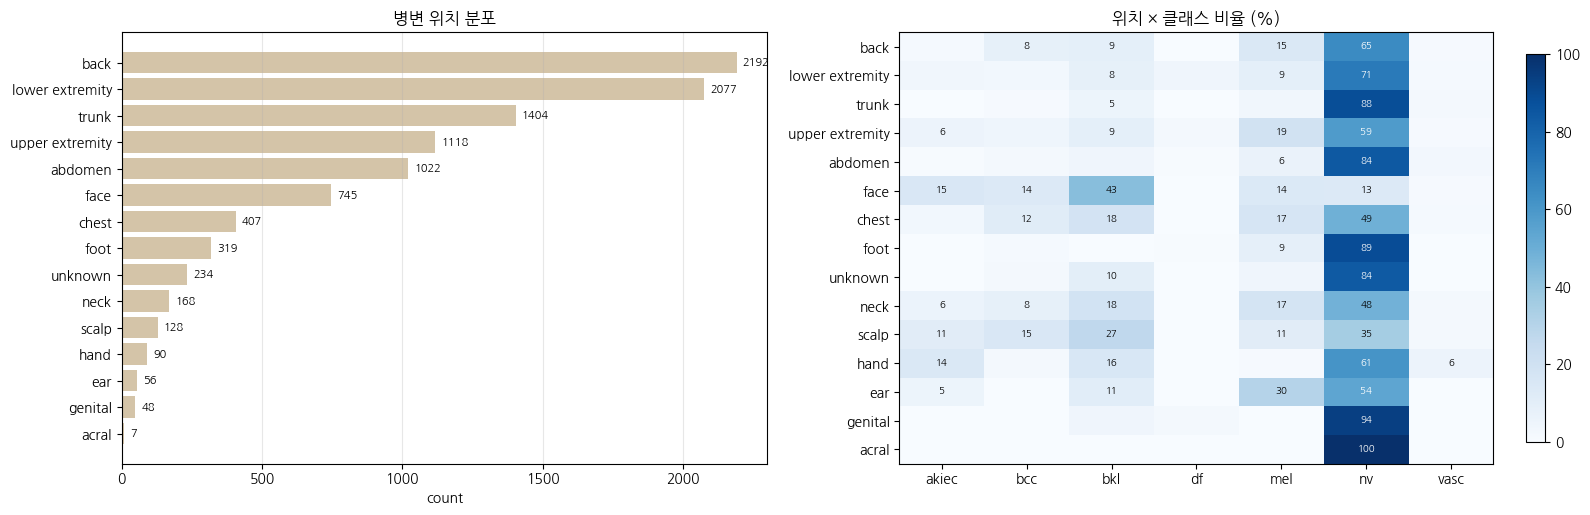


클래스별 상위 병변 위치  (top-3)
  akiec   face(113), lower extremity(65), upper extremity(62)
  bcc     back(186), face(101), lower extremity(58)
  bkl     face(319), back(202), lower extremity(174)
  df      lower extremity(82), upper extremity(24), abdomen(4)
  mel     back(324), upper extremity(213), lower extremity(192)
  nv      lower extremity(1479), back(1427), trunk(1241)
  vasc    trunk(31), lower extremity(27), abdomen(27)


In [15]:
# ── 병변 위치 (localization) ─────────────────────────
loc_count = meta["localization"].fillna("unknown").value_counts()

fig, ax = plt.subplots(1, 2, figsize=(16, max(5, len(loc_count) * 0.35)))

# (1) 위치별 샘플 수 — 가로 막대
ax[0].barh(loc_count.index, loc_count.values, color="#D4C4A8")
ax[0].invert_yaxis()
ax[0].set_xlabel("count"); ax[0].set_title("병변 위치 분포")
ax[0].grid(alpha=0.3, axis="x")
for i, v in enumerate(loc_count.values):
    ax[0].text(v + max(loc_count.values) * 0.01, i, str(v), va="center", fontsize=8)

# (2) 위치 × 클래스 비율 — heatmap
loc_cls = pd.crosstab(meta["localization"].fillna("unknown"), meta["dx"], normalize="index")[CLASSES] * 100
loc_cls = loc_cls.loc[loc_count.index]   # 빈도 순 정렬
im = ax[1].imshow(loc_cls.values, aspect="auto", cmap="Blues", vmin=0, vmax=100)
ax[1].set_xticks(range(len(CLASSES))); ax[1].set_xticklabels(CLASSES)
ax[1].set_yticks(range(len(loc_cls.index))); ax[1].set_yticklabels(loc_cls.index)
ax[1].set_title("위치 × 클래스 비율 (%)")
for i in range(len(loc_cls.index)):
    for j in range(len(CLASSES)):
        v = loc_cls.values[i, j]
        if v >= 5:
            ax[1].text(j, i, f"{v:.0f}", ha="center", va="center",
                       color="white" if v > 50 else "black", fontsize=7)
plt.colorbar(im, ax=ax[1], fraction=0.03)
plt.tight_layout(); plt.show()

# 클래스별로 가장 흔한 위치 top-3
print("\n클래스별 상위 병변 위치  (top-3)")
for c in CLASSES:
    top = meta[meta["dx"] == c]["localization"].value_counts().head(3)
    s = ", ".join(f"{k}({v})" for k, v in top.items())
    print(f"  {c:6s}  {s}")

## 셀 3 — Custom Dataset & DataLoader (stratified split + 샘플링)

CSV 기반이라 `ImageFolder` 못 쓰고 `Dataset` 직접 만든다. 수업 초반 `dataloader_custom_dataset.ipynb` 에서 연습한 구조와 같다.

클래스 불균형이 심하니까 **stratified split** 필수. 그리고 `sampling` 인자로 under / over / SMOTE 전략도 바로 꽂힌다.

**DataLoader 옵션**: Kaggle/Windows 에서 child process 에러 방지용 `num_workers=1` + `persistent_workers=True`.

In [16]:
IMG_SIZE = 224
BATCH = 64
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
val_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


class HAMDataset(Dataset):
    """CSV 행들에서 (path, label) 리스트를 받아 이미지를 로드한다."""
    def __init__(self, paths, labels, transform):
        self.paths  = np.asarray(paths)
        self.labels = np.asarray(labels)
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        return self.transform(img), int(self.labels[i])


class _SMOTEDataset(Dataset):
    """SMOTE로 합성된 작은(H=W=SMOTE_SIZE) 이미지를 학습 시 IMG_SIZE로 upsample + 증강."""
    def __init__(self, X, y, target_size, mean, std):
        self.X = X
        self.y = y
        self.resize = transforms.Resize((target_size, target_size), antialias=True)
        self.normalize = transforms.Normalize(mean, std)
        self.flip = transforms.RandomHorizontalFlip()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        x = self.resize(self.X[i])
        x = self.flip(x)
        x = self.normalize(x)
        return x, int(self.y[i].item())


def _ensure_imblearn():
    try:
        import imblearn  # noqa: F401
    except ImportError:
        os.system("pip install -q imbalanced-learn")


def _apply_sampling(paths, labels, strategy):
    if strategy == "none":
        return HAMDataset(paths, labels, train_tf), "none"

    _ensure_imblearn()
    before = dict(zip(*np.unique(labels, return_counts=True)))

    if strategy in ("under", "over"):
        from imblearn.under_sampling import RandomUnderSampler
        from imblearn.over_sampling import RandomOverSampler
        sampler = RandomUnderSampler(random_state=SEED) if strategy == "under" else RandomOverSampler(random_state=SEED)
        idx = np.arange(len(paths)).reshape(-1, 1)
        X_res, y_res = sampler.fit_resample(idx, labels)
        sel = X_res.flatten()
        after = dict(zip(*np.unique(y_res, return_counts=True)))
        return HAMDataset(paths[sel], labels[sel], train_tf), f"{strategy} {before} -> {after}"

    if strategy == "smote":
        from imblearn.over_sampling import SMOTE
        SMOTE_SIZE = 64
        small_tf = transforms.Compose([
            transforms.Resize((SMOTE_SIZE, SMOTE_SIZE)),
            transforms.ToTensor(),
        ])
        Xs = []
        for p in tqdm(paths, desc=f"preload @{SMOTE_SIZE}px for SMOTE", leave=False):
            img = small_tf(Image.open(p).convert("RGB"))
            Xs.append(img.numpy().reshape(-1))
        X = np.stack(Xs)
        sm = SMOTE(random_state=SEED)
        X_res, y_res = sm.fit_resample(X, labels)
        after = dict(zip(*np.unique(y_res, return_counts=True)))
        X_tensor = torch.from_numpy(X_res.reshape(-1, 3, SMOTE_SIZE, SMOTE_SIZE)).float()
        y_tensor = torch.from_numpy(y_res).long()
        ds = _SMOTEDataset(X_tensor, y_tensor, IMG_SIZE, IMAGENET_MEAN, IMAGENET_STD)
        return ds, f"smote {before} -> {after} (synth @ {SMOTE_SIZE}px)"

    raise ValueError(f"unknown sampling: {strategy!r} (use 'none' | 'under' | 'over' | 'smote')")


def make_loaders(meta_df, val_ratio=0.2, sampling="none"):
    train_df, val_df = train_test_split(
        meta_df, test_size=val_ratio, stratify=meta_df["label"], random_state=SEED,
    )
    train_set, log = _apply_sampling(
        train_df["path"].values, train_df["label"].values, sampling,
    )
    val_set = HAMDataset(val_df["path"].values, val_df["label"].values, val_tf)

    train_loader = DataLoader(
        train_set, batch_size=BATCH, shuffle=True,
        num_workers=1, pin_memory=True, persistent_workers=True,
    )
    val_loader = DataLoader(
        val_set, batch_size=BATCH, shuffle=False,
        num_workers=1, pin_memory=True, persistent_workers=True,
    )
    print(f"sampling: {log}")
    print(f"train {len(train_set)}장 / val {len(val_set)}장")
    return train_loader, val_loader


train_loader, val_loader = make_loaders(meta, sampling="none")


sampling: none
train 8012장 / val 2003장


## 셀 4 — 모델 빌더 (timm, 4전략)

| strategy | pretrained | trainable |
|---|---|---|
| `classifier` | ✅ | head만 |
| `full` | ✅ | 전체 |
| `gradual` | ✅ | head → 전체 |
| `scratch` | ❌ | 전체 |

`timm.create_model(...)` 한 줄로 수백 개 모델 중 선택 가능. head 위치가 달라도 `model.get_classifier()` 로 일관되게 처리.

In [17]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             46 bits physical, 48 bits virtual
  Byte Order:                Little Endian
CPU(s):                      4
  On-line CPU(s) list:       0-3
Vendor ID:                   GenuineIntel
  Model name:                Intel(R) Xeon(R) CPU @ 2.00GHz
    CPU family:              6
    Model:                   85
    Thread(s) per core:      2
    Core(s) per socket:      2
    Socket(s):               1
    Stepping:                3
    BogoMIPS:                4000.38
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ss h
                             t syscall nx pdpe1gb rdtscp lm constant_tsc rep_goo
                             d nopl xtopology nonstop_tsc cpuid tsc_known_freq p
                             ni pclmulqdq ssse3 fma cx16 pcid sse4_1 sse4_2 x2ap
                   

In [19]:
NUM_CLASSES = len(CLASSES)

AVAILABLE_ARCHS = [
    "resnet18",              # 11.7M  가볍고 빠름 (기본)
    "resnet50",              # 25.6M
    "efficientnet_b0",       #  5.3M
    "convnext_tiny",         # 28.6M
    "vit_tiny_patch16_224",  #  5.7M
]


def _classifier_param_ids(model):
    return {id(p) for p in model.get_classifier().parameters()}


def build_model(arch="resnet18", strategy="classifier"):
    pretrained = strategy != "scratch"
    model = timm.create_model(arch, pretrained=pretrained, num_classes=NUM_CLASSES)

    if strategy in ("classifier", "gradual"):
        cls_ids = _classifier_param_ids(model)
        for p in model.parameters():
            p.requires_grad = id(p) in cls_ids
    else:
        for p in model.parameters():
            p.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"[{arch} / {strategy}] trainable {trainable:,} / total {total:,} ({trainable/total*100:.2f}%)")
    return model.to(device)


def unfreeze_all(model, lr_backbone=5e-4, lr_head=5e-4):
    for p in model.parameters():
        p.requires_grad = True
    cls_ids = _classifier_param_ids(model)
    backbone = [p for p in model.parameters() if id(p) not in cls_ids]
    head     = [p for p in model.parameters() if id(p) in cls_ids]
    return optim.Adam([
        {"params": backbone, "lr": lr_backbone},
        {"params": head,     "lr": lr_head},
    ])


## 셀 5 — 학습 루프 + EarlyStopping (main = **macro-AUROC**)

7-class 이므로 AUROC는 `roc_auc_score(..., multi_class="ovr", average="macro")` — 각 클래스를 One-vs-Rest 로 AUROC 계산 후 단순 평균.

EarlyStopping: `val_auroc`가 `patience` epoch 동안 개선되지 않으면 중단, 최고 시점 가중치 자동 복원.

In [20]:
class EarlyStopping:
    """val_auroc 최대화 기준."""
    def __init__(self, patience=3, min_delta=0.0):
        self.patience = patience
        self.min_delta = min_delta
        self.best = -float("inf")
        self.counter = 0
        self.best_state = None
        self.should_stop = False

    def step(self, val_metric, model):
        if val_metric > self.best + self.min_delta:
            self.best = val_metric
            self.counter = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return self.should_stop

    def restore(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def run_epoch(model, loader, criterion, optimizer, device, train=True, desc=""):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)
    with ctx:
        for x, y in pbar:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            all_probs.append(torch.softmax(logits, dim=1).detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())
            total_loss += loss.item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += x.size(0)
            pbar.set_postfix(loss=f"{total_loss/total:.3f}", acc=f"{correct/total:.3f}")
    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)
    try:
        # 7-class: One-vs-Rest macro
        auroc = roc_auc_score(all_labels, all_probs, multi_class="ovr", average="macro")
    except ValueError:
        auroc = float("nan")
    return total_loss / total, correct / total, auroc


def train_model(model, train_loader, val_loader, device, epochs=8, lr=3e-3, patience=3, optimizer=None):
    criterion = nn.CrossEntropyLoss()
    if optimizer is None:
        optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)
    stopper = EarlyStopping(patience=patience)
    history = {
        "train_loss": [], "train_acc": [], "train_auroc": [],
        "val_loss":   [], "val_acc":   [], "val_auroc":   [],
    }

    epoch_bar = tqdm(range(1, epochs + 1), desc="epochs", dynamic_ncols=True)
    for epoch in epoch_bar:
        t0 = time.time()
        tl, ta, t_auc = run_epoch(model, train_loader, criterion, optimizer, device,
                                  train=True,  desc=f"[{epoch:02d}/{epochs}] train")
        vl, va, v_auc = run_epoch(model, val_loader,   criterion, optimizer, device,
                                  train=False, desc=f"[{epoch:02d}/{epochs}]   val")
        history["train_loss"].append(tl); history["train_acc"].append(ta); history["train_auroc"].append(t_auc)
        history["val_loss"].append(vl);   history["val_acc"].append(va);   history["val_auroc"].append(v_auc)
        stopped = stopper.step(v_auc, model)
        tag = "*best" if stopper.counter == 0 else f"({stopper.counter}/{patience})"
        dt = time.time() - t0
        tqdm.write(
            f"[{epoch:02d}/{epochs}] "
            f"train loss={tl:.3f} acc={ta:.3f} auroc={t_auc:.3f} | "
            f"val loss={vl:.3f} acc={va:.3f} auroc={v_auc:.3f} | "
            f"{dt:.1f}s {tag}"
        )
        epoch_bar.set_postfix(val_auroc=f"{v_auc:.3f}", best_auroc=f"{stopper.best:.3f}")
        if stopped:
            tqdm.write(f"[early stop] val_auroc 개선 없음 {patience} epoch -> 종료")
            break
    stopper.restore(model)
    print(f"최고 val_auroc 시점 가중치로 복원 (best={stopper.best:.3f})")
    return history


## 셀 6 — 실험 A: classifier tuning (baseline)

Backbone freeze, head만 학습. 7-class head 라 파라미터 수가 TB(2-class)보다 조금 늘지만 여전히 전체의 ~0.004%.

In [27]:
model_A = build_model(arch="resnet18", strategy="classifier")
history_A = train_model(model_A, train_loader, val_loader, device, epochs=8, lr=3e-3, patience=3)


[resnet18 / classifier] trainable 3,591 / total 11,180,103 (0.03%)


epochs:   0%|          | 0/8 [00:00<?, ?it/s]

[01/8] train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[01/8] train loss=0.973 acc=0.681 auroc=0.733 | val loss=0.870 acc=0.714 auroc=0.829 | 117.2s *best


...

[07/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[07/8] train loss=0.687 acc=0.749 auroc=0.914 | val loss=0.707 acc=0.743 auroc=0.901 | 109.8s *best


[08/8] train:   0%|          | 0/126 [00:00<?, ?it/s]

[08/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[08/8] train loss=0.681 acc=0.748 auroc=0.916 | val loss=0.696 acc=0.748 auroc=0.905 | 111.5s *best
최고 val_auroc 시점 가중치로 복원 (best=0.905)


## 셀 7 — 실험 B: full fine-tuning

전체 파라미터를 작은 lr(`5e-4`)로 학습. 도메인 차이가 큰 의료 데이터에 효과적일 수 있음.

In [21]:
model_B = build_model(arch="resnet18", strategy="full")
history_B = train_model(model_B, train_loader, val_loader, device, epochs=8, lr=5e-4, patience=3)


model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

[resnet18 / full] trainable 11,180,103 / total 11,180,103 (100.00%)


epochs:   0%|          | 0/8 [00:00<?, ?it/s]

[01/8] train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

...

[07/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[07/8] train loss=0.267 acc=0.904 auroc=0.988 | val loss=0.433 acc=0.862 auroc=0.973 | 117.8s *best


[08/8] train:   0%|          | 0/126 [00:00<?, ?it/s]

[08/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[08/8] train loss=0.232 acc=0.915 auroc=0.991 | val loss=0.528 acc=0.836 auroc=0.965 | 116.4s (1/3)
최고 val_auroc 시점 가중치로 복원 (best=0.973)


## 셀 8 — 실험 C: gradual unfreezing

Stage A: head 안정화 → Stage B: 전체 unfreeze + 작은 lr.

In [22]:
model_C = build_model(arch="resnet18", strategy="gradual")
print("--- Stage A: head only ---")
h_C1 = train_model(model_C, train_loader, val_loader, device, epochs=4, lr=3e-3, patience=2)

print("\n--- Stage B: unfreeze all, lr=5e-4 ---")
opt_C = unfreeze_all(model_C, lr_backbone=5e-4, lr_head=5e-4)
h_C2 = train_model(model_C, train_loader, val_loader, device, epochs=8, patience=3, optimizer=opt_C)

history_C = {k: h_C1[k] + h_C2[k] for k in h_C1}


[resnet18 / gradual] trainable 3,591 / total 11,180,103 (0.03%)
--- Stage A: head only ---


epochs:   0%|          | 0/4 [00:00<?, ?it/s]

[01/4] train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/4]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[01/4] train loss=0.972 acc=0.683 auroc=0.735 | val loss=0.835 acc=0.705 auroc=0.822 | 116.9s *best


...

[07/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[07/8] train loss=0.218 acc=0.922 auroc=0.992 | val loss=0.441 acc=0.848 auroc=0.970 | 112.7s *best


[08/8] train:   0%|          | 0/126 [00:00<?, ?it/s]

[08/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[08/8] train loss=0.198 acc=0.930 auroc=0.993 | val loss=0.460 acc=0.848 auroc=0.970 | 114.1s *best
최고 val_auroc 시점 가중치로 복원 (best=0.970)


## 셀 9 — 실험 D: from scratch

pretrained 없이 랜덤 초기값부터. 10K장 + 7-class + 불균형이라 큰 격차가 기대된다.

In [25]:
model_D = build_model(arch="resnet18", strategy="scratch")
history_D = train_model(model_D, train_loader, val_loader, device, epochs=8, lr=3e-3, patience=3)


[resnet18 / scratch] trainable 11,180,103 / total 11,180,103 (100.00%)


epochs:   0%|          | 0/8 [00:00<?, ?it/s]

[01/8] train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[01/8] train loss=0.968 acc=0.662 auroc=0.771 | val loss=0.958 acc=0.642 auroc=0.831 | 117.8s *best


...

[07/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[07/8] train loss=0.716 acc=0.733 auroc=0.901 | val loss=0.744 acc=0.740 auroc=0.896 | 114.9s (2/3)


[08/8] train:   0%|          | 0/126 [00:00<?, ?it/s]

[08/8]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[08/8] train loss=0.690 acc=0.744 auroc=0.910 | val loss=0.683 acc=0.754 auroc=0.918 | 113.7s *best
최고 val_auroc 시점 가중치로 복원 (best=0.918)


## 셀 10 — 네 전략 비교

val_loss / val_acc / **val macro-AUROC** 곡선 겹치기.

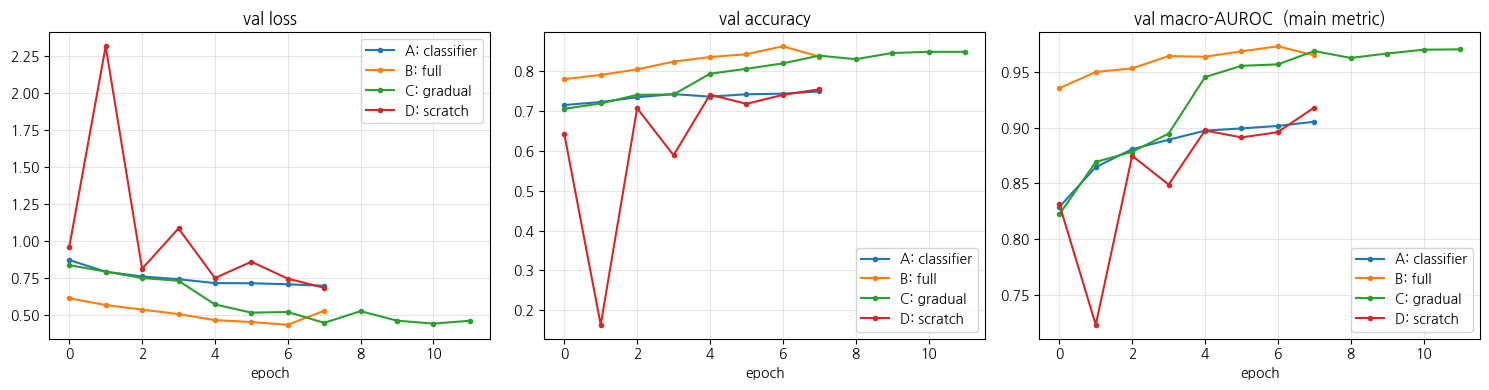


전략별 최고 val macro-AUROC
  A: classifier        best_val_auroc=0.905  best_val_acc=0.748
  B: full              best_val_auroc=0.973  best_val_acc=0.862
  C: gradual           best_val_auroc=0.970  best_val_acc=0.848
  D: scratch           best_val_auroc=0.918  best_val_acc=0.754


In [28]:
def plot_compare(histories, labels):
    fig, ax = plt.subplots(1, 3, figsize=(15, 4))
    for h, lb in zip(histories, labels):
        ax[0].plot(h["val_loss"],  label=lb, marker="o", markersize=3)
        ax[1].plot(h["val_acc"],   label=lb, marker="o", markersize=3)
        ax[2].plot(h["val_auroc"], label=lb, marker="o", markersize=3)
    ax[0].set_title("val loss");     ax[0].set_xlabel("epoch"); ax[0].legend(); ax[0].grid(alpha=0.3)
    ax[1].set_title("val accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend(); ax[1].grid(alpha=0.3)
    ax[2].set_title("val macro-AUROC  (main metric)"); ax[2].set_xlabel("epoch"); ax[2].legend(); ax[2].grid(alpha=0.3)
    plt.tight_layout(); plt.show()

    print("\n전략별 최고 val macro-AUROC")
    for h, lb in zip(histories, labels):
        print(f"  {lb:20s} best_val_auroc={max(h['val_auroc']):.3f}  best_val_acc={max(h['val_acc']):.3f}")

plot_compare(
    [history_A, history_B, history_C, history_D],
    ["A: classifier", "B: full", "C: gradual", "D: scratch"],
)


## 셀 11 — 평가: confusion matrix + 클래스별 AUROC + 분류 리포트

macro 평균 뒤에 숨은 성능 편차를 본다. `df`, `vasc` 같은 소수 클래스는 개별 AUROC가 전체보다 한참 낮을 가능성.

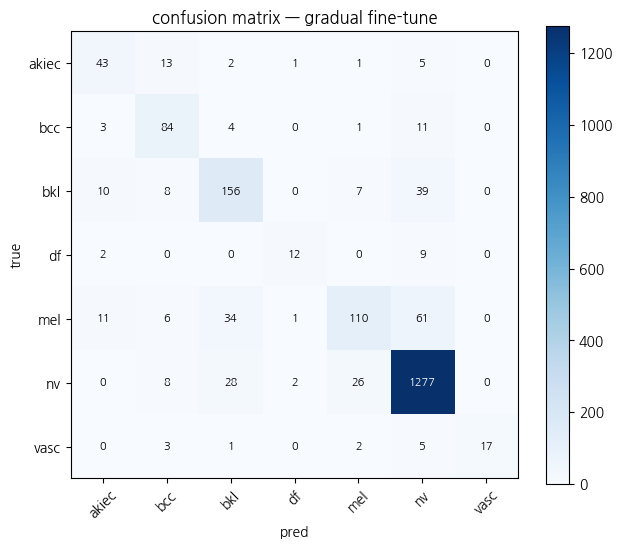

클래스별 AUROC
  akiec   0.964
  bcc     0.983
  bkl     0.948
  df      0.991
  mel     0.923
  nv      0.962
  vasc    0.998
macro-AUROC: 0.9668

              precision    recall  f1-score   support

       akiec      0.623     0.662     0.642        65
         bcc      0.689     0.816     0.747       103
         bkl      0.693     0.709     0.701       220
          df      0.750     0.522     0.615        23
         mel      0.748     0.493     0.595       223
          nv      0.908     0.952     0.929      1341
        vasc      1.000     0.607     0.756        28

    accuracy                          0.848      2003
   macro avg      0.773     0.680     0.712      2003
weighted avg      0.845     0.848     0.842      2003



In [26]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate(model, loader, class_names, title=""):
    model.eval()
    preds, ys, probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            logits = model(x.to(device))
            preds.append(logits.argmax(1).cpu().numpy())
            probs.append(torch.softmax(logits, 1).cpu().numpy())
            ys.append(y.numpy())
    preds = np.concatenate(preds); ys = np.concatenate(ys); probs = np.concatenate(probs)

    # Confusion matrix
    cm = confusion_matrix(ys, preds)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45); ax.set_yticklabels(class_names)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=8)
    ax.set_xlabel("pred"); ax.set_ylabel("true"); ax.set_title(f"confusion matrix — {title}")
    plt.colorbar(im); plt.tight_layout(); plt.show()

    # 클래스별 AUROC (macro에 숨은 편차 확인)
    per_class_auc = roc_auc_score(ys, probs, multi_class="ovr", average=None)
    macro_auc     = roc_auc_score(ys, probs, multi_class="ovr", average="macro")
    print("클래스별 AUROC")
    for c, v in zip(class_names, per_class_auc):
        print(f"  {c:6s}  {v:.3f}")
    print(f"macro-AUROC: {macro_auc:.4f}")
    print()
    print(classification_report(ys, preds, target_names=class_names, digits=3))

evaluate(model_C, val_loader, CLASSES, title="gradual fine-tune")


## 셀 11-b — 샘플링 전략 비교 (여기서 진짜 효과가 보인다)

HAM10000 은 58:1 불균형이라 샘플링이 macro-AUROC 를 꽤 밀어올린다. classifier 전략을 고정하고 샘플링만 바꿔 비교.

시간이 빡빡하면 `strategies = ["none", "over"]` 정도만 돌려도 된다.


================ sampling = none ================
sampling: none
train 8012장 / val 2003장
[resnet18 / classifier] trainable 3,591 / total 11,180,103 (0.03%)


epochs:   0%|          | 0/6 [00:00<?, ?it/s]

[01/6] train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[01/6] train loss=0.970 acc=0.680 auroc=0.738 | val loss=0.882 acc=0.712 auroc=0.835 | 106.6s *best


...

[03/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[03/6] train loss=0.871 acc=0.686 auroc=0.931 | val loss=1.255 acc=0.544 auroc=0.756 | 86.7s (1/2)


[04/6] train:   0%|          | 0/587 [00:00<?, ?it/s]

[04/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[04/6] train loss=0.839 acc=0.696 auroc=0.935 | val loss=1.230 acc=0.557 auroc=0.752 | 86.6s (2/2)
[early stop] val_auroc 개선 없음 2 epoch -> 종료
최고 val_auroc 시점 가중치로 복원 (best=0.766)


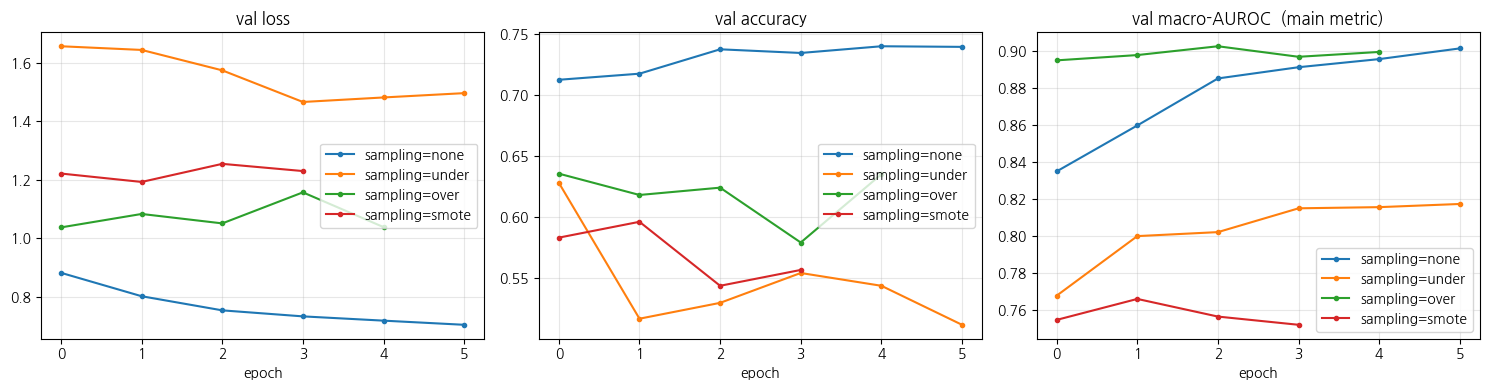


전략별 최고 val macro-AUROC
  sampling=none        best_val_auroc=0.902  best_val_acc=0.740
  sampling=under       best_val_auroc=0.817  best_val_acc=0.628
  sampling=over        best_val_auroc=0.903  best_val_acc=0.636
  sampling=smote       best_val_auroc=0.766  best_val_acc=0.596


In [27]:
strategies = ["none", "under", "over", "smote"]
sampling_histories = {}

for strat in strategies:
    print(f"\n================ sampling = {strat} ================")
    train_loader_s, val_loader_s = make_loaders(meta, sampling=strat)
    model_s = build_model(arch="resnet18", strategy="classifier")
    sampling_histories[strat] = train_model(
        model_s, train_loader_s, val_loader_s, device,
        epochs=6, lr=3e-3, patience=2,
    )

plot_compare(
    [sampling_histories[s] for s in strategies],
    [f"sampling={s}" for s in strategies],
)


## 셀 12 — 관찰 포인트

기대되는 양상 (macro-AUROC 기준):

- **D (scratch)**: 0.70~0.80 근방에 머무름. 10K장/7-class로는 ImageNet 없이는 버겁다
- **A (classifier)**: 0.85~0.90. head만 학습인데도 많이 올라온다 — ImageNet feature의 힘
- **B (full)**: lr만 맞으면 A 위로 올라감, 크면 오히려 손상
- **C (gradual)**: 대개 최고. Stage B 에서 뚜렷이 추가 상승

### 샘플링 효과 (셀 11-b)
- `over` / `smote` 가 macro-AUROC 를 0.02~0.05 정도 밀어올리는 게 보통 관찰됨
- `under` 는 `df`, `vasc` 개수 맞추느라 데이터가 너무 줄어 오히려 떨어질 때가 있음
- **클래스별 AUROC** 로 보면 효과가 더 선명 — 소수 클래스만 크게 개선되는 패턴

### 서브그룹 관찰 (셀 2-b 연결)
- 셀 2-b 에서 본 구조적 편향(`bcc`·`akiec` 는 고령 + 얼굴·손등, `nv` 는 전 연령 + 몸통)이 **오류 분포**에 그대로 나타나는지 셀 11 confusion matrix 와 겹쳐서 확인
- val 샘플 중 특정 나이대·성별이 drop 되면 특정 클래스 recall 이 무너지지 않는지 체크 (stratified split 이라 크게 틀어지진 않지만 소수 클래스는 주의)

### 더 해볼 것

1. **클래스 가중 loss**: `class_weights = compute_class_weight("balanced", ...)`; `nn.CrossEntropyLoss(weight=torch.tensor(class_weights, dtype=torch.float).to(device))`. 샘플링과 어느 쪽이 유리?
2. **다른 backbone**: `efficientnet_b0` / `convnext_tiny` — 작은 모델 대비 얼마나 차이?
3. **해상도 영향**: IMG_SIZE 를 224 -> 384 로 올리면 성능 vs 학습시간 trade-off
4. **TTA (Test-Time Augmentation)**: 평가 시 flip 5장 평균으로 macro-AUROC 추가 상승 가능
5. **서브그룹 성능 평가**: 오류 분석 시 성별·나이대별 macro-AUROC 를 따로 뽑으면 특정 그룹에만 모델이 약한지 드러남


### 1. 클래스 가중 loss
- 가중 loss 학습

sampling: none
train 8012장 / val 2003장
class weights
akiec : 4.375
bcc   : 2.783
bkl   : 1.302
df    : 12.441
mel   : 1.285
nv    : 0.213
vasc  : 10.075
[resnet18 / classifier] trainable 3,591 / total 11,180,103 (0.03%)


weighted epochs:   0%|          | 0/6 [00:00<?, ?it/s]

[01/6] weighted train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/6] weighted val:   0%|          | 0/32 [00:00<?, ?it/s]

[01/6] train loss=1.631 acc=0.522 auroc=0.776 | val loss=1.512 acc=0.495 auroc=0.834 | 104.3s *best


...

[05/6] weighted val:   0%|          | 0/32 [00:00<?, ?it/s]

[05/6] train loss=1.141 acc=0.618 auroc=0.898 | val loss=1.290 acc=0.584 auroc=0.877 | 104.1s *best


[06/6] weighted train:   0%|          | 0/126 [00:00<?, ?it/s]

[06/6] weighted val:   0%|          | 0/32 [00:00<?, ?it/s]

[06/6] train loss=1.120 acc=0.617 auroc=0.898 | val loss=1.245 acc=0.604 auroc=0.883 | 105.0s *best
최고 val_auroc 시점 가중치로 복원 (best=0.883)


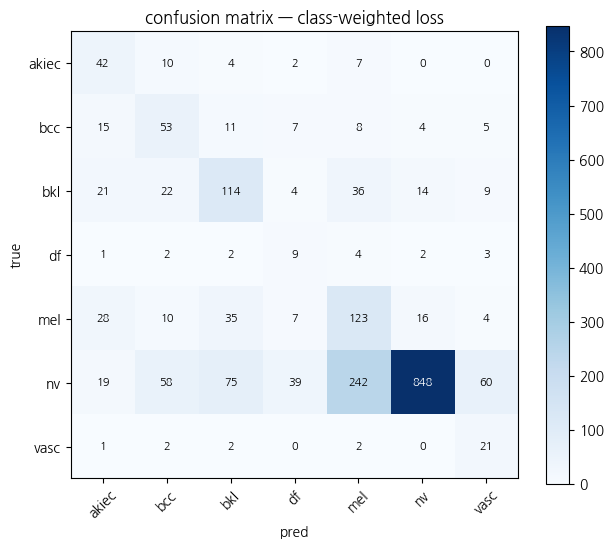

클래스별 AUROC
  akiec   0.928
  bcc     0.903
  bkl     0.866
  df      0.859
  mel     0.795
  nv      0.899
  vasc    0.929
macro-AUROC: 0.8829

              precision    recall  f1-score   support

       akiec      0.331     0.646     0.438        65
         bcc      0.338     0.515     0.408       103
         bkl      0.469     0.518     0.492       220
          df      0.132     0.391     0.198        23
         mel      0.291     0.552     0.381       223
          nv      0.959     0.632     0.762      1341
        vasc      0.206     0.750     0.323        28

    accuracy                          0.604      2003
   macro avg      0.389     0.572     0.429      2003
weighted avg      0.759     0.604     0.649      2003



In [29]:
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import roc_auc_score
import copy, time
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from tqdm.notebook import tqdm

def train_model_weighted(model, train_loader, val_loader, device, class_weights, epochs=8, lr=3e-3, patience=3, optimizer=None):
    weight_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)
    criterion = nn.CrossEntropyLoss(weight=weight_tensor)

    if optimizer is None:
        optimizer = optim.Adam([p for p in model.parameters() if p.requires_grad], lr=lr)

    stopper = EarlyStopping(patience=patience)
    history = {
        "train_loss": [], "train_acc": [], "train_auroc": [],
        "val_loss": [], "val_acc": [], "val_auroc": [],
    }

    epoch_bar = tqdm(range(1, epochs + 1), desc="weighted epochs", dynamic_ncols=True)

    for epoch in epoch_bar:
        t0 = time.time()

        tl, ta, t_auc = run_epoch(
            model, train_loader, criterion, optimizer, device,
            train=True, desc=f"[{epoch:02d}/{epochs}] weighted train"
        )
        vl, va, v_auc = run_epoch(
            model, val_loader, criterion, optimizer, device,
            train=False, desc=f"[{epoch:02d}/{epochs}] weighted val"
        )

        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["train_auroc"].append(t_auc)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        history["val_auroc"].append(v_auc)

        stopped = stopper.step(v_auc, model)
        tag = "*best" if stopper.counter == 0 else f"({stopper.counter}/{patience})"

        print(
            f"[{epoch:02d}/{epochs}] "
            f"train loss={tl:.3f} acc={ta:.3f} auroc={t_auc:.3f} | "
            f"val loss={vl:.3f} acc={va:.3f} auroc={v_auc:.3f} | "
            f"{time.time() - t0:.1f}s {tag}"
        )

        epoch_bar.set_postfix(val_auroc=f"{v_auc:.3f}", best_auroc=f"{stopper.best:.3f}")

        if stopped:
            print(f"[early stop] val_auroc 개선 없음 {patience} epoch -> 종료")
            break

    stopper.restore(model)
    print(f"최고 val_auroc 시점 가중치로 복원 (best={stopper.best:.3f})")
    return history


train_loader_none, val_loader_none = make_loaders(meta, sampling="none")

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(len(CLASSES)),
    y=meta["label"].values
)

print("class weights")
for c, w in zip(CLASSES, class_weights):
    print(f"{c:6s}: {w:.3f}")

model_weighted = build_model(arch="resnet18", strategy="classifier")
history_weighted = train_model_weighted(
    model_weighted,
    train_loader_none,
    val_loader_none,
    device,
    class_weights=class_weights,
    epochs=6,
    lr=3e-3,
    patience=2,
)

evaluate(model_weighted, val_loader_none, CLASSES, title="class-weighted loss")

- 샘플링과 가중 loss 비교

sampling: none
train 8012장 / val 2003장
[resnet18 / classifier] trainable 3,591 / total 11,180,103 (0.03%)


epochs:   0%|          | 0/6 [00:00<?, ?it/s]

[01/6] train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[01/6] train loss=0.980 acc=0.679 auroc=0.730 | val loss=0.871 acc=0.715 auroc=0.832 | 105.2s *best


...

[04/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[04/6] train loss=0.865 acc=0.680 auroc=0.930 | val loss=1.026 acc=0.635 auroc=0.901 | 426.0s (1/2)


[05/6] train:   0%|          | 0/587 [00:00<?, ?it/s]

[05/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[05/6] train loss=0.845 acc=0.686 auroc=0.932 | val loss=1.043 acc=0.627 auroc=0.903 | 436.1s (2/2)
[early stop] val_auroc 개선 없음 2 epoch -> 종료
최고 val_auroc 시점 가중치로 복원 (best=0.903)


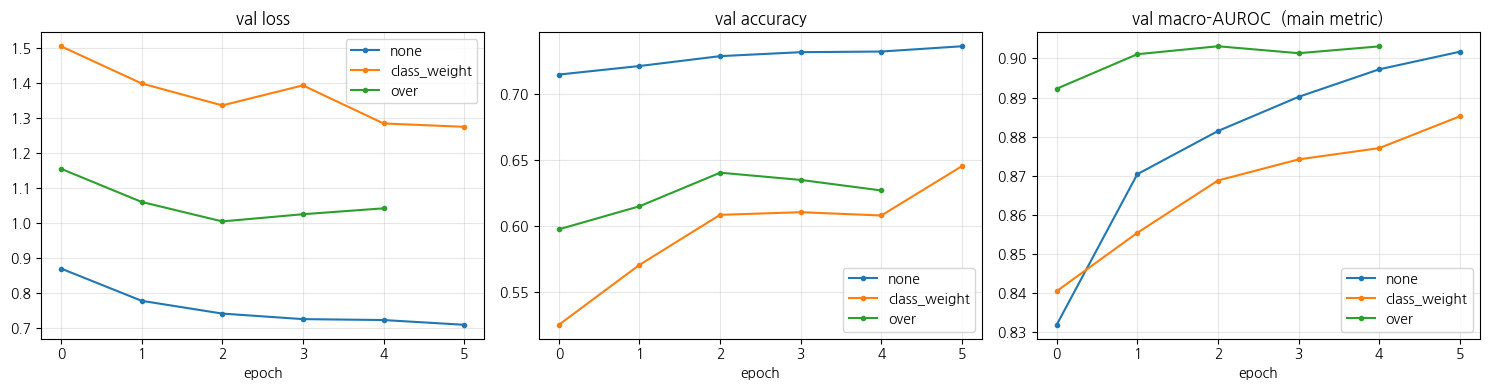


전략별 최고 val macro-AUROC
  none                 best_val_auroc=0.902  best_val_acc=0.736
  class_weight         best_val_auroc=0.885  best_val_acc=0.646
  over                 best_val_auroc=0.903  best_val_acc=0.641


In [30]:
compare_histories = {}
compare_labels = []

train_loader_none, val_loader_none = make_loaders(meta, sampling="none")

model_none = build_model(arch="resnet18", strategy="classifier")
compare_histories["none"] = train_model(
    model_none, train_loader_none, val_loader_none, device,
    epochs=6, lr=3e-3, patience=2
)
compare_labels.append("none")

model_weighted = build_model(arch="resnet18", strategy="classifier")
compare_histories["class_weight"] = train_model_weighted(
    model_weighted, train_loader_none, val_loader_none, device,
    class_weights=class_weights,
    epochs=6, lr=3e-3, patience=2
)
compare_labels.append("class_weight")

train_loader_over, val_loader_over = make_loaders(meta, sampling="over")
model_over = build_model(arch="resnet18", strategy="classifier")
compare_histories["over"] = train_model(
    model_over, train_loader_over, val_loader_over, device,
    epochs=6, lr=3e-3, patience=2
)
compare_labels.append("over")

plot_compare(
    [compare_histories[k] for k in compare_labels],
    compare_labels
)

### 2. 다른 backbone

sampling: none
train 8012장 / val 2003장

================ arch = resnet18 ================
[resnet18 / classifier] trainable 3,591 / total 11,180,103 (0.03%)


epochs:   0%|          | 0/6 [00:00<?, ?it/s]

[01/6] train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[01/6] train loss=0.969 acc=0.679 auroc=0.733 | val loss=0.840 acc=0.708 auroc=0.832 | 107.3s *best


...

[05/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[05/6] train loss=0.554 acc=0.801 auroc=0.946 | val loss=0.686 acc=0.757 auroc=0.935 | 106.7s *best


[06/6] train:   0%|          | 0/126 [00:00<?, ?it/s]

[06/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[06/6] train loss=0.583 acc=0.794 auroc=0.945 | val loss=0.641 acc=0.772 auroc=0.941 | 105.0s *best
최고 val_auroc 시점 가중치로 복원 (best=0.941)


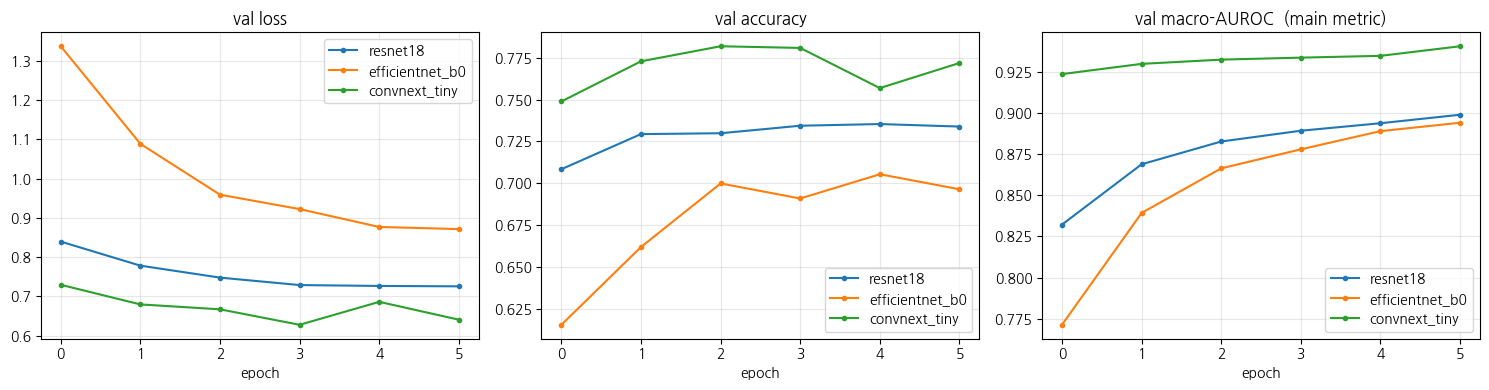


전략별 최고 val macro-AUROC
  resnet18             best_val_auroc=0.899  best_val_acc=0.735
  efficientnet_b0      best_val_auroc=0.894  best_val_acc=0.705
  convnext_tiny        best_val_auroc=0.941  best_val_acc=0.782


,arch,best_val_auroc
2,convnext_tiny,0.940512
0,resnet18,0.898899
1,efficientnet_b0,0.894029


In [31]:
backbone_results = {}
backbones = ["resnet18", "efficientnet_b0", "convnext_tiny"]

train_loader_bb, val_loader_bb = make_loaders(meta, sampling="none")

for arch in backbones:
    print(f"\n================ arch = {arch} ================")
    model_bb = build_model(arch=arch, strategy="classifier")
    history_bb = train_model(
        model_bb,
        train_loader_bb,
        val_loader_bb,
        device,
        epochs=6,
        lr=3e-3,
        patience=2,
    )
    backbone_results[arch] = {
        "model": model_bb,
        "history": history_bb,
        "best_val_auroc": max(history_bb["val_auroc"]),
    }

plot_compare(
    [backbone_results[a]["history"] for a in backbones],
    backbones
)

pd.DataFrame([
    {"arch": a, "best_val_auroc": backbone_results[a]["best_val_auroc"]}
    for a in backbones
]).sort_values("best_val_auroc", ascending=False)

### 3. 해상도 영향


================ IMG_SIZE = 224 ================
IMG_SIZE=224 | train 8012장 / val 2003장
[resnet18 / classifier] trainable 3,591 / total 11,180,103 (0.03%)


epochs:   0%|          | 0/6 [00:00<?, ?it/s]

[01/6] train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[01/6] train loss=1.000 acc=0.674 auroc=0.716 | val loss=0.845 acc=0.706 auroc=0.829 | 103.4s *best


...

[05/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[05/6] train loss=0.731 acc=0.737 auroc=0.893 | val loss=0.711 acc=0.757 auroc=0.903 | 157.2s *best


[06/6] train:   0%|          | 0/126 [00:00<?, ?it/s]

[06/6]   val:   0%|          | 0/32 [00:00<?, ?it/s]

[06/6] train loss=0.717 acc=0.736 auroc=0.903 | val loss=0.708 acc=0.749 auroc=0.907 | 157.8s *best
최고 val_auroc 시점 가중치로 복원 (best=0.907)


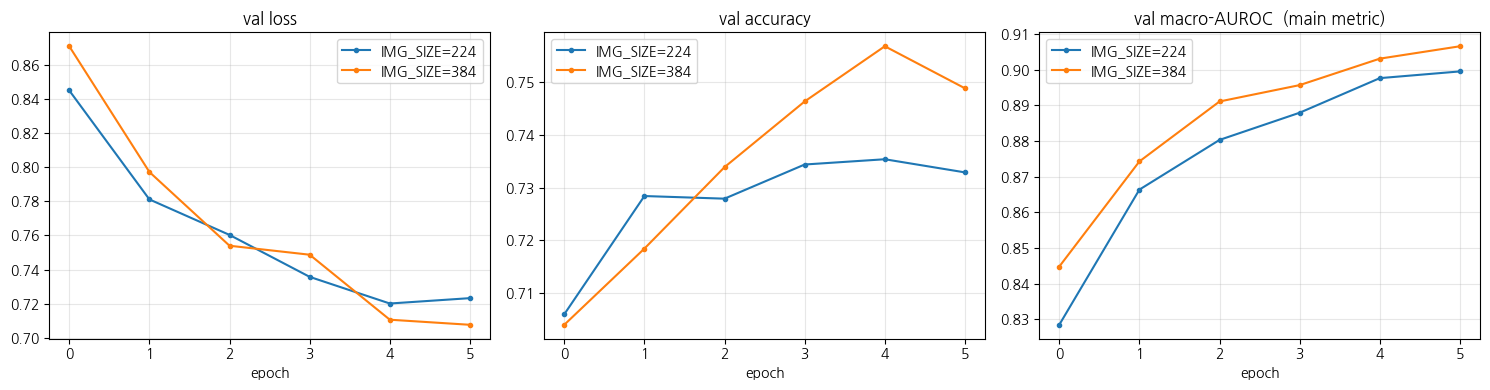


전략별 최고 val macro-AUROC
  IMG_SIZE=224         best_val_auroc=0.899  best_val_acc=0.735
  IMG_SIZE=384         best_val_auroc=0.907  best_val_acc=0.757


,IMG_SIZE,best_val_auroc,time_min
0,224,0.899467,10.598332
1,384,0.906514,15.807887


In [32]:
def make_transforms_for_size(img_size):
    train_tf_local = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(0.1, 0.1, 0.1),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    val_tf_local = transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    return train_tf_local, val_tf_local


def make_loaders_for_size(meta_df, img_size, val_ratio=0.2):
    train_tf_local, val_tf_local = make_transforms_for_size(img_size)

    train_df, val_df = train_test_split(
        meta_df,
        test_size=val_ratio,
        stratify=meta_df["label"],
        random_state=SEED,
    )

    train_set = HAMDataset(
        train_df["path"].values,
        train_df["label"].values,
        train_tf_local,
    )

    val_set = HAMDataset(
        val_df["path"].values,
        val_df["label"].values,
        val_tf_local,
    )

    train_loader_local = DataLoader(
        train_set,
        batch_size=BATCH,
        shuffle=True,
        num_workers=1,
        pin_memory=True,
        persistent_workers=True,
    )

    val_loader_local = DataLoader(
        val_set,
        batch_size=BATCH,
        shuffle=False,
        num_workers=1,
        pin_memory=True,
        persistent_workers=True,
    )

    print(f"IMG_SIZE={img_size} | train {len(train_set)}장 / val {len(val_set)}장")
    return train_loader_local, val_loader_local


size_results = {}
for size in [224, 384]:
    print(f"\n================ IMG_SIZE = {size} ================")
    train_loader_size, val_loader_size = make_loaders_for_size(meta, img_size=size)

    model_size = build_model(arch="resnet18", strategy="classifier")
    start = time.time()
    history_size = train_model(
        model_size,
        train_loader_size,
        val_loader_size,
        device,
        epochs=6,
        lr=3e-3,
        patience=2,
    )
    elapsed = time.time() - start

    size_results[size] = {
        "model": model_size,
        "history": history_size,
        "best_val_auroc": max(history_size["val_auroc"]),
        "time_sec": elapsed,
    }

plot_compare(
    [size_results[s]["history"] for s in [224, 384]],
    [f"IMG_SIZE={s}" for s in [224, 384]]
)

pd.DataFrame([
    {
        "IMG_SIZE": s,
        "best_val_auroc": size_results[s]["best_val_auroc"],
        "time_min": size_results[s]["time_sec"] / 60,
    }
    for s in [224, 384]
])

### 4. TTA

TTA eval:   0%|          | 0/63 [00:00<?, ?it/s]

model_C + original/flip TTA
accuracy: 0.8522
macro-AUROC: 0.9695

클래스별 AUROC
akiec : 0.966
bcc   : 0.984
bkl   : 0.951
df    : 0.991
mel   : 0.931
nv    : 0.965
vasc  : 0.999

              precision    recall  f1-score   support

       akiec      0.683     0.662     0.672        65
         bcc      0.680     0.845     0.753       103
         bkl      0.704     0.723     0.713       220
          df      0.812     0.565     0.667        23
         mel      0.717     0.489     0.581       223
          nv      0.913     0.953     0.933      1341
        vasc      1.000     0.643     0.783        28

    accuracy                          0.852      2003
   macro avg      0.787     0.697     0.729      2003
weighted avg      0.849     0.852     0.846      2003



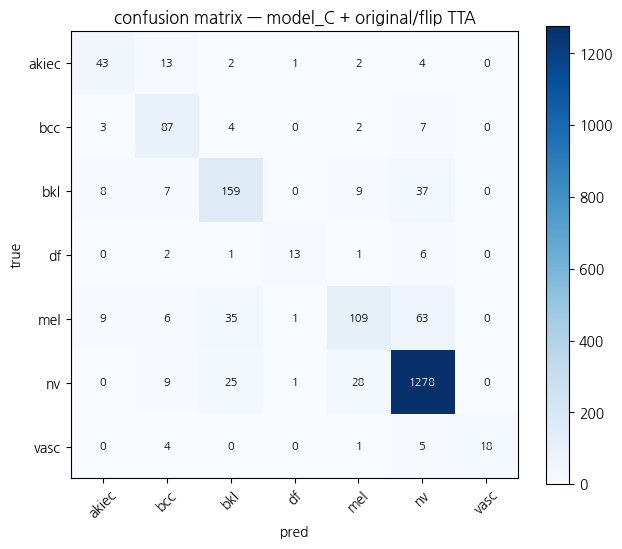

In [34]:
# TTA용 안전한 validation loader 재생성
# DataLoader worker 에러 방지용: num_workers=0, persistent_workers=False

safe_val_loader = DataLoader(
    val_loader.dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)

tta_result = evaluate_tta_flip(
    model_C,
    safe_val_loader,
    CLASSES,
    title="model_C + original/flip TTA"
)

TTA eval:   0%|          | 0/63 [00:00<?, ?it/s]

model_C + original/flip TTA
accuracy: 0.8522
macro-AUROC: 0.9695

클래스별 AUROC
akiec : 0.966
bcc   : 0.984
bkl   : 0.951
df    : 0.991
mel   : 0.931
nv    : 0.965
vasc  : 0.999

              precision    recall  f1-score   support

       akiec      0.683     0.662     0.672        65
         bcc      0.680     0.845     0.753       103
         bkl      0.704     0.723     0.713       220
          df      0.812     0.565     0.667        23
         mel      0.717     0.489     0.581       223
          nv      0.913     0.953     0.933      1341
        vasc      1.000     0.643     0.783        28

    accuracy                          0.852      2003
   macro avg      0.787     0.697     0.729      2003
weighted avg      0.849     0.852     0.846      2003



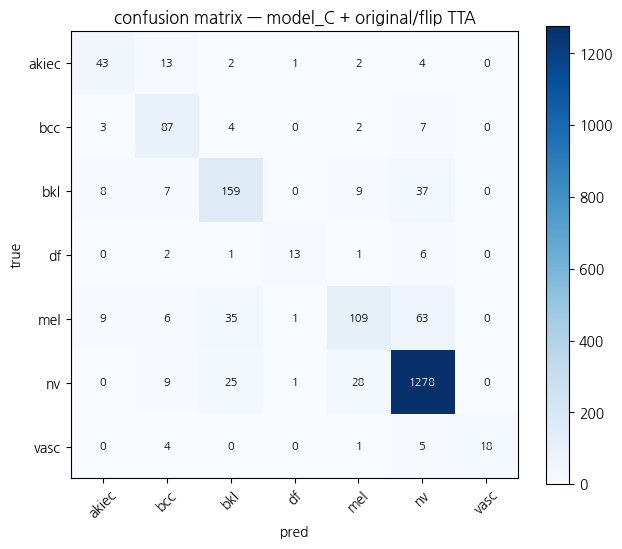

In [37]:
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix

def evaluate_tta_flip(model, loader, class_names, title="TTA flip"):
    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="TTA eval", leave=False):
            x = x.to(device)

            logits_original = model(x)
            probs_original = torch.softmax(logits_original, dim=1)

            x_flip = torch.flip(x, dims=[3])
            logits_flip = model(x_flip)
            probs_flip = torch.softmax(logits_flip, dim=1)

            probs = (probs_original + probs_flip) / 2.0
            preds = probs.argmax(dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(y.numpy())

    probs = np.concatenate(all_probs)
    preds = np.concatenate(all_preds)
    ys = np.concatenate(all_labels)

    per_class_auc = roc_auc_score(ys, probs, multi_class="ovr", average=None)
    macro_auc = roc_auc_score(ys, probs, multi_class="ovr", average="macro")
    acc = accuracy_score(ys, preds)

    print(f"{title}")
    print(f"accuracy: {acc:.4f}")
    print(f"macro-AUROC: {macro_auc:.4f}")
    print("\n클래스별 AUROC")
    for c, v in zip(class_names, per_class_auc):
        print(f"{c:6s}: {v:.3f}")

    print()
    print(classification_report(ys, preds, target_names=class_names, digits=3))

    cm = confusion_matrix(ys, preds)
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticklabels(class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(
                j, i, cm[i, j],
                ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=8,
            )

    ax.set_xlabel("pred")
    ax.set_ylabel("true")
    ax.set_title(f"confusion matrix — {title}")
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    return {
        "acc": acc,
        "macro_auc": macro_auc,
        "per_class_auc": per_class_auc,
        "preds": preds,
        "ys": ys,
        "probs": probs,
    }


tta_result = evaluate_tta_flip(model_C, safe_val_loader, CLASSES, title="model_C + original/flip TTA")

### 5. 서브그룹 성능평가

In [39]:
def get_val_df(meta_df, val_ratio=0.2):
    _, val_df = train_test_split(
        meta_df,
        test_size=val_ratio,
        stratify=meta_df["label"],
        random_state=SEED,
    )
    return val_df.reset_index(drop=True)


def collect_probs(model, loader):
    model.eval()
    probs_list = []
    preds_list = []
    ys_list = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="collect probs", leave=False):
            logits = model(x.to(device))
            probs = torch.softmax(logits, dim=1)

            probs_list.append(probs.cpu().numpy())
            preds_list.append(probs.argmax(dim=1).cpu().numpy())
            ys_list.append(y.numpy())

    return (
        np.concatenate(ys_list),
        np.concatenate(preds_list),
        np.concatenate(probs_list),
    )


def subgroup_macro_auroc(val_df, ys, probs, group_col, min_n=30):
    rows = []

    temp = val_df.copy().reset_index(drop=True)
    temp["_y"] = ys

    for group_value, idx in temp.groupby(group_col).groups.items():
        idx = np.array(list(idx))
        y_g = ys[idx]
        p_g = probs[idx]

        n = len(idx)
        n_classes = len(np.unique(y_g))

        if n < min_n or n_classes < 2:
            rows.append({
                "group_col": group_col,
                "group": group_value,
                "n": n,
                "n_classes": n_classes,
                "macro_auroc": np.nan,
                "note": "too few samples/classes",
            })
            continue

        try:
            auc = roc_auc_score(y_g, p_g, multi_class="ovr", average="macro")
            note = ""
        except ValueError as e:
            auc = np.nan
            note = str(e)

        rows.append({
            "group_col": group_col,
            "group": group_value,
            "n": n,
            "n_classes": n_classes,
            "macro_auroc": auc,
            "note": note,
        })

    return pd.DataFrame(rows).sort_values(["macro_auroc", "n"], ascending=[True, False])


val_df = get_val_df(meta, val_ratio=0.2)
ys, preds, probs = collect_probs(model_C, safe_val_loader)

subgroup_tables = {}
for col in ["sex", "age_bin", "localization"]:
    print(f"\n================ subgroup = {col} ================")
    table = subgroup_macro_auroc(val_df, ys, probs, group_col=col, min_n=30)
    subgroup_tables[col] = table
    display(table)

collect probs:   0%|          | 0/63 [00:00<?, ?it/s]


================ subgroup = sex ================


,group_col,group,n,n_classes,macro_auroc,note
1,sex,male,1086,7,0.962851,
0,sex,female,904,7,0.970985,
2,sex,unknown,13,1,NaN,too few samples/classes



================ subgroup = age_bin ================


/tmp/ipykernel_58/408990914.py:39: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  for group_value, idx in temp.groupby(group_col).groups.items():


,group_col,group,n,n_classes,macro_auroc,note
7,age_bin,80+,127,7,0.944911,
4,age_bin,50s,421,7,0.951869,
5,age_bin,60s,306,7,0.955011,
6,age_bin,70s,301,7,0.957155,
2,age_bin,30s,262,7,0.969452,
3,age_bin,40s,432,7,0.982699,
1,age_bin,20s,92,3,NaN,Number of classes in y_true not equal to the n...
0,age_bin,<20,49,3,NaN,Number of classes in y_true not equal to the n...



================ subgroup = localization ================


,group_col,group,n,n_classes,macro_auroc,note
14,localization,upper extremity,235,7,0.959406,
2,localization,back,427,7,0.959738,
9,localization,lower extremity,446,7,0.971288,
0,localization,abdomen,214,7,0.982740,
12,localization,trunk,268,5,NaN,Number of classes in y_true not equal to the n...
5,localization,face,141,6,NaN,Number of classes in y_true not equal to the n...
3,localization,chest,86,5,NaN,Number of classes in y_true not equal to the n...
6,localization,foot,48,3,NaN,Number of classes in y_true not equal to the n...
13,localization,unknown,47,4,NaN,Number of classes in y_true not equal to the n...
10,localization,neck,32,4,NaN,Number of classes in y_true not equal to the n...


### 6. Focal Loss 적용

sampling: none
train 8012장 / val 2003장
[convnext_tiny / classifier] trainable 5,383 / total 27,825,511 (0.02%)
Focal Loss 학습 시작
arch        : convnext_tiny
gamma       : 2.0
lr          : 0.003
epochs      : 6
patience    : 2
class weights
akiec : 4.3686
bcc   : 2.7848
bkl   : 1.3021
df    : 12.4410
mel   : 1.2860
nv    : 0.2134
vasc  : 10.0401


focal epochs:   0%|          | 0/6 [00:00<?, ?it/s]

[01/6] focal train:   0%|          | 0/126 [00:00<?, ?it/s]

[01/6] focal val:   0%|          | 0/63 [00:00<?, ?it/s]

[01/6] train loss=1.178 acc=0.339 auroc=0.809 | val loss=1.083 acc=0.364 auroc=0.845 | 114.7s *best


...

[04/6] focal val:   0%|          | 0/63 [00:00<?, ?it/s]

[04/6] train loss=0.635 acc=0.526 auroc=0.909 | val loss=0.780 acc=0.432 auroc=0.884 | 110.6s (1/2)


[05/6] focal train:   0%|          | 0/126 [00:00<?, ?it/s]

[05/6] focal val:   0%|          | 0/63 [00:00<?, ?it/s]

[05/6] train loss=0.579 acc=0.517 auroc=0.912 | val loss=0.722 acc=0.572 auroc=0.906 | 110.3s (2/2)
[early stop] val_auroc 개선 없음 2 epoch -> 종료
최고 val_auroc 시점 가중치로 복원 완료: best=0.9098


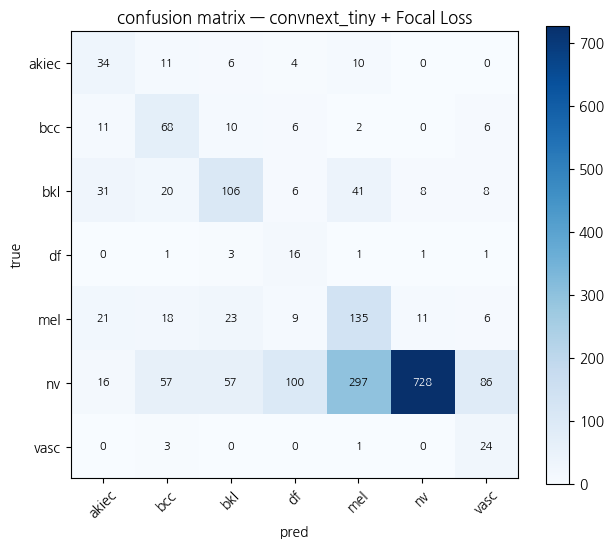

클래스별 AUROC
  akiec   0.940
  bcc     0.940
  bkl     0.860
  df      0.956
  mel     0.793
  nv      0.915
  vasc    0.964
macro-AUROC: 0.9098

              precision    recall  f1-score   support

       akiec      0.301     0.523     0.382        65
         bcc      0.382     0.660     0.484       103
         bkl      0.517     0.482     0.499       220
          df      0.113     0.696     0.195        23
         mel      0.277     0.605     0.380       223
          nv      0.973     0.543     0.697      1341
        vasc      0.183     0.857     0.302        28

    accuracy                          0.555      2003
   macro avg      0.392     0.624     0.420      2003
weighted avg      0.773     0.555     0.607      2003



TTA eval:   0%|          | 0/63 [00:00<?, ?it/s]

convnext_tiny + Focal Loss + original/flip TTA
accuracy: 0.5612
macro-AUROC: 0.9111

클래스별 AUROC
akiec : 0.940
bcc   : 0.940
bkl   : 0.862
df    : 0.959
mel   : 0.793
nv    : 0.915
vasc  : 0.968

              precision    recall  f1-score   support

       akiec      0.308     0.508     0.384        65
         bcc      0.396     0.699     0.505       103
         bkl      0.495     0.495     0.495       220
          df      0.120     0.696     0.205        23
         mel      0.285     0.605     0.388       223
          nv      0.972     0.548     0.701      1341
        vasc      0.182     0.857     0.300        28

    accuracy                          0.561      2003
   macro avg      0.394     0.630     0.425      2003
weighted avg      0.771     0.561     0.612      2003



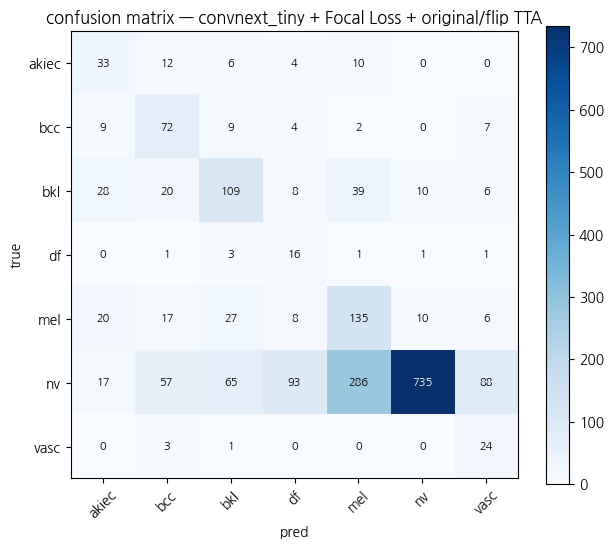

In [43]:
# =========================================================
# Focal Loss 실험 셀
# 최신 노트북 구조 반영 버전
# - train_loader의 학습 데이터만 사용해 class weight 계산
# - 기존 train_model()을 건드리지 않고 train_model_focal() 별도 정의
# - 학습 + 평가 + TTA까지 한 번에 실행
# =========================================================

import time
import copy
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm


FOCAL_ARCH = "convnext_tiny"   # "resnet18", "efficientnet_b0", "convnext_tiny" 중 선택 가능
FOCAL_EPOCHS = 6
FOCAL_LR = 3e-3
FOCAL_PATIENCE = 2
FOCAL_GAMMA = 2.0


class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(
            inputs,
            targets,
            reduction="none",
            weight=self.alpha
        )

        pt = torch.exp(-ce_loss)
        focal_loss = ((1.0 - pt) ** self.gamma) * ce_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        elif self.reduction == "sum":
            return focal_loss.sum()
        else:
            return focal_loss


def train_model_focal(
    model,
    train_loader,
    val_loader,
    device,
    gamma=2.0,
    epochs=6,
    lr=3e-3,
    patience=2,
    optimizer=None,
):
    if hasattr(train_loader.dataset, "labels"):
        train_labels = np.array(train_loader.dataset.labels)
    elif hasattr(train_loader.dataset, "targets"):
        train_labels = np.array(train_loader.dataset.targets)
    elif hasattr(train_loader.dataset, "samples"):
        train_labels = np.array([label for _, label in train_loader.dataset.samples])
    elif hasattr(train_loader.dataset, "imgs"):
        train_labels = np.array([label for _, label in train_loader.dataset.imgs])
    else:
        raise RuntimeError("train_loader.dataset에서 label을 찾을 수 없습니다.")

    class_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.arange(len(CLASSES)),
        y=train_labels,
    )

    weight_tensor = torch.tensor(
        class_weights,
        dtype=torch.float32,
        device=device,
    )

    criterion = FocalLoss(
        alpha=weight_tensor,
        gamma=gamma,
    )

    if optimizer is None:
        optimizer = optim.Adam(
            [p for p in model.parameters() if p.requires_grad],
            lr=lr,
        )

    stopper = EarlyStopping(patience=patience)

    history = {
        "train_loss": [], "train_acc": [], "train_auroc": [],
        "val_loss": [], "val_acc": [], "val_auroc": [],
    }

    print("=" * 70)
    print("Focal Loss 학습 시작")
    print(f"arch        : {FOCAL_ARCH}")
    print(f"gamma       : {gamma}")
    print(f"lr          : {lr}")
    print(f"epochs      : {epochs}")
    print(f"patience    : {patience}")
    print("class weights")
    for c, w in zip(CLASSES, class_weights):
        print(f"{c:6s}: {w:.4f}")
    print("=" * 70)

    epoch_bar = tqdm(range(1, epochs + 1), desc="focal epochs", dynamic_ncols=True)

    for epoch in epoch_bar:
        t0 = time.time()

        tl, ta, t_auc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            train=True,
            desc=f"[{epoch:02d}/{epochs}] focal train",
        )

        vl, va, v_auc = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer,
            device,
            train=False,
            desc=f"[{epoch:02d}/{epochs}] focal val",
        )

        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["train_auroc"].append(t_auc)

        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        history["val_auroc"].append(v_auc)

        stopped = stopper.step(v_auc, model)
        tag = "*best" if stopper.counter == 0 else f"({stopper.counter}/{patience})"

        print(
            f"[{epoch:02d}/{epochs}] "
            f"train loss={tl:.3f} acc={ta:.3f} auroc={t_auc:.3f} | "
            f"val loss={vl:.3f} acc={va:.3f} auroc={v_auc:.3f} | "
            f"{time.time() - t0:.1f}s {tag}"
        )

        epoch_bar.set_postfix(
            val_auroc=f"{v_auc:.3f}",
            best_auroc=f"{stopper.best:.3f}",
        )

        if stopped:
            print(f"[early stop] val_auroc 개선 없음 {patience} epoch -> 종료")
            break

    stopper.restore(model)
    print(f"최고 val_auroc 시점 가중치로 복원 완료: best={stopper.best:.4f}")

    return history


train_loader_focal, val_loader_focal = make_loaders(meta, sampling="none")

safe_val_loader_focal = DataLoader(
    val_loader_focal.dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

model_focal = build_model(
    arch=FOCAL_ARCH,
    strategy="classifier",
)

history_focal = train_model_focal(
    model_focal,
    train_loader_focal,
    safe_val_loader_focal,
    device,
    gamma=FOCAL_GAMMA,
    epochs=FOCAL_EPOCHS,
    lr=FOCAL_LR,
    patience=FOCAL_PATIENCE,
)

focal_eval = evaluate(
    model_focal,
    safe_val_loader_focal,
    CLASSES,
    title=f"{FOCAL_ARCH} + Focal Loss",
)

focal_tta_result = evaluate_tta_flip(
    model_focal,
    safe_val_loader_focal,
    CLASSES,
    title=f"{FOCAL_ARCH} + Focal Loss + original/flip TTA",
)

### 7. WeightedRandomSampler + CrossEntropy

WeightedRandomSampler loader 생성 완료
arch       : convnext_tiny
IMG_SIZE   : 384
batch size : 32
train      : 8012
val        : 2003

원본 train class count
akiec  | count=  262 | sampling_weight=0.003817
bcc    | count=  411 | sampling_weight=0.002433
bkl    | count=  879 | sampling_weight=0.001138
df     | count=   92 | sampling_weight=0.010870
mel    | count=  890 | sampling_weight=0.001124
nv     | count= 5364 | sampling_weight=0.000186
vasc   | count=  114 | sampling_weight=0.008772
[convnext_tiny / classifier] trainable 5,383 / total 27,825,511 (0.02%)


epochs:   0%|          | 0/6 [00:00<?, ?it/s]

[01/6] train:   0%|          | 0/251 [00:00<?, ?it/s]

[01/6]   val:   0%|          | 0/63 [00:00<?, ?it/s]

[01/6] train loss=1.000 acc=0.638 auroc=0.908 | val loss=0.803 acc=0.717 auroc=0.927 | 279.4s *best


...

[05/6]   val:   0%|          | 0/63 [00:00<?, ?it/s]

[05/6] train loss=0.551 acc=0.801 auroc=0.967 | val loss=0.613 acc=0.784 auroc=0.951 | 268.5s *best


[06/6] train:   0%|          | 0/251 [00:00<?, ?it/s]

[06/6]   val:   0%|          | 0/63 [00:00<?, ?it/s]

[06/6] train loss=0.528 acc=0.813 auroc=0.969 | val loss=0.799 acc=0.723 auroc=0.942 | 273.1s (1/2)
최고 val_auroc 시점 가중치로 복원 (best=0.951)


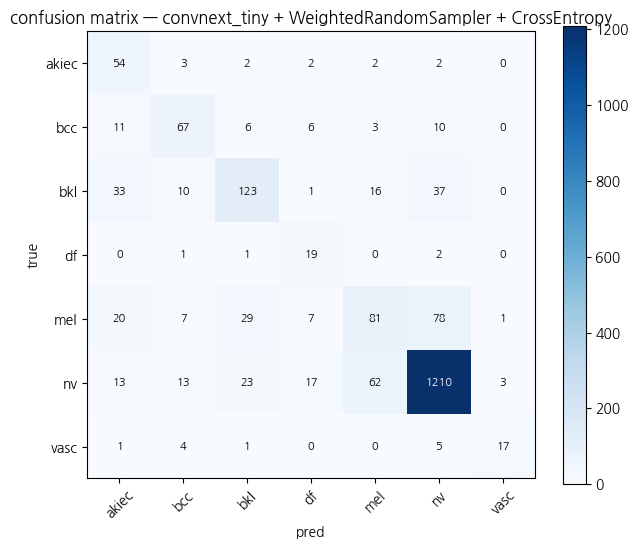

클래스별 AUROC
  akiec   0.977
  bcc     0.968
  bkl     0.927
  df      0.985
  mel     0.871
  nv      0.936
  vasc    0.990
macro-AUROC: 0.9505

              precision    recall  f1-score   support

       akiec      0.409     0.831     0.548        65
         bcc      0.638     0.650     0.644       103
         bkl      0.665     0.559     0.607       220
          df      0.365     0.826     0.507        23
         mel      0.494     0.363     0.419       223
          nv      0.900     0.902     0.901      1341
        vasc      0.810     0.607     0.694        28

    accuracy                          0.784      2003
   macro avg      0.612     0.677     0.617      2003
weighted avg      0.792     0.784     0.783      2003



TTA eval:   0%|          | 0/63 [00:00<?, ?it/s]

convnext_tiny + WeightedRandomSampler + CrossEntropy + flip TTA
accuracy: 0.7823
macro-AUROC: 0.9505

클래스별 AUROC
akiec : 0.976
bcc   : 0.967
bkl   : 0.929
df    : 0.985
mel   : 0.871
nv    : 0.936
vasc  : 0.989

              precision    recall  f1-score   support

       akiec      0.388     0.769     0.515        65
         bcc      0.635     0.641     0.638       103
         bkl      0.653     0.573     0.610       220
          df      0.357     0.870     0.506        23
         mel      0.516     0.354     0.420       223
          nv      0.897     0.902     0.899      1341
        vasc      0.850     0.607     0.708        28

    accuracy                          0.782      2003
   macro avg      0.614     0.674     0.614      2003
weighted avg      0.791     0.782     0.781      2003



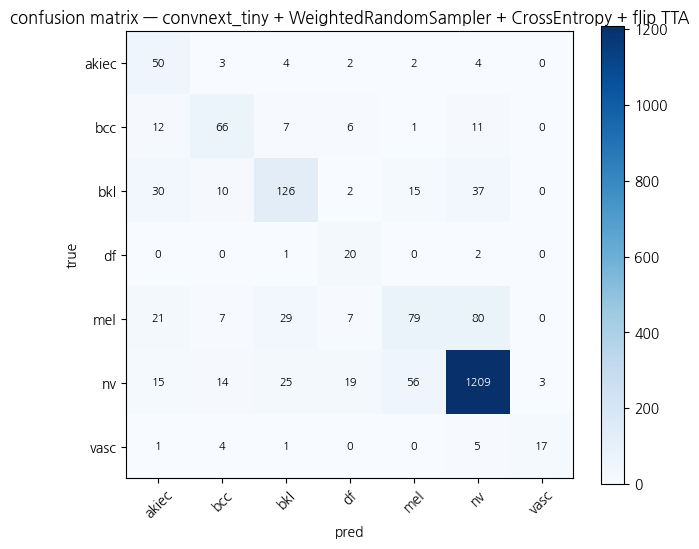

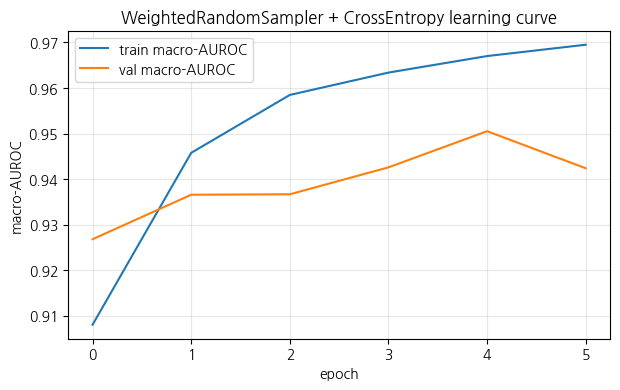

WeightedRandomSampler + CrossEntropy 실험 완료
best val macro-AUROC: 0.9505
last val macro-AUROC: 0.9424


In [44]:
# =========================================================
# Experiment 2. WeightedRandomSampler + CrossEntropy
# 목적: recall이 낮은 소수 클래스(mel, df, vasc 등)의 학습 노출 빈도 증가
# 기준: Macro-AUROC / class-wise AUROC / recall 변화 확인
# =========================================================

import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 설정
# ---------------------------------------------------------

WS_ARCH = "convnext_tiny"
WS_IMG_SIZE = 384
WS_BATCH = 32
WS_EPOCHS = 6
WS_LR = 3e-3
WS_PATIENCE = 2


# ---------------------------------------------------------
# transform 정의
# ---------------------------------------------------------

ws_train_tf = transforms.Compose([
    transforms.Resize((WS_IMG_SIZE, WS_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

ws_val_tf = transforms.Compose([
    transforms.Resize((WS_IMG_SIZE, WS_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# ---------------------------------------------------------
# WeightedRandomSampler loader 생성
# ---------------------------------------------------------

def make_weighted_sampler_loaders(meta_df, val_ratio=0.2):
    train_df, val_df = train_test_split(
        meta_df,
        test_size=val_ratio,
        stratify=meta_df["label"],
        random_state=SEED,
    )

    train_set = HAMDataset(
        train_df["path"].values,
        train_df["label"].values,
        ws_train_tf,
    )

    val_set = HAMDataset(
        val_df["path"].values,
        val_df["label"].values,
        ws_val_tf,
    )

    train_labels = train_df["label"].values

    class_counts = np.bincount(train_labels, minlength=len(CLASSES))
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[train_labels]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader_ws = DataLoader(
        train_set,
        batch_size=WS_BATCH,
        sampler=sampler,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    val_loader_ws = DataLoader(
        val_set,
        batch_size=WS_BATCH,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    print("=" * 70)
    print("WeightedRandomSampler loader 생성 완료")
    print(f"arch       : {WS_ARCH}")
    print(f"IMG_SIZE   : {WS_IMG_SIZE}")
    print(f"batch size : {WS_BATCH}")
    print(f"train      : {len(train_set)}")
    print(f"val        : {len(val_set)}")
    print("\n원본 train class count")
    for cls_name, cnt, w in zip(CLASSES, class_counts, class_weights):
        print(f"{cls_name:6s} | count={cnt:5d} | sampling_weight={w:.6f}")
    print("=" * 70)

    return train_loader_ws, val_loader_ws, train_df, val_df


train_loader_ws, val_loader_ws, train_df_ws, val_df_ws = make_weighted_sampler_loaders(meta)


# ---------------------------------------------------------
# 모델 학습
# ---------------------------------------------------------

model_ws = build_model(
    arch=WS_ARCH,
    strategy="classifier",
)

history_ws = train_model(
    model_ws,
    train_loader_ws,
    val_loader_ws,
    device,
    epochs=WS_EPOCHS,
    lr=WS_LR,
    patience=WS_PATIENCE,
)


# ---------------------------------------------------------
# 일반 평가
# ---------------------------------------------------------

ws_eval_result = evaluate(
    model_ws,
    val_loader_ws,
    CLASSES,
    title=f"{WS_ARCH} + WeightedRandomSampler + CrossEntropy"
)


# ---------------------------------------------------------
# TTA 평가: original + horizontal flip 평균
# ---------------------------------------------------------

if "evaluate_tta_flip" in globals():
    ws_tta_result = evaluate_tta_flip(
        model_ws,
        val_loader_ws,
        CLASSES,
        title=f"{WS_ARCH} + WeightedRandomSampler + CrossEntropy + flip TTA"
    )
else:
    print("evaluate_tta_flip 함수가 아직 정의되지 않았습니다. TTA 함수 셀을 먼저 실행한 뒤 아래 코드만 다시 실행하세요.")
    ws_tta_result = None


# ---------------------------------------------------------
# 학습 곡선 출력
# ---------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(history_ws["train_auroc"], label="train macro-AUROC")
plt.plot(history_ws["val_auroc"], label="val macro-AUROC")
plt.xlabel("epoch")
plt.ylabel("macro-AUROC")
plt.title("WeightedRandomSampler + CrossEntropy learning curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


# ---------------------------------------------------------
# 결과 요약
# ---------------------------------------------------------

print("=" * 70)
print("WeightedRandomSampler + CrossEntropy 실험 완료")
print(f"best val macro-AUROC: {max(history_ws['val_auroc']):.4f}")
print(f"last val macro-AUROC: {history_ws['val_auroc'][-1]:.4f}")
print("=" * 70)

### 8. mel vs Rest OVR Expert + Soft Probability Blending

OVR loader 생성 완료: mel vs rest
train positive(mel): 890
train negative(rest): 7122
val positive(mel): 223
val negative(rest): 1780


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

[OVR convnext_tiny / classifier] trainable 1,538 / total 27,821,666 (0.01%)
OVR Expert 학습 시작: mel vs rest
arch     : convnext_tiny
img size : 384
epochs   : 6
lr       : 0.003


OVR epochs:   0%|          | 0/6 [00:00<?, ?it/s]

[01/6] OVR train:   0%|          | 0/251 [00:00<?, ?it/s]

...

[04/6] OVR val:   0%|          | 0/63 [00:00<?, ?it/s]

[04/6] train loss=0.412 acc=0.811 auroc=0.894 | val loss=0.289 acc=0.866 auroc=0.881 | 285.4s (2/2)
[early stop] val_auroc 개선 없음 2 epoch -> 종료
OVR Expert 최고 val AUROC 가중치 복원 완료: best=0.8833


collect 7-class probs:   0%|          | 0/63 [00:00<?, ?it/s]

collect OVR probs:   0%|          | 0/63 [00:00<?, ?it/s]

Base 7-class model_C on OVR validation split
accuracy    : 0.7878
macro-AUROC : 0.9516

클래스별 AUROC
akiec : 0.9571
bcc   : 0.9659
bkl   : 0.9247
df    : 0.9843
mel   : 0.9077
nv    : 0.9380
vasc  : 0.9832

classification report
              precision    recall  f1-score   support

       akiec      0.398     0.662     0.497        65
         bcc      0.539     0.602     0.569       103
         bkl      0.659     0.555     0.602       220
          df      0.769     0.435     0.556        23
         mel      0.810     0.211     0.335       223
          nv      0.848     0.960     0.901      1341
        vasc      1.000     0.250     0.400        28

    accuracy                          0.788      2003
   macro avg      0.718     0.525     0.551      2003
weighted avg      0.794     0.788     0.764      2003



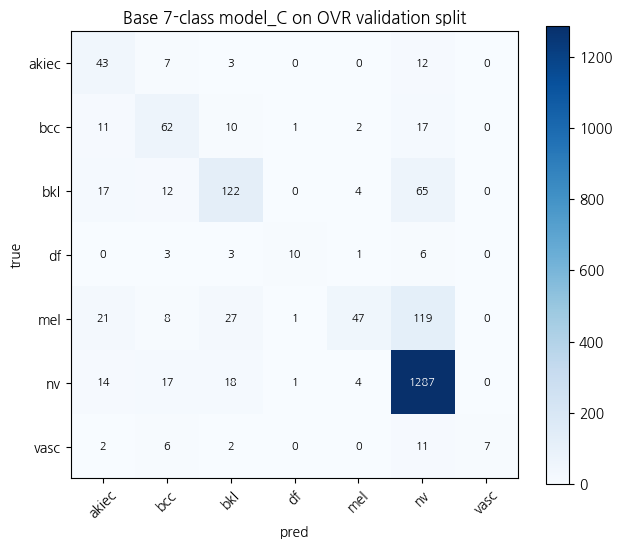

Base model_C + mel vs rest OVR Expert Soft Blend alpha=0.35
accuracy    : 0.7988
macro-AUROC : 0.9522

클래스별 AUROC
akiec : 0.9569
bcc   : 0.9663
bkl   : 0.9246
df    : 0.9857
mel   : 0.9101
nv    : 0.9395
vasc  : 0.9824

classification report
              precision    recall  f1-score   support

       akiec      0.439     0.662     0.528        65
         bcc      0.544     0.602     0.571       103
         bkl      0.693     0.555     0.616       220
          df      0.750     0.391     0.514        23
         mel      0.791     0.323     0.459       223
          nv      0.854     0.958     0.903      1341
        vasc      1.000     0.250     0.400        28

    accuracy                          0.799      2003
   macro avg      0.724     0.534     0.570      2003
weighted avg      0.801     0.799     0.781      2003



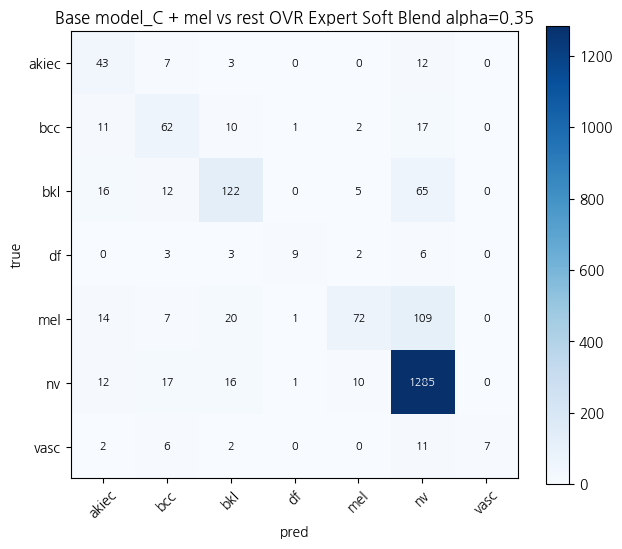


alpha sweep 결과


,alpha,accuracy,macro_auroc,mel_auroc,mel_recall,mel_precision
2,0.10,0.789316,0.953154,0.915030,0.233184,0.787879
3,0.15,0.790814,0.953064,0.914128,0.246637,0.797101
1,0.05,0.787818,0.953043,0.915025,0.215247,0.800000
4,0.20,0.792811,0.952890,0.913234,0.269058,0.789474
5,0.25,0.793310,0.952633,0.912024,0.273543,0.792208
6,0.30,0.795307,0.952418,0.910924,0.291480,0.783133
7,0.35,0.798802,0.952209,0.910082,0.322870,0.791209
8,0.40,0.797803,0.951985,0.909135,0.327354,0.730000
9,0.45,0.800799,0.951730,0.908185,0.358744,0.707965
0,0.00,0.787818,0.951561,0.907661,0.210762,0.810345


Best alpha by macro-AUROC: 0.1


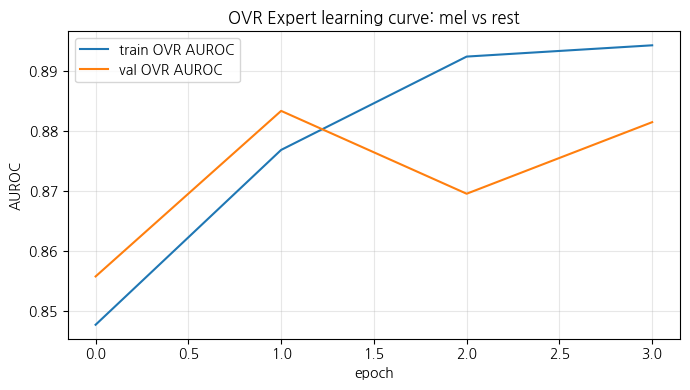

In [30]:
# =========================================================
# Experiment. mel vs Rest OVR Expert + Soft Probability Blending
# 목적:
# - recall이 낮은 melanoma(mel)를 직접 보완
# - Macro-AUROC 문제에 맞게 hard label 변경이 아니라 probability 보정 적용
# 필요 조건:
# - 기존 최종 7-class 모델: model_C
# - meta, CLASSES, CLS2IDX, HAMDataset, EarlyStopping, device, SEED 존재
# =========================================================

import time
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import timm
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 설정
# ---------------------------------------------------------

OVR_TARGET_CLASS = "mel"
OVR_ARCH = "convnext_tiny"
OVR_IMG_SIZE = 384
OVR_BATCH = 32
OVR_EPOCHS = 6
OVR_LR = 3e-3
OVR_PATIENCE = 2

# 기존 7-class 확률과 OVR expert 확률을 섞는 비율
# 0.3~0.5 정도 실험 권장
OVR_BLEND_ALPHA = 0.35

target_idx = CLS2IDX[OVR_TARGET_CLASS]


# ---------------------------------------------------------
# Transform
# ---------------------------------------------------------

ovr_train_tf = transforms.Compose([
    transforms.Resize((OVR_IMG_SIZE, OVR_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

ovr_val_tf = transforms.Compose([
    transforms.Resize((OVR_IMG_SIZE, OVR_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# ---------------------------------------------------------
# Binary model builder
# ---------------------------------------------------------

def build_binary_model(arch="convnext_tiny", strategy="classifier"):
    model = timm.create_model(arch, pretrained=True, num_classes=2)

    if strategy == "classifier":
        cls_ids = {id(p) for p in model.get_classifier().parameters()}
        for p in model.parameters():
            p.requires_grad = id(p) in cls_ids
    else:
        for p in model.parameters():
            p.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total = sum(p.numel() for p in model.parameters())
    print(f"[OVR {arch} / {strategy}] trainable {trainable:,} / total {total:,} ({trainable/total*100:.2f}%)")

    return model.to(device)


# ---------------------------------------------------------
# OVR loader 생성
# ---------------------------------------------------------

def make_ovr_loaders(meta_df, target_class="mel", val_ratio=0.2):
    train_df, val_df = train_test_split(
        meta_df,
        test_size=val_ratio,
        stratify=meta_df["label"],
        random_state=SEED,
    )

    target_label = CLS2IDX[target_class]

    train_y_bin = (train_df["label"].values == target_label).astype(int)
    val_y_bin = (val_df["label"].values == target_label).astype(int)

    train_set = HAMDataset(
        train_df["path"].values,
        train_y_bin,
        ovr_train_tf,
    )

    val_set_bin = HAMDataset(
        val_df["path"].values,
        val_y_bin,
        ovr_val_tf,
    )

    val_set_7cls = HAMDataset(
        val_df["path"].values,
        val_df["label"].values,
        ovr_val_tf,
    )

    class_counts = np.bincount(train_y_bin, minlength=2)
    class_weights = 1.0 / class_counts
    sample_weights = class_weights[train_y_bin]

    sampler = WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )

    train_loader_ovr = DataLoader(
        train_set,
        batch_size=OVR_BATCH,
        sampler=sampler,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    val_loader_ovr_bin = DataLoader(
        val_set_bin,
        batch_size=OVR_BATCH,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    val_loader_ovr_7cls = DataLoader(
        val_set_7cls,
        batch_size=OVR_BATCH,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    print("=" * 70)
    print(f"OVR loader 생성 완료: {target_class} vs rest")
    print(f"train positive({target_class}): {train_y_bin.sum()}")
    print(f"train negative(rest): {(train_y_bin == 0).sum()}")
    print(f"val positive({target_class}): {val_y_bin.sum()}")
    print(f"val negative(rest): {(val_y_bin == 0).sum()}")
    print("=" * 70)

    return train_loader_ovr, val_loader_ovr_bin, val_loader_ovr_7cls, train_df, val_df


train_loader_ovr, val_loader_ovr_bin, val_loader_ovr_7cls, train_df_ovr, val_df_ovr = make_ovr_loaders(
    meta,
    target_class=OVR_TARGET_CLASS,
)


# ---------------------------------------------------------
# Binary train / eval epoch
# ---------------------------------------------------------

def run_binary_epoch(model, loader, criterion, optimizer, device, train=True, desc=""):
    model.train() if train else model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    all_probs = []
    all_labels = []

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        pbar = tqdm(loader, desc=desc, leave=False, dynamic_ncols=True)

        for x, y in pbar:
            x = x.to(device)
            y = y.to(device)

            logits = model(x)
            loss = criterion(logits, y)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            prob_pos = torch.softmax(logits, dim=1)[:, 1]
            pred = logits.argmax(dim=1)

            total_loss += loss.item() * x.size(0)
            correct += (pred == y).sum().item()
            total += x.size(0)

            all_probs.append(prob_pos.detach().cpu().numpy())
            all_labels.append(y.detach().cpu().numpy())

            pbar.set_postfix(
                loss=f"{total_loss / total:.3f}",
                acc=f"{correct / total:.3f}"
            )

    all_probs = np.concatenate(all_probs)
    all_labels = np.concatenate(all_labels)

    try:
        auc = roc_auc_score(all_labels, all_probs)
    except ValueError:
        auc = float("nan")

    return total_loss / total, correct / total, auc


def train_ovr_expert(model, train_loader, val_loader, device, epochs=6, lr=3e-3, patience=2):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
    )

    stopper = EarlyStopping(patience=patience)

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_auroc": [],
        "val_loss": [],
        "val_acc": [],
        "val_auroc": [],
    }

    print("=" * 70)
    print(f"OVR Expert 학습 시작: {OVR_TARGET_CLASS} vs rest")
    print(f"arch     : {OVR_ARCH}")
    print(f"img size : {OVR_IMG_SIZE}")
    print(f"epochs   : {epochs}")
    print(f"lr       : {lr}")
    print("=" * 70)

    for epoch in tqdm(range(1, epochs + 1), desc="OVR epochs", dynamic_ncols=True):
        t0 = time.time()

        tl, ta, t_auc = run_binary_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            train=True,
            desc=f"[{epoch:02d}/{epochs}] OVR train",
        )

        vl, va, v_auc = run_binary_epoch(
            model,
            val_loader,
            criterion,
            optimizer,
            device,
            train=False,
            desc=f"[{epoch:02d}/{epochs}] OVR val",
        )

        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["train_auroc"].append(t_auc)
        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        history["val_auroc"].append(v_auc)

        stopped = stopper.step(v_auc, model)
        tag = "*best" if stopper.counter == 0 else f"({stopper.counter}/{patience})"

        print(
            f"[{epoch:02d}/{epochs}] "
            f"train loss={tl:.3f} acc={ta:.3f} auroc={t_auc:.3f} | "
            f"val loss={vl:.3f} acc={va:.3f} auroc={v_auc:.3f} | "
            f"{time.time() - t0:.1f}s {tag}"
        )

        if stopped:
            print(f"[early stop] val_auroc 개선 없음 {patience} epoch -> 종료")
            break

    stopper.restore(model)
    print(f"OVR Expert 최고 val AUROC 가중치 복원 완료: best={stopper.best:.4f}")

    return history


# ---------------------------------------------------------
# OVR Expert 학습
# ---------------------------------------------------------

model_ovr_mel = build_binary_model(
    arch=OVR_ARCH,
    strategy="classifier",
)

history_ovr_mel = train_ovr_expert(
    model_ovr_mel,
    train_loader_ovr,
    val_loader_ovr_bin,
    device,
    epochs=OVR_EPOCHS,
    lr=OVR_LR,
    patience=OVR_PATIENCE,
)


# ---------------------------------------------------------
# 기존 7-class model_C 확률 수집
# ---------------------------------------------------------

def collect_7class_probs(model, loader):
    model.eval()

    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="collect 7-class probs", leave=False):
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.append(probs.argmax(dim=1).cpu().numpy())
            all_labels.append(y.numpy())

    probs = np.concatenate(all_probs)
    preds = np.concatenate(all_preds)
    labels = np.concatenate(all_labels)

    return labels, preds, probs


def collect_ovr_positive_probs(model, loader):
    model.eval()

    all_probs = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="collect OVR probs", leave=False):
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)[:, 1]
            all_probs.append(probs.cpu().numpy())

    return np.concatenate(all_probs)


ys_base, preds_base, probs_base = collect_7class_probs(
    model_C,
    val_loader_ovr_7cls,
)

mel_prob_ovr = collect_ovr_positive_probs(
    model_ovr_mel,
    val_loader_ovr_bin,
)


# ---------------------------------------------------------
# Soft Blending
# - 기존 7-class 확률 중 mel 확률만 OVR expert로 보정
# - 이후 전체 7-class 확률 합이 1이 되도록 재정규화
# ---------------------------------------------------------

probs_blend = probs_base.copy()

probs_blend[:, target_idx] = (
    (1.0 - OVR_BLEND_ALPHA) * probs_base[:, target_idx]
    + OVR_BLEND_ALPHA * mel_prob_ovr
)

probs_blend = probs_blend / probs_blend.sum(axis=1, keepdims=True)
preds_blend = probs_blend.argmax(axis=1)


# ---------------------------------------------------------
# 평가 함수
# ---------------------------------------------------------

def evaluate_probability_result(ys, probs, class_names, title=""):
    preds = probs.argmax(axis=1)

    acc = accuracy_score(ys, preds)
    per_class_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average=None,
    )
    macro_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average="macro",
    )

    print("=" * 70)
    print(title)
    print(f"accuracy    : {acc:.4f}")
    print(f"macro-AUROC : {macro_auc:.4f}")
    print("\n클래스별 AUROC")
    for c, v in zip(class_names, per_class_auc):
        print(f"{c:6s}: {v:.4f}")

    print("\nclassification report")
    print(classification_report(ys, preds, target_names=class_names, digits=3))

    cm = confusion_matrix(ys, preds)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm, cmap="Blues")

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticklabels(class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black",
                fontsize=8,
            )

    ax.set_xlabel("pred")
    ax.set_ylabel("true")
    ax.set_title(title)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "macro_auroc": macro_auc,
        "per_class_auroc": dict(zip(class_names, per_class_auc)),
        "classification_report": classification_report(
            ys,
            preds,
            target_names=class_names,
            digits=3,
            output_dict=True,
        ),
        "confusion_matrix": cm,
    }


# ---------------------------------------------------------
# Base vs OVR-Blended 비교
# ---------------------------------------------------------

base_eval_for_ovr = evaluate_probability_result(
    ys_base,
    probs_base,
    CLASSES,
    title="Base 7-class model_C on OVR validation split",
)

ovr_blend_eval = evaluate_probability_result(
    ys_base,
    probs_blend,
    CLASSES,
    title=f"Base model_C + {OVR_TARGET_CLASS} vs rest OVR Expert Soft Blend alpha={OVR_BLEND_ALPHA}",
)


# ---------------------------------------------------------
# alpha sweep: Macro-AUROC 기준으로 blending 비율 탐색
# ---------------------------------------------------------

rows = []

for alpha in np.arange(0.0, 0.71, 0.05):
    p = probs_base.copy()

    p[:, target_idx] = (
        (1.0 - alpha) * probs_base[:, target_idx]
        + alpha * mel_prob_ovr
    )

    p = p / p.sum(axis=1, keepdims=True)

    preds = p.argmax(axis=1)
    acc = accuracy_score(ys_base, preds)
    macro_auc = roc_auc_score(ys_base, p, multi_class="ovr", average="macro")
    per_auc = roc_auc_score(ys_base, p, multi_class="ovr", average=None)

    report = classification_report(
        ys_base,
        preds,
        target_names=CLASSES,
        output_dict=True,
        zero_division=0,
    )

    rows.append({
        "alpha": round(float(alpha), 2),
        "accuracy": acc,
        "macro_auroc": macro_auc,
        f"{OVR_TARGET_CLASS}_auroc": per_auc[target_idx],
        f"{OVR_TARGET_CLASS}_recall": report[OVR_TARGET_CLASS]["recall"],
        f"{OVR_TARGET_CLASS}_precision": report[OVR_TARGET_CLASS]["precision"],
    })

alpha_result_df = pd.DataFrame(rows).sort_values(
    ["macro_auroc", f"{OVR_TARGET_CLASS}_recall"],
    ascending=[False, False],
)

print("\nalpha sweep 결과")
display(alpha_result_df)

best_alpha = alpha_result_df.iloc[0]["alpha"]
print("=" * 70)
print(f"Best alpha by macro-AUROC: {best_alpha}")
print("=" * 70)


# ---------------------------------------------------------
# 학습 곡선
# ---------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(history_ovr_mel["train_auroc"], label="train OVR AUROC")
plt.plot(history_ovr_mel["val_auroc"], label="val OVR AUROC")
plt.xlabel("epoch")
plt.ylabel("AUROC")
plt.title(f"OVR Expert learning curve: {OVR_TARGET_CLASS} vs rest")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 9. Class-Balanced Loss(Effective Number of Samples) + ConvNeXt-Tiny + 384

Class-Balanced Loss 설정 완료
beta      : 0.9999
arch      : convnext_tiny
img size  : 384
batch     : 32
epochs    : 6

class count / CB weight
akiec  | count=  262 | cb_weight=0.9433
bcc    | count=  411 | cb_weight=0.6058
bkl    | count=  879 | cb_weight=0.2899
df     | count=   92 | cb_weight=2.6637
mel    | count=  890 | cb_weight=0.2865
nv     | count= 5364 | cb_weight=0.0588
vasc   | count=  114 | cb_weight=2.1520
[convnext_tiny / classifier] trainable 5,383 / total 27,825,511 (0.02%)
Class-Balanced Loss 학습 시작


CB epochs:   0%|          | 0/6 [00:00<?, ?it/s]

[01/6] CB train:   0%|          | 0/251 [00:00<?, ?it/s]

[01/6] CB val:   0%|          | 0/63 [00:00<?, ?it/s]

[01/6] train loss=1.373 acc=0.579 auroc=0.853 | val loss=1.429 acc=0.616 auroc=0.913 | 269.3s *best


...

[05/6] CB val:   0%|          | 0/63 [00:00<?, ?it/s]

[05/6] train loss=0.854 acc=0.700 auroc=0.937 | val loss=0.896 acc=0.736 auroc=0.941 | 265.6s *best


[06/6] CB train:   0%|          | 0/251 [00:00<?, ?it/s]

[06/6] CB val:   0%|          | 0/63 [00:00<?, ?it/s]

[06/6] train loss=0.733 acc=0.735 auroc=0.948 | val loss=0.901 acc=0.756 auroc=0.946 | 266.1s *best
최고 val_auroc 시점 가중치 복원 완료: best=0.9457


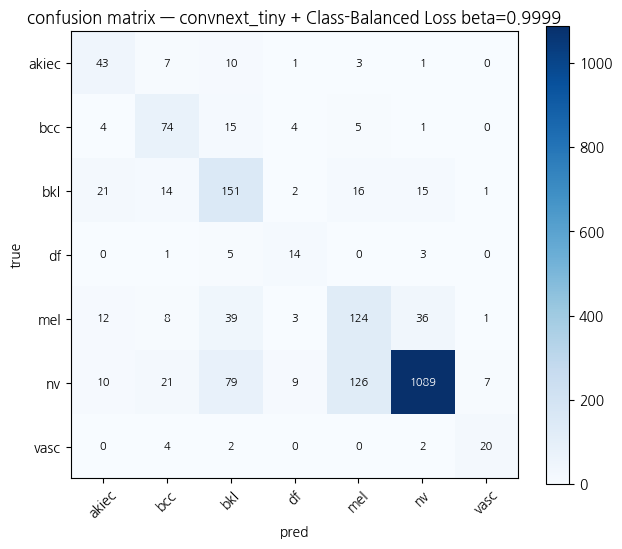

클래스별 AUROC
  akiec   0.971
  bcc     0.969
  bkl     0.907
  df      0.974
  mel     0.878
  nv      0.938
  vasc    0.982
macro-AUROC: 0.9457

              precision    recall  f1-score   support

       akiec      0.478     0.662     0.555        65
         bcc      0.574     0.718     0.638       103
         bkl      0.502     0.686     0.580       220
          df      0.424     0.609     0.500        23
         mel      0.453     0.556     0.499       223
          nv      0.949     0.812     0.875      1341
        vasc      0.690     0.714     0.702        28

    accuracy                          0.756      2003
   macro avg      0.581     0.680     0.621      2003
weighted avg      0.801     0.756     0.772      2003



TTA eval:   0%|          | 0/63 [00:00<?, ?it/s]

convnext_tiny + Class-Balanced Loss + flip TTA
accuracy: 0.7629
macro-AUROC: 0.9457

클래스별 AUROC
akiec : 0.969
bcc   : 0.969
bkl   : 0.910
df    : 0.974
mel   : 0.878
nv    : 0.938
vasc  : 0.982

              precision    recall  f1-score   support

       akiec      0.467     0.646     0.542        65
         bcc      0.571     0.738     0.644       103
         bkl      0.519     0.677     0.588       220
          df      0.412     0.609     0.491        23
         mel      0.458     0.565     0.506       223
          nv      0.952     0.822     0.882      1341
        vasc      0.731     0.679     0.704        28

    accuracy                          0.763      2003
   macro avg      0.587     0.676     0.622      2003
weighted avg      0.805     0.763     0.778      2003



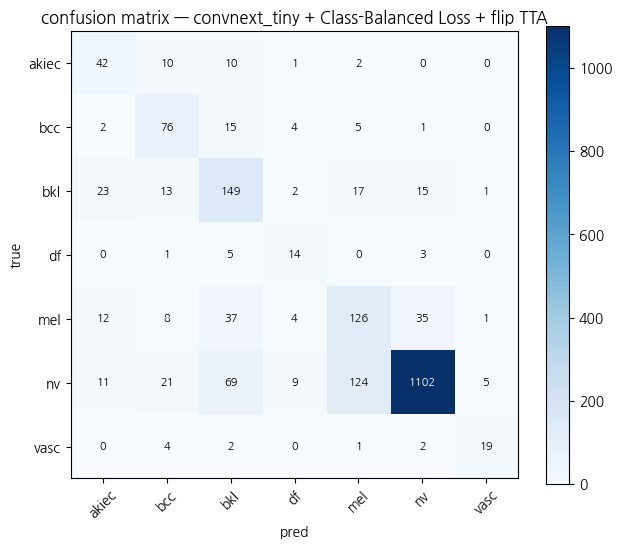

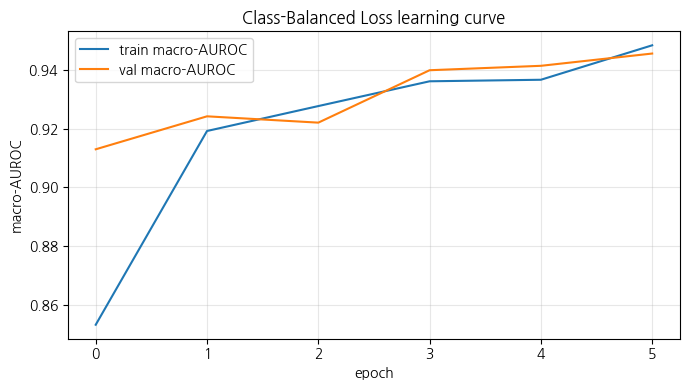

Class-Balanced Loss 실험 완료
best val macro-AUROC: 0.9457
last val macro-AUROC: 0.9457


In [46]:
# =========================================================
# Experiment. Class-Balanced Loss (Effective Number of Samples)
# 목적:
# - Focal Loss + class weight의 과도한 가중 문제를 완화
# - 클래스 불균형을 loss level에서 부드럽게 보정
# - Macro-AUROC / class-wise AUROC / recall 변화 확인
# =========================================================

import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 설정
# ---------------------------------------------------------

CB_ARCH = "convnext_tiny"
CB_IMG_SIZE = 384
CB_BATCH = 32
CB_EPOCHS = 6
CB_LR = 3e-3
CB_PATIENCE = 2
CB_BETA = 0.9999


# ---------------------------------------------------------
# Transform
# ---------------------------------------------------------

cb_train_tf = transforms.Compose([
    transforms.Resize((CB_IMG_SIZE, CB_IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(0.1, 0.1, 0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

cb_val_tf = transforms.Compose([
    transforms.Resize((CB_IMG_SIZE, CB_IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


# ---------------------------------------------------------
# Loader 생성
# ---------------------------------------------------------

def make_cb_loaders(meta_df, val_ratio=0.2):
    train_df, val_df = train_test_split(
        meta_df,
        test_size=val_ratio,
        stratify=meta_df["label"],
        random_state=SEED,
    )

    train_set = HAMDataset(
        train_df["path"].values,
        train_df["label"].values,
        cb_train_tf,
    )

    val_set = HAMDataset(
        val_df["path"].values,
        val_df["label"].values,
        cb_val_tf,
    )

    train_loader_cb = DataLoader(
        train_set,
        batch_size=CB_BATCH,
        shuffle=True,
        num_workers=0,
        pin_memory=False,
    )

    val_loader_cb = DataLoader(
        val_set,
        batch_size=CB_BATCH,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )

    return train_loader_cb, val_loader_cb, train_df, val_df


train_loader_cb, val_loader_cb, train_df_cb, val_df_cb = make_cb_loaders(meta)


# ---------------------------------------------------------
# Class-Balanced Weight 계산
# Effective Number of Samples
# weight_c = (1 - beta) / (1 - beta^n_c)
# 이후 평균이 1이 되도록 정규화
# ---------------------------------------------------------

def compute_class_balanced_weights(labels, num_classes, beta=0.9999):
    class_counts = np.bincount(labels, minlength=num_classes)

    effective_num = 1.0 - np.power(beta, class_counts)
    weights = (1.0 - beta) / effective_num

    weights = weights / weights.sum() * num_classes

    return class_counts, weights


class_counts_cb, cb_weights = compute_class_balanced_weights(
    labels=train_df_cb["label"].values,
    num_classes=len(CLASSES),
    beta=CB_BETA,
)

cb_weight_tensor = torch.tensor(
    cb_weights,
    dtype=torch.float32,
    device=device,
)

criterion_cb = nn.CrossEntropyLoss(
    weight=cb_weight_tensor,
)


print("=" * 70)
print("Class-Balanced Loss 설정 완료")
print(f"beta      : {CB_BETA}")
print(f"arch      : {CB_ARCH}")
print(f"img size  : {CB_IMG_SIZE}")
print(f"batch     : {CB_BATCH}")
print(f"epochs    : {CB_EPOCHS}")
print("\nclass count / CB weight")
for c, n, w in zip(CLASSES, class_counts_cb, cb_weights):
    print(f"{c:6s} | count={n:5d} | cb_weight={w:.4f}")
print("=" * 70)


# ---------------------------------------------------------
# Class-Balanced Loss 전용 train_model
# 기존 train_model 내부 CrossEntropyLoss를 우회하기 위해 별도 정의
# ---------------------------------------------------------

def train_model_cb(
    model,
    train_loader,
    val_loader,
    device,
    criterion,
    epochs=6,
    lr=3e-3,
    patience=2,
):
    optimizer = optim.Adam(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
    )

    stopper = EarlyStopping(patience=patience)

    history = {
        "train_loss": [],
        "train_acc": [],
        "train_auroc": [],
        "val_loss": [],
        "val_acc": [],
        "val_auroc": [],
    }

    print("=" * 70)
    print("Class-Balanced Loss 학습 시작")
    print("=" * 70)

    for epoch in tqdm(range(1, epochs + 1), desc="CB epochs", dynamic_ncols=True):
        t0 = time.time()

        tl, ta, t_auc = run_epoch(
            model,
            train_loader,
            criterion,
            optimizer,
            device,
            train=True,
            desc=f"[{epoch:02d}/{epochs}] CB train",
        )

        vl, va, v_auc = run_epoch(
            model,
            val_loader,
            criterion,
            optimizer,
            device,
            train=False,
            desc=f"[{epoch:02d}/{epochs}] CB val",
        )

        history["train_loss"].append(tl)
        history["train_acc"].append(ta)
        history["train_auroc"].append(t_auc)

        history["val_loss"].append(vl)
        history["val_acc"].append(va)
        history["val_auroc"].append(v_auc)

        stopped = stopper.step(v_auc, model)
        tag = "*best" if stopper.counter == 0 else f"({stopper.counter}/{patience})"

        print(
            f"[{epoch:02d}/{epochs}] "
            f"train loss={tl:.3f} acc={ta:.3f} auroc={t_auc:.3f} | "
            f"val loss={vl:.3f} acc={va:.3f} auroc={v_auc:.3f} | "
            f"{time.time() - t0:.1f}s {tag}"
        )

        if stopped:
            print(f"[early stop] val_auroc 개선 없음 {patience} epoch -> 종료")
            break

    stopper.restore(model)
    print(f"최고 val_auroc 시점 가중치 복원 완료: best={stopper.best:.4f}")

    return history


# ---------------------------------------------------------
# 모델 생성 및 학습
# ---------------------------------------------------------

model_cb = build_model(
    arch=CB_ARCH,
    strategy="classifier",
)

history_cb = train_model_cb(
    model_cb,
    train_loader_cb,
    val_loader_cb,
    device,
    criterion=criterion_cb,
    epochs=CB_EPOCHS,
    lr=CB_LR,
    patience=CB_PATIENCE,
)


# ---------------------------------------------------------
# 일반 평가
# ---------------------------------------------------------

cb_eval_result = evaluate(
    model_cb,
    val_loader_cb,
    CLASSES,
    title=f"{CB_ARCH} + Class-Balanced Loss beta={CB_BETA}"
)


# ---------------------------------------------------------
# TTA 평가
# ---------------------------------------------------------

if "evaluate_tta_flip" in globals():
    cb_tta_result = evaluate_tta_flip(
        model_cb,
        val_loader_cb,
        CLASSES,
        title=f"{CB_ARCH} + Class-Balanced Loss + flip TTA"
    )
else:
    print("evaluate_tta_flip 함수가 아직 정의되지 않았습니다.")
    cb_tta_result = None


# ---------------------------------------------------------
# 학습 곡선
# ---------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(history_cb["train_auroc"], label="train macro-AUROC")
plt.plot(history_cb["val_auroc"], label="val macro-AUROC")
plt.xlabel("epoch")
plt.ylabel("macro-AUROC")
plt.title("Class-Balanced Loss learning curve")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 결과 요약
# ---------------------------------------------------------

print("=" * 70)
print("Class-Balanced Loss 실험 완료")
print(f"best val macro-AUROC: {max(history_cb['val_auroc']):.4f}")
print(f"last val macro-AUROC: {history_cb['val_auroc'][-1]:.4f}")
print("=" * 70)

### 10. Backbone Probability Stacking (ResNet18 / EfficientNet-B0 / ConvNeXt-Tiny)

Stacking에 사용할 backbone models
- resnet18
- efficientnet_b0
- convnext_tiny
val_loader_bb 사용



collect probs:   0%|          | 0/32 [00:00<?, ?it/s]

collect probs:   0%|          | 0/32 [00:00<?, ?it/s]

collect probs:   0%|          | 0/32 [00:00<?, ?it/s]

Single model: resnet18
accuracy    : 0.7339
macro-AUROC : 0.8989

class-wise AUROC
akiec : 0.9413
bcc   : 0.9239
bkl   : 0.8823
df    : 0.8535
mel   : 0.8400
nv    : 0.9086
vasc  : 0.9427

classification report
              precision    recall  f1-score   support

       akiec      0.406     0.431     0.418        65
         bcc      0.423     0.427     0.425       103
         bkl      0.511     0.432     0.468       220
          df      0.000     0.000     0.000        23
         mel      0.395     0.404     0.399       223
          nv      0.856     0.899     0.877      1341
        vasc      1.000     0.286     0.444        28

    accuracy                          0.734      2003
   macro avg      0.513     0.411     0.433      2003
weighted avg      0.722     0.734     0.724      2003



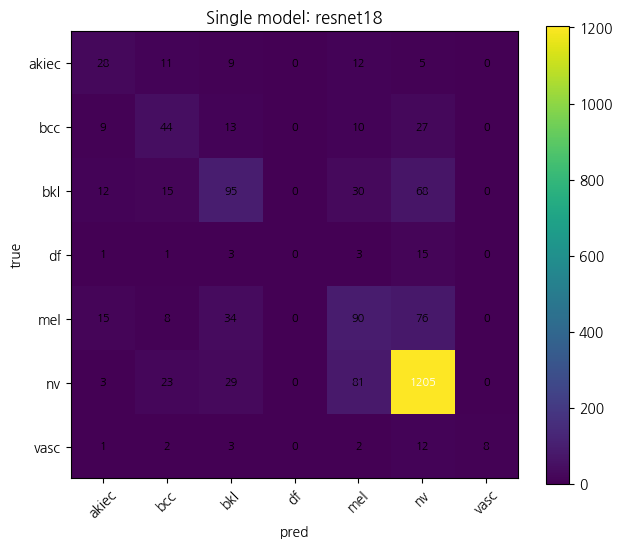

Single model: efficientnet_b0
accuracy    : 0.6965
macro-AUROC : 0.8940

class-wise AUROC
akiec : 0.9204
bcc   : 0.9189
bkl   : 0.8564
df    : 0.9123
mel   : 0.8117
nv    : 0.8930
vasc  : 0.9455

classification report
              precision    recall  f1-score   support

       akiec      0.429     0.369     0.397        65
         bcc      0.385     0.583     0.463       103
         bkl      0.415     0.536     0.468       220
          df      0.400     0.348     0.372        23
         mel      0.369     0.430     0.398       223
          nv      0.902     0.805     0.851      1341
        vasc      0.323     0.357     0.339        28

    accuracy                          0.696      2003
   macro avg      0.460     0.490     0.470      2003
weighted avg      0.734     0.696     0.711      2003



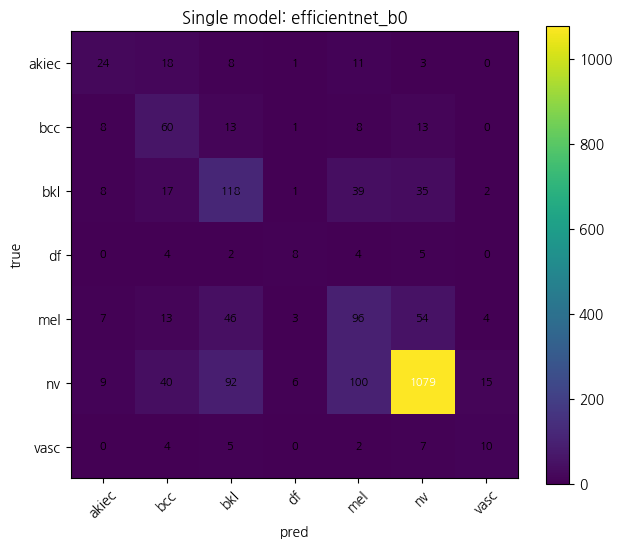

Single model: convnext_tiny
accuracy    : 0.7718
macro-AUROC : 0.9405

class-wise AUROC
akiec : 0.9564
bcc   : 0.9569
bkl   : 0.9103
df    : 0.9746
mel   : 0.8761
nv    : 0.9324
vasc  : 0.9769

classification report
              precision    recall  f1-score   support

       akiec      0.596     0.431     0.500        65
         bcc      0.496     0.631     0.556       103
         bkl      0.696     0.436     0.536       220
          df      0.306     0.652     0.417        23
         mel      0.443     0.570     0.498       223
          nv      0.903     0.893     0.898      1341
        vasc      0.692     0.643     0.667        28

    accuracy                          0.772      2003
   macro avg      0.590     0.608     0.582      2003
weighted avg      0.789     0.772     0.774      2003



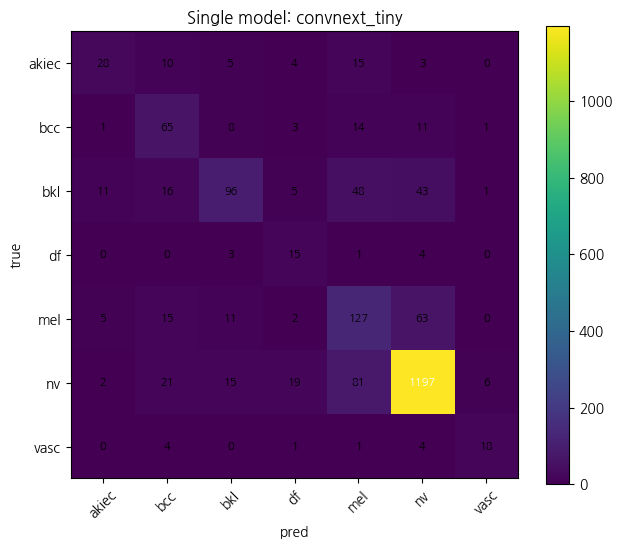

Soft Voting: ResNet18 + EfficientNet-B0 + ConvNeXt-Tiny
accuracy    : 0.7993
macro-AUROC : 0.9472

class-wise AUROC
akiec : 0.9659
bcc   : 0.9633
bkl   : 0.9256
df    : 0.9764
mel   : 0.8846
nv    : 0.9403
vasc  : 0.9741

classification report
              precision    recall  f1-score   support

       akiec      0.568     0.385     0.459        65
         bcc      0.543     0.680     0.603       103
         bkl      0.702     0.568     0.628       220
          df      0.643     0.391     0.486        23
         mel      0.488     0.556     0.520       223
          nv      0.902     0.919     0.910      1341
        vasc      0.889     0.571     0.696        28

    accuracy                          0.799      2003
   macro avg      0.676     0.581     0.615      2003
weighted avg      0.801     0.799     0.798      2003



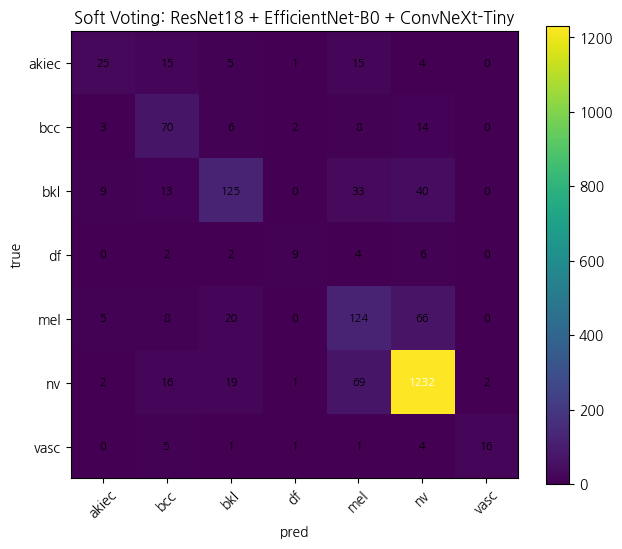

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Stacking on meta-valid split
accuracy    : 0.8114
macro-AUROC : 0.9431

class-wise AUROC
akiec : 0.9693
bcc   : 0.9587
bkl   : 0.9274
df    : 0.9526
mel   : 0.8819
nv    : 0.9480
vasc  : 0.9635

classification report
              precision    recall  f1-score   support

       akiec      0.522     0.375     0.436        32
         bcc      0.596     0.538     0.566        52
         bkl      0.663     0.627     0.645       110
          df      0.833     0.455     0.588        11
         mel      0.575     0.411     0.479       112
          nv      0.879     0.961     0.918       671
        vasc      1.000     0.571     0.727        14

    accuracy                          0.811      1002
   macro avg      0.724     0.563     0.623      1002
weighted avg      0.796     0.811     0.799      1002



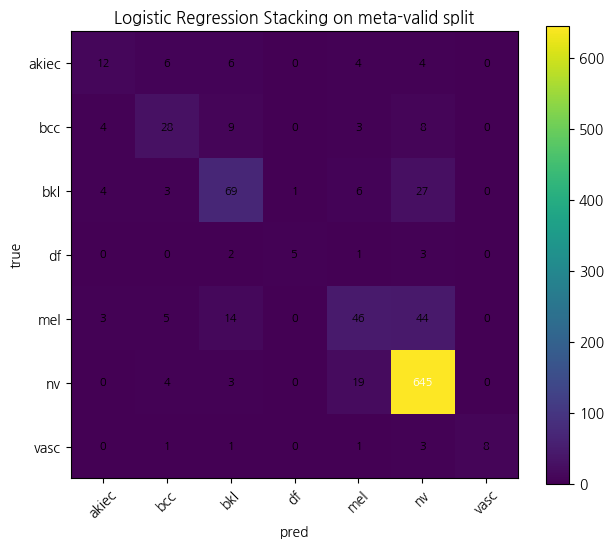


공정 비교: meta-valid split 기준


,method,accuracy,macro_auroc
3,soft_voting,0.805389,0.947379
4,logistic_stacking,0.811377,0.943067
2,convnext_tiny,0.771457,0.941679
0,resnet18,0.728543,0.900288
1,efficientnet_b0,0.701597,0.894861



Logistic Regression Stacking coefficients


,resnet18_akiec,resnet18_bcc,resnet18_bkl,resnet18_df,resnet18_mel,resnet18_nv,resnet18_vasc,efficientnet_b0_akiec,efficientnet_b0_bcc,efficientnet_b0_bkl,...,efficientnet_b0_mel,efficientnet_b0_nv,efficientnet_b0_vasc,convnext_tiny_akiec,convnext_tiny_bcc,convnext_tiny_bkl,convnext_tiny_df,convnext_tiny_mel,convnext_tiny_nv,convnext_tiny_vasc
akiec,1.300324,-0.046228,-0.350851,-0.017098,0.148450,-0.851052,-0.186381,1.725861,0.506735,-0.471307,...,-0.379979,-0.868639,-0.250416,2.035958,-0.084658,-0.376537,-0.438687,0.158990,-0.868829,-0.429072
bcc,-0.405889,1.026987,-0.016349,0.137022,-0.502452,-0.243028,-0.003121,-0.618014,1.136559,-0.277834,...,-0.346178,-0.016812,-0.111426,-0.567426,2.411712,-0.259280,-0.174921,-0.446178,-0.847871,-0.122866
bkl,-0.164476,0.128801,1.131048,-0.034034,-0.560305,-0.389748,-0.038887,-0.221987,-0.237354,1.609745,...,0.326040,0.121947,-0.569442,0.137808,-0.446244,2.007364,-0.786783,0.097848,-0.191478,-0.746116
df,-0.076448,-0.013995,-0.094646,0.024378,-0.130705,0.145081,0.012658,-0.252700,-0.364845,-1.008911,...,0.141260,-0.090108,-0.189476,-0.234662,-0.684002,-0.323163,2.447661,-0.762183,-0.320495,-0.256833
mel,-0.089869,-0.898657,-0.253133,0.015491,1.445384,0.057641,-0.257185,-0.034739,-0.629734,0.278833,...,0.862529,0.035115,-0.297505,-0.597926,-0.733933,0.021430,-0.364324,1.719749,0.496081,-0.521404
nv,-0.514931,-0.204737,-0.100321,-0.111441,-0.000700,1.505940,-0.448261,-0.572510,-0.476358,-0.019625,...,0.027613,1.332253,0.163766,-0.376102,-0.556812,-0.518102,-0.302191,0.274714,2.006094,-0.402053
vasc,-0.048712,0.007828,-0.315748,-0.014317,-0.399671,-0.224834,0.921177,-0.025911,0.064997,-0.110901,...,-0.631285,-0.513756,1.254499,-0.397650,0.093937,-0.551711,-0.380754,-1.042941,-0.273503,2.478344


Stacking 실험 완료
가장 중요한 비교표는 stack_compare_df 입니다.
logistic_stacking이 soft_voting 또는 convnext_tiny보다 높으면 채택 후보입니다.


In [47]:
# =========================================================
# Experiment. Backbone Probability Stacking
# - ResNet18 / EfficientNet-B0 / ConvNeXt-Tiny 확률 결합
# - Soft Voting
# - Logistic Regression Stacking
# - Macro-AUROC 기준 비교
# =========================================================

import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 0. 사용 가능한 backbone model 확인
# ---------------------------------------------------------

required_archs = ["resnet18", "efficientnet_b0", "convnext_tiny"]

if "backbone_results" not in globals():
    raise RuntimeError(
        "backbone_results가 없습니다. 먼저 Backbone 비교 실험 셀을 실행해야 합니다."
    )

for arch in required_archs:
    if arch not in backbone_results:
        raise RuntimeError(f"backbone_results 안에 {arch} 결과가 없습니다.")
    if "model" not in backbone_results[arch]:
        raise RuntimeError(f"backbone_results['{arch}']['model']이 없습니다.")

print("=" * 70)
print("Stacking에 사용할 backbone models")
for arch in required_archs:
    print(f"- {arch}")
print("=" * 70)


# ---------------------------------------------------------
# 1. validation loader 준비
# ---------------------------------------------------------

if "val_loader_bb" in globals():
    stack_val_loader = val_loader_bb
    print("val_loader_bb 사용")
elif "safe_val_loader" in globals():
    stack_val_loader = safe_val_loader
    print("safe_val_loader 사용")
elif "val_loader" in globals():
    stack_val_loader = DataLoader(
        val_loader.dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )
    print("val_loader 기반 safe loader 재생성")
else:
    raise RuntimeError("사용 가능한 validation loader가 없습니다.")


# ---------------------------------------------------------
# 2. 모델별 probability 수집
# ---------------------------------------------------------

def collect_model_probs(model, loader, device):
    model.eval()

    probs_list = []
    y_list = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="collect probs", leave=False, dynamic_ncols=True):
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            probs_list.append(probs.cpu().numpy())
            y_list.append(y.numpy())

    probs = np.concatenate(probs_list, axis=0)
    y_true = np.concatenate(y_list, axis=0)

    return y_true, probs


probs_by_arch = {}
ys_ref = None

for arch in required_archs:
    print(f"\nCollecting probability: {arch}")

    model = backbone_results[arch]["model"]
    ys, probs = collect_model_probs(model, stack_val_loader, device)

    if ys_ref is None:
        ys_ref = ys
    else:
        assert np.array_equal(ys_ref, ys), "모델별 validation label 순서가 일치하지 않습니다."

    probs_by_arch[arch] = probs


# ---------------------------------------------------------
# 3. 평가 함수
# ---------------------------------------------------------

def evaluate_probs(ys, probs, class_names, title=""):
    preds = probs.argmax(axis=1)

    acc = accuracy_score(ys, preds)
    macro_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average="macro",
    )
    per_class_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average=None,
    )

    print("=" * 70)
    print(title)
    print(f"accuracy    : {acc:.4f}")
    print(f"macro-AUROC : {macro_auc:.4f}")

    print("\nclass-wise AUROC")
    for c, v in zip(class_names, per_class_auc):
        print(f"{c:6s}: {v:.4f}")

    print("\nclassification report")
    print(classification_report(
        ys,
        preds,
        target_names=class_names,
        digits=3,
        zero_division=0,
    ))

    cm = confusion_matrix(ys, preds)

    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(cm)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45)
    ax.set_yticklabels(class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=8,
                color="white" if cm[i, j] > cm.max() / 2 else "black",
            )

    ax.set_xlabel("pred")
    ax.set_ylabel("true")
    ax.set_title(title)
    plt.colorbar(im)
    plt.tight_layout()
    plt.show()

    return {
        "title": title,
        "accuracy": acc,
        "macro_auroc": macro_auc,
        "per_class_auroc": dict(zip(class_names, per_class_auc)),
        "confusion_matrix": cm,
    }


# ---------------------------------------------------------
# 4. 개별 모델 성능 확인
# ---------------------------------------------------------

single_results = {}

for arch in required_archs:
    single_results[arch] = evaluate_probs(
        ys_ref,
        probs_by_arch[arch],
        CLASSES,
        title=f"Single model: {arch}",
    )


# ---------------------------------------------------------
# 5. Soft Voting
# ---------------------------------------------------------

soft_vote_probs = np.mean(
    [probs_by_arch[arch] for arch in required_archs],
    axis=0,
)

soft_vote_result = evaluate_probs(
    ys_ref,
    soft_vote_probs,
    CLASSES,
    title="Soft Voting: ResNet18 + EfficientNet-B0 + ConvNeXt-Tiny",
)


# ---------------------------------------------------------
# 6. Logistic Regression Stacking
# validation set을 meta-train / meta-valid로 다시 나누어 과적합 평가 방지
# ---------------------------------------------------------

X_stack = np.concatenate(
    [probs_by_arch[arch] for arch in required_archs],
    axis=1,
)

y_stack = ys_ref

idx_all = np.arange(len(y_stack))

idx_meta_train, idx_meta_valid = train_test_split(
    idx_all,
    test_size=0.5,
    stratify=y_stack,
    random_state=SEED,
)

X_meta_train = X_stack[idx_meta_train]
y_meta_train = y_stack[idx_meta_train]

X_meta_valid = X_stack[idx_meta_valid]
y_meta_valid = y_stack[idx_meta_valid]

stacker = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs",
    C=1.0,
    n_jobs=-1,
)

stacker.fit(X_meta_train, y_meta_train)

stack_probs_valid = stacker.predict_proba(X_meta_valid)

stack_result = evaluate_probs(
    y_meta_valid,
    stack_probs_valid,
    CLASSES,
    title="Logistic Regression Stacking on meta-valid split",
)


# ---------------------------------------------------------
# 7. 같은 meta-valid split에서 개별 모델 / soft voting과 공정 비교
# ---------------------------------------------------------

compare_rows = []

for arch in required_archs:
    p = probs_by_arch[arch][idx_meta_valid]

    compare_rows.append({
        "method": arch,
        "accuracy": accuracy_score(y_meta_valid, p.argmax(axis=1)),
        "macro_auroc": roc_auc_score(
            y_meta_valid,
            p,
            multi_class="ovr",
            average="macro",
        ),
    })

p_soft_valid = soft_vote_probs[idx_meta_valid]

compare_rows.append({
    "method": "soft_voting",
    "accuracy": accuracy_score(y_meta_valid, p_soft_valid.argmax(axis=1)),
    "macro_auroc": roc_auc_score(
        y_meta_valid,
        p_soft_valid,
        multi_class="ovr",
        average="macro",
    ),
})

compare_rows.append({
    "method": "logistic_stacking",
    "accuracy": accuracy_score(y_meta_valid, stack_probs_valid.argmax(axis=1)),
    "macro_auroc": roc_auc_score(
        y_meta_valid,
        stack_probs_valid,
        multi_class="ovr",
        average="macro",
    ),
})

stack_compare_df = pd.DataFrame(compare_rows).sort_values(
    "macro_auroc",
    ascending=False,
)

print("\n공정 비교: meta-valid split 기준")
display(stack_compare_df)


# ---------------------------------------------------------
# 8. Stacking coefficient 확인
# ---------------------------------------------------------

feature_names = []

for arch in required_archs:
    for cls in CLASSES:
        feature_names.append(f"{arch}_{cls}")

coef_df = pd.DataFrame(
    stacker.coef_,
    columns=feature_names,
    index=CLASSES,
)

print("\nLogistic Regression Stacking coefficients")
display(coef_df)


# ---------------------------------------------------------
# 9. 최종 요약
# ---------------------------------------------------------

print("=" * 70)
print("Stacking 실험 완료")
print("가장 중요한 비교표는 stack_compare_df 입니다.")
print("logistic_stacking이 soft_voting 또는 convnext_tiny보다 높으면 채택 후보입니다.")
print("=" * 70)

### 11. Ridge Regression Stacking

Ridge Regression Stacking on meta-valid split
accuracy    : 0.8044
macro-AUROC : 0.9449

class-wise AUROC
akiec : 0.9590
bcc   : 0.9441
bkl   : 0.9371
df    : 0.9733
mel   : 0.8865
nv    : 0.9504
vasc  : 0.9639

classification report
              precision    recall  f1-score   support

       akiec      0.407     0.344     0.373        32
         bcc      0.491     0.519     0.505        52
         bkl      0.677     0.609     0.641       110
          df      0.750     0.545     0.632        11
         mel      0.577     0.402     0.474       112
          nv      0.886     0.957     0.920       671
        vasc      0.800     0.571     0.667        14

    accuracy                          0.804      1002
   macro avg      0.655     0.564     0.601      1002
weighted avg      0.790     0.804     0.794      1002



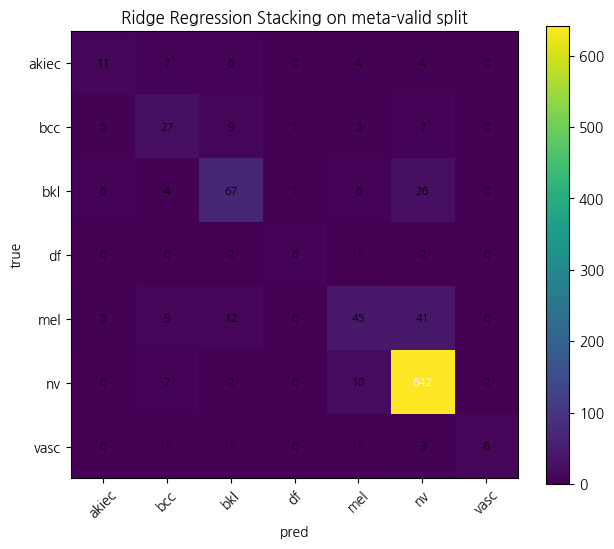


Stacking 비교표


,method,accuracy,macro_auroc
3,soft_voting,0.805389,0.947379
5,ridge_stacking_alpha_1.0,0.804391,0.944890
4,logistic_stacking,0.811377,0.943067
2,convnext_tiny,0.771457,0.941679
0,resnet18,0.728543,0.900288
1,efficientnet_b0,0.701597,0.894861



Ridge alpha sweep 결과


,alpha,accuracy,macro_auroc
6,10.00,0.808383,0.947525
7,30.00,0.804391,0.947207
5,3.00,0.803393,0.945831
4,1.00,0.804391,0.944890
3,0.30,0.806387,0.944146
2,0.10,0.805389,0.943712
8,100.00,0.775449,0.943001
1,0.03,0.806387,0.941757
0,0.01,0.806387,0.939681


In [48]:
# =========================================================
# Ridge Regression Stacking
# - Logistic Regression 대신 Ridge 회귀 기반 메타모델 사용
# - 7개 클래스 one-hot target을 Ridge로 예측
# - 예측값을 clip + normalize 해서 probability처럼 사용
# =========================================================

import numpy as np
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.multioutput import MultiOutputRegressor
from sklearn.metrics import accuracy_score, roc_auc_score

# ---------------------------------------------------------
# 1. 기존 stacking feature 확인
# ---------------------------------------------------------

if "X_stack" not in globals() or "y_stack" not in globals():
    required_archs = ["resnet18", "efficientnet_b0", "convnext_tiny"]

    if "probs_by_arch" not in globals():
        raise RuntimeError("probs_by_arch가 없습니다. 기존 stacking 셀에서 모델별 probability 수집을 먼저 실행해야 합니다.")

    X_stack = np.concatenate(
        [probs_by_arch[arch] for arch in required_archs],
        axis=1,
    )
    y_stack = ys_ref

if "idx_meta_train" not in globals() or "idx_meta_valid" not in globals():
    idx_all = np.arange(len(y_stack))

    idx_meta_train, idx_meta_valid = train_test_split(
        idx_all,
        test_size=0.5,
        stratify=y_stack,
        random_state=SEED,
    )

X_meta_train = X_stack[idx_meta_train]
y_meta_train = y_stack[idx_meta_train]

X_meta_valid = X_stack[idx_meta_valid]
y_meta_valid = y_stack[idx_meta_valid]


# ---------------------------------------------------------
# 2. Ridge Stacking 학습
# ---------------------------------------------------------

y_meta_train_oh = np.eye(len(CLASSES))[y_meta_train]

ridge_stacker = MultiOutputRegressor(
    Ridge(
        alpha=1.0,
        random_state=SEED,
    )
)

ridge_stacker.fit(X_meta_train, y_meta_train_oh)


# ---------------------------------------------------------
# 3. 확률 형태로 변환
# ---------------------------------------------------------

ridge_raw_valid = ridge_stacker.predict(X_meta_valid)

ridge_probs_valid = np.clip(ridge_raw_valid, 1e-8, None)
ridge_probs_valid = ridge_probs_valid / ridge_probs_valid.sum(axis=1, keepdims=True)


# ---------------------------------------------------------
# 4. 평가
# ---------------------------------------------------------

ridge_stack_result = evaluate_probs(
    y_meta_valid,
    ridge_probs_valid,
    CLASSES,
    title="Ridge Regression Stacking on meta-valid split",
)


# ---------------------------------------------------------
# 5. 기존 결과표에 추가
# ---------------------------------------------------------

if "compare_rows" not in globals():
    compare_rows = []

compare_rows.append({
    "method": "ridge_stacking_alpha_1.0",
    "accuracy": accuracy_score(y_meta_valid, ridge_probs_valid.argmax(axis=1)),
    "macro_auroc": roc_auc_score(
        y_meta_valid,
        ridge_probs_valid,
        multi_class="ovr",
        average="macro",
    ),
})

stack_compare_df = pd.DataFrame(compare_rows).drop_duplicates(
    subset=["method"],
    keep="last",
).sort_values(
    "macro_auroc",
    ascending=False,
)

print("\nStacking 비교표")
display(stack_compare_df)


# ---------------------------------------------------------
# 6. alpha sweep
# ---------------------------------------------------------

ridge_rows = []

for alpha in [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0, 30.0, 100.0]:
    model = MultiOutputRegressor(
        Ridge(
            alpha=alpha,
            random_state=SEED,
        )
    )

    model.fit(X_meta_train, y_meta_train_oh)
    raw = model.predict(X_meta_valid)

    probs = np.clip(raw, 1e-8, None)
    probs = probs / probs.sum(axis=1, keepdims=True)

    ridge_rows.append({
        "alpha": alpha,
        "accuracy": accuracy_score(y_meta_valid, probs.argmax(axis=1)),
        "macro_auroc": roc_auc_score(
            y_meta_valid,
            probs,
            multi_class="ovr",
            average="macro",
        ),
    })

ridge_alpha_df = pd.DataFrame(ridge_rows).sort_values(
    "macro_auroc",
    ascending=False,
)

print("\nRidge alpha sweep 결과")
display(ridge_alpha_df)

### 12. Weighted Probability Ensemble (ConvNeXt 확률 + Ridge Stacking 확률 가중 결합)

Weighted Ensemble sweep 결과


,convnext_weight,ridge_weight,accuracy,macro_auroc,akiec_auroc,bcc_auroc,bkl_auroc,df_auroc,mel_auroc,nv_auroc,vasc_auroc
6,0.30,0.70,0.797405,0.945238,0.961856,0.949818,0.938331,0.974865,0.888112,0.949374,0.954309
8,0.40,0.60,0.792415,0.945208,0.962951,0.949899,0.938320,0.974956,0.887771,0.948321,0.954237
7,0.35,0.65,0.794411,0.945206,0.962274,0.949777,0.938290,0.975140,0.887891,0.948830,0.954237
9,0.45,0.55,0.792415,0.945125,0.963048,0.949919,0.938331,0.975048,0.887570,0.947794,0.954164
5,0.25,0.75,0.797405,0.945119,0.961534,0.949696,0.938137,0.974314,0.888132,0.949636,0.954381
10,0.50,0.50,0.790419,0.945041,0.963273,0.949939,0.938117,0.975415,0.887269,0.947254,0.954020
4,0.20,0.80,0.800399,0.944947,0.961211,0.949433,0.937821,0.974039,0.887751,0.949919,0.954453
0,0.00,1.00,0.804391,0.944890,0.958956,0.944150,0.937138,0.973305,0.886457,0.950369,0.963852
11,0.55,0.45,0.788423,0.944870,0.963531,0.949838,0.937648,0.975415,0.886738,0.946826,0.954092
3,0.15,0.85,0.802395,0.944838,0.960857,0.948846,0.937699,0.974039,0.887590,0.950311,0.954526


Best Weighted Ensemble
ConvNeXt weight : 0.30
Ridge weight    : 0.70
accuracy        : 0.7974
macro-AUROC     : 0.9452

classification report
              precision    recall  f1-score   support

       akiec      0.393     0.344     0.367        32
         bcc      0.500     0.538     0.519        52
         bkl      0.685     0.555     0.613       110
          df      0.467     0.636     0.538        11
         mel      0.538     0.500     0.519       112
          nv      0.897     0.934     0.915       671
        vasc      0.818     0.643     0.720        14

    accuracy                          0.797      1002
   macro avg      0.614     0.593     0.599      1002
weighted avg      0.791     0.797     0.793      1002



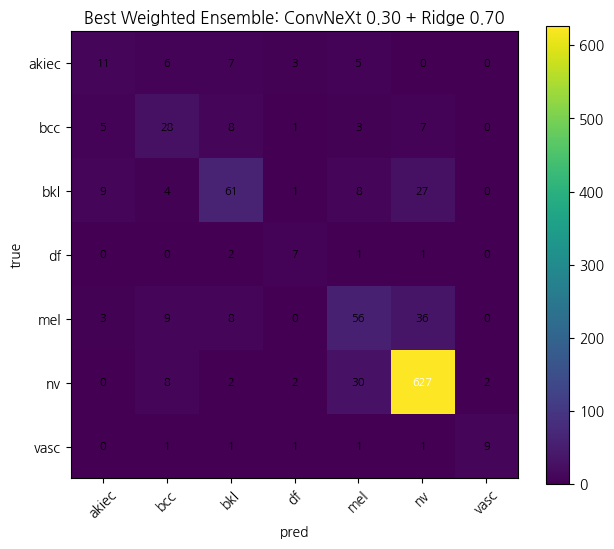

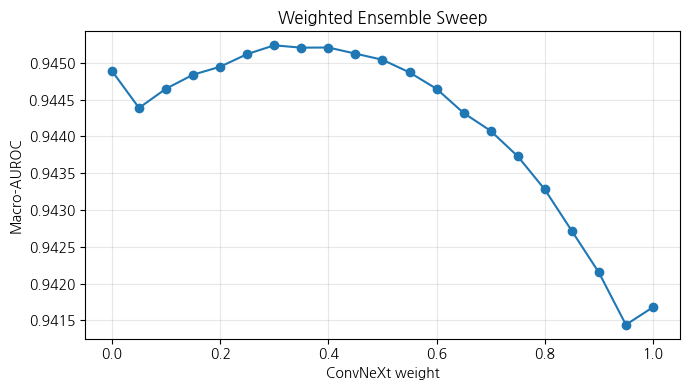

In [49]:
# =========================================================
# Weighted Probability Ensemble
# ConvNeXt 확률 + Ridge Stacking 확률 가중 결합
# 목적:
# - ConvNeXt의 강한 단일 모델 성능 유지
# - Ridge Stacking의 보조 정보를 일부 반영
# - Macro-AUROC 기준 최적 weight 탐색
# =========================================================

import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. 입력 확률 준비
# ---------------------------------------------------------

if "probs_by_arch" not in globals():
    raise RuntimeError("probs_by_arch가 없습니다. Stacking 셀을 먼저 실행하세요.")

if "ridge_probs_valid" not in globals():
    raise RuntimeError("ridge_probs_valid가 없습니다. Ridge Stacking 셀을 먼저 실행하세요.")

if "idx_meta_valid" not in globals() or "y_meta_valid" not in globals():
    raise RuntimeError("idx_meta_valid 또는 y_meta_valid가 없습니다. Stacking 셀을 먼저 실행하세요.")

conv_probs_valid = probs_by_arch["convnext_tiny"][idx_meta_valid]

# ridge_probs_valid는 meta-valid split 기준 확률이어야 함
assert conv_probs_valid.shape == ridge_probs_valid.shape, "ConvNeXt와 Ridge 확률 shape이 다릅니다."

# ---------------------------------------------------------
# 2. ConvNeXt weight sweep
# final = w * ConvNeXt + (1-w) * Ridge
# ---------------------------------------------------------

rows = []

for w in np.arange(0.0, 1.01, 0.05):
    blend_probs = w * conv_probs_valid + (1.0 - w) * ridge_probs_valid
    blend_probs = blend_probs / blend_probs.sum(axis=1, keepdims=True)

    acc = accuracy_score(y_meta_valid, blend_probs.argmax(axis=1))
    macro_auc = roc_auc_score(
        y_meta_valid,
        blend_probs,
        multi_class="ovr",
        average="macro",
    )

    per_auc = roc_auc_score(
        y_meta_valid,
        blend_probs,
        multi_class="ovr",
        average=None,
    )

    row = {
        "convnext_weight": round(float(w), 2),
        "ridge_weight": round(float(1.0 - w), 2),
        "accuracy": acc,
        "macro_auroc": macro_auc,
    }

    for c, v in zip(CLASSES, per_auc):
        row[f"{c}_auroc"] = v

    rows.append(row)

weighted_ensemble_df = pd.DataFrame(rows).sort_values(
    "macro_auroc",
    ascending=False,
)

print("Weighted Ensemble sweep 결과")
display(weighted_ensemble_df)

# ---------------------------------------------------------
# 3. Best weight 결과 상세 평가
# ---------------------------------------------------------

best_row = weighted_ensemble_df.iloc[0]
best_w = float(best_row["convnext_weight"])

best_probs = best_w * conv_probs_valid + (1.0 - best_w) * ridge_probs_valid
best_probs = best_probs / best_probs.sum(axis=1, keepdims=True)
best_preds = best_probs.argmax(axis=1)

print("=" * 80)
print("Best Weighted Ensemble")
print(f"ConvNeXt weight : {best_w:.2f}")
print(f"Ridge weight    : {1.0 - best_w:.2f}")
print(f"accuracy        : {accuracy_score(y_meta_valid, best_preds):.4f}")
print(f"macro-AUROC     : {roc_auc_score(y_meta_valid, best_probs, multi_class='ovr', average='macro'):.4f}")
print("=" * 80)

print("\nclassification report")
print(classification_report(
    y_meta_valid,
    best_preds,
    target_names=CLASSES,
    digits=3,
    zero_division=0,
))

cm = confusion_matrix(y_meta_valid, best_preds)

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm)
plt.xticks(range(len(CLASSES)), CLASSES, rotation=45)
plt.yticks(range(len(CLASSES)), CLASSES)

for i in range(len(CLASSES)):
    for j in range(len(CLASSES)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            color="white" if cm[i, j] > cm.max() / 2 else "black",
            fontsize=8,
        )

plt.xlabel("pred")
plt.ylabel("true")
plt.title(f"Best Weighted Ensemble: ConvNeXt {best_w:.2f} + Ridge {1.0 - best_w:.2f}")
plt.colorbar()
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. 곡선 확인
# ---------------------------------------------------------

plt.figure(figsize=(7, 4))
plt.plot(
    weighted_ensemble_df.sort_values("convnext_weight")["convnext_weight"],
    weighted_ensemble_df.sort_values("convnext_weight")["macro_auroc"],
    marker="o",
)
plt.xlabel("ConvNeXt weight")
plt.ylabel("Macro-AUROC")
plt.title("Weighted Ensemble Sweep")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 13. mel Threshold Optimization

In [51]:
# =========================================================
# mel Threshold Optimization
# 목적:
# - melanoma(mel) sensitivity/recall 우선 threshold 탐색
# - Macro-AUROC는 threshold와 무관하므로 참고값으로만 표시
# =========================================================

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

TARGET_CLASS = "mel"
TARGET_RECALL_MIN = 0.60
THRESHOLDS = np.arange(0.05, 0.81, 0.01)

target_idx = CLASSES.index(TARGET_CLASS)

if "safe_val_loader" in globals():
    threshold_loader = safe_val_loader
elif "val_loader" in globals():
    threshold_loader = DataLoader(
        val_loader.dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )
else:
    raise RuntimeError("safe_val_loader 또는 val_loader가 필요합니다.")


def collect_probs_for_threshold(model, loader):
    model.eval()
    ys_list = []
    probs_list = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="collect probs", leave=False):
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            ys_list.append(y.numpy())
            probs_list.append(probs.cpu().numpy())

    return np.concatenate(ys_list), np.concatenate(probs_list)


def predict_with_target_threshold(probs, target_idx, threshold):
    preds = probs.argmax(axis=1)
    mask = probs[:, target_idx] >= threshold
    preds[mask] = target_idx
    return preds


ys, probs = collect_probs_for_threshold(model_C, threshold_loader)

base_preds = probs.argmax(axis=1)
base_report = classification_report(
    ys,
    base_preds,
    target_names=CLASSES,
    output_dict=True,
    zero_division=0,
)

base_macro_auc = roc_auc_score(
    ys,
    probs,
    multi_class="ovr",
    average="macro",
)

rows = []

for th in THRESHOLDS:
    preds = predict_with_target_threshold(
        probs.copy(),
        target_idx=target_idx,
        threshold=float(th),
    )

    report = classification_report(
        ys,
        preds,
        target_names=CLASSES,
        output_dict=True,
        zero_division=0,
    )

    rows.append({
        "threshold": round(float(th), 2),
        "accuracy": accuracy_score(ys, preds),
        "mel_precision": report[TARGET_CLASS]["precision"],
        "mel_recall_sensitivity": report[TARGET_CLASS]["recall"],
        "mel_f1": report[TARGET_CLASS]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "weighted_f1": report["weighted avg"]["f1-score"],
        "macro_auroc_reference": base_macro_auc,
    })

threshold_df = pd.DataFrame(rows)

candidate_df = threshold_df[
    threshold_df["mel_recall_sensitivity"] >= TARGET_RECALL_MIN
].copy()

if len(candidate_df) > 0:
    best_row = candidate_df.sort_values(
        ["accuracy", "mel_precision", "macro_f1"],
        ascending=False,
    ).iloc[0]
else:
    best_row = threshold_df.sort_values(
        ["mel_recall_sensitivity", "accuracy"],
        ascending=False,
    ).iloc[0]

best_threshold = float(best_row["threshold"])

final_preds = predict_with_target_threshold(
    probs.copy(),
    target_idx=target_idx,
    threshold=best_threshold,
)

print("=" * 80)
print("Baseline top-1")
print(f"accuracy       : {accuracy_score(ys, base_preds):.4f}")
print(f"macro-AUROC    : {base_macro_auc:.4f}")
print(f"mel precision  : {base_report[TARGET_CLASS]['precision']:.4f}")
print(f"mel recall     : {base_report[TARGET_CLASS]['recall']:.4f}")

print("=" * 80)
print("Selected threshold")
print(f"target recall min : {TARGET_RECALL_MIN}")
print(f"threshold         : {best_threshold:.2f}")

display(pd.DataFrame([best_row]))

print("\nThreshold sweep table")
display(
    threshold_df.sort_values(
        ["mel_recall_sensitivity", "accuracy"],
        ascending=False,
    ).head(30)
)

print("\nFinal classification report")
print(classification_report(
    ys,
    final_preds,
    target_names=CLASSES,
    digits=3,
    zero_division=0,
))

print("\nConfusion matrix")
cm = confusion_matrix(ys, final_preds)
display(
    pd.DataFrame(
        cm,
        index=[f"true_{c}" for c in CLASSES],
        columns=[f"pred_{c}" for c in CLASSES],
    )
)

collect probs:   0%|          | 0/63 [00:00<?, ?it/s]

Baseline top-1
accuracy       : 0.8482
macro-AUROC    : 0.9668
mel precision  : 0.7483
mel recall     : 0.4933
Selected threshold
target recall min : 0.6
threshold         : 0.28


,threshold,accuracy,mel_precision,mel_recall_sensitivity,mel_f1,macro_f1,weighted_f1,macro_auroc_reference
23,0.28,0.844733,0.650485,0.600897,0.624709,0.716491,0.842594,0.966819



Threshold sweep table


,threshold,accuracy,mel_precision,mel_recall_sensitivity,mel_f1,macro_f1,weighted_f1,macro_auroc_reference
0,0.05,0.781328,0.399573,0.838565,0.541245,0.671224,0.795435,0.966819
1,0.06,0.792312,0.419501,0.829596,0.557229,0.677606,0.804190,0.966819
2,0.07,0.798303,0.432367,0.802691,0.562009,0.679010,0.808337,0.966819
3,0.08,0.808288,0.456186,0.793722,0.579378,0.686098,0.816148,0.966819
4,0.09,0.815776,0.478142,0.784753,0.594228,0.689716,0.822032,0.966819
6,0.11,0.825761,0.508876,0.771300,0.613191,0.694047,0.829848,0.966819
5,0.10,0.819770,0.490028,0.771300,0.599303,0.690711,0.824948,0.966819
7,0.12,0.826760,0.518634,0.748879,0.612844,0.699106,0.830459,0.966819
8,0.13,0.831253,0.540717,0.744395,0.626415,0.702281,0.833943,0.966819
9,0.14,0.833250,0.548495,0.735426,0.628352,0.703040,0.835478,0.966819



Final classification report
              precision    recall  f1-score   support

       akiec      0.642     0.662     0.652        65
         bcc      0.706     0.816     0.757       103
         bkl      0.703     0.668     0.685       220
          df      0.750     0.522     0.615        23
         mel      0.650     0.601     0.625       223
          nv      0.917     0.936     0.926      1341
        vasc      1.000     0.607     0.756        28

    accuracy                          0.845      2003
   macro avg      0.767     0.687     0.716      2003
weighted avg      0.843     0.845     0.843      2003


Confusion matrix


,pred_akiec,pred_bcc,pred_bkl,pred_df,pred_mel,pred_nv,pred_vasc
true_akiec,43,12,2,1,2,5,0
true_bcc,3,84,4,0,1,11,0
true_bkl,10,8,147,0,17,38,0
true_df,2,0,0,12,1,8,0
true_mel,9,4,28,1,134,47,0
true_nv,0,8,27,2,49,1255,0
true_vasc,0,3,1,0,2,5,17


### 14. ConvNeXt + OVR Expert Soft Ensemble

collect base + OVR probs:   0%|          | 0/63 [00:00<?, ?it/s]

Base ConvNeXt 7-class probability
accuracy    : 0.8477
macro-AUROC : 0.9699
mel precision : 0.6928
mel recall    : 0.5157
mel f1        : 0.5913

class-wise AUROC
akiec : 0.9703
bcc   : 0.9892
bkl   : 0.9557
df    : 0.9946
mel   : 0.9215
nv    : 0.9611
vasc  : 0.9972

classification report
              precision    recall  f1-score   support

       akiec      0.657     0.708     0.681        65
         bcc      0.724     0.816     0.767       103
         bkl      0.788     0.591     0.675       220
          df      0.900     0.783     0.837        23
         mel      0.693     0.516     0.591       223
          nv      0.890     0.960     0.924      1341
        vasc      0.900     0.643     0.750        28

    accuracy                          0.848      2003
   macro avg      0.793     0.716     0.747      2003
weighted avg      0.841     0.848     0.840      2003



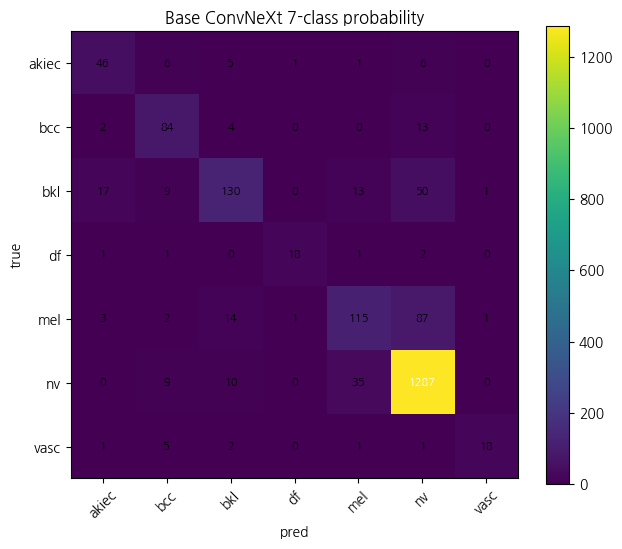


OVR Soft Ensemble alpha sweep 결과


,alpha,accuracy,macro_auroc,mel_auroc,mel_precision,mel_recall,mel_f1,macro_f1
0,0.00,0.847728,0.969942,0.921542,0.692771,0.515695,0.591260,0.746567
1,0.05,0.847229,0.969173,0.915874,0.688623,0.515695,0.589744,0.747625
2,0.10,0.847229,0.968084,0.909651,0.684211,0.524664,0.593909,0.748222
3,0.15,0.847728,0.967535,0.907324,0.682081,0.529148,0.595960,0.749497
4,0.20,0.848228,0.967119,0.905968,0.677966,0.538117,0.600000,0.750385
5,0.25,0.848228,0.966787,0.904892,0.675978,0.542601,0.601990,0.750866
6,0.30,0.847728,0.966520,0.904028,0.666667,0.547085,0.600985,0.751402
7,0.35,0.848228,0.966200,0.902945,0.666667,0.556054,0.606357,0.752208
8,0.40,0.849725,0.965819,0.901494,0.659794,0.573991,0.613909,0.753826
9,0.45,0.850225,0.965430,0.900219,0.659898,0.582960,0.619048,0.754600


ConvNeXt + OVR Expert Soft Ensemble alpha=0.00
accuracy    : 0.8477
macro-AUROC : 0.9699
mel precision : 0.6928
mel recall    : 0.5157
mel f1        : 0.5913

class-wise AUROC
akiec : 0.9703
bcc   : 0.9892
bkl   : 0.9557
df    : 0.9946
mel   : 0.9215
nv    : 0.9611
vasc  : 0.9972

classification report
              precision    recall  f1-score   support

       akiec      0.657     0.708     0.681        65
         bcc      0.724     0.816     0.767       103
         bkl      0.788     0.591     0.675       220
          df      0.900     0.783     0.837        23
         mel      0.693     0.516     0.591       223
          nv      0.890     0.960     0.924      1341
        vasc      0.900     0.643     0.750        28

    accuracy                          0.848      2003
   macro avg      0.793     0.716     0.747      2003
weighted avg      0.841     0.848     0.840      2003



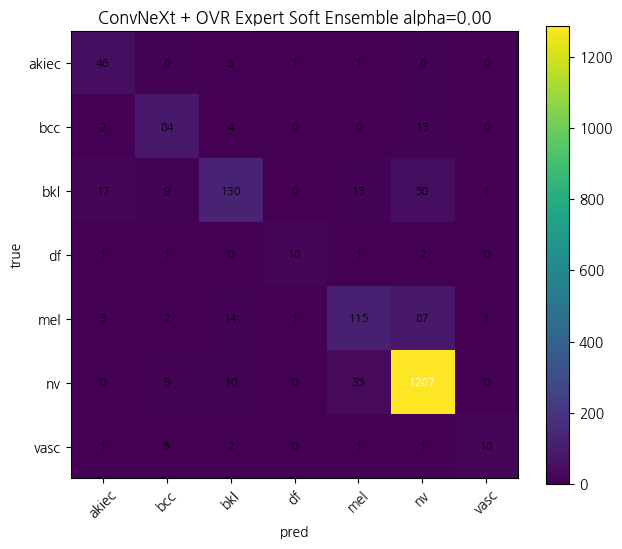

Best alpha
alpha        : 0.00
accuracy     : 0.8477
macro-AUROC  : 0.9699
mel AUROC    : 0.9215
mel precision: 0.6928
mel recall   : 0.5157
mel F1       : 0.5913


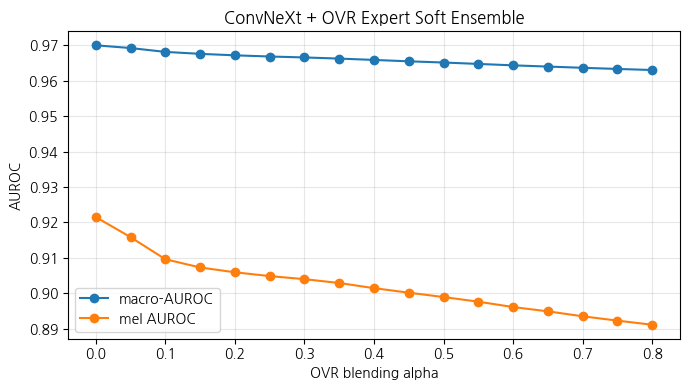

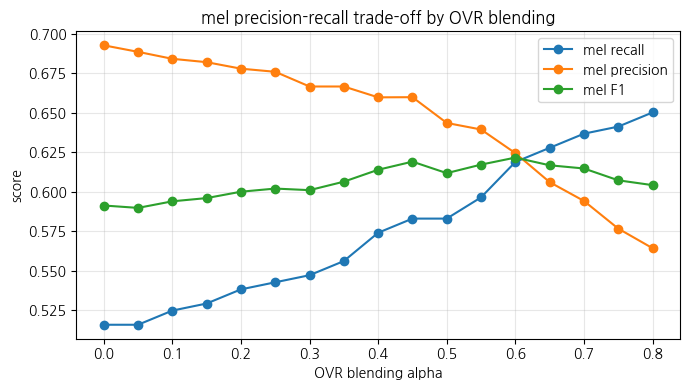

In [31]:
# =========================================================
# ConvNeXt + OVR Expert Soft Ensemble
# 목적:
# - 기존 7-class ConvNeXt(model_C)의 확률을 유지
# - mel vs rest OVR Expert(model_ovr_mel)의 mel 확률을 결합
# - hard label 변경이 아니라 probability-level soft blending 수행
# - Macro-AUROC와 mel recall 변화를 함께 확인
# =========================================================

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)
import matplotlib.pyplot as plt

TARGET_CLASS = "mel"
target_idx = CLASSES.index(TARGET_CLASS)

if "model_C" not in globals():
    raise RuntimeError("model_C가 없습니다. 기존 ConvNeXt 7-class 모델이 필요합니다.")

if "model_ovr_mel" not in globals():
    raise RuntimeError("model_ovr_mel이 없습니다. mel vs rest OVR Expert 모델이 필요합니다.")

if "safe_val_loader" in globals():
    ensemble_loader = safe_val_loader
elif "val_loader" in globals():
    ensemble_loader = DataLoader(
        val_loader.dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )
else:
    raise RuntimeError("safe_val_loader 또는 val_loader가 필요합니다.")


def collect_base_and_ovr_probs(base_model, ovr_model, loader):
    base_model.eval()
    ovr_model.eval()

    ys_list = []
    base_probs_list = []
    ovr_probs_list = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="collect base + OVR probs", leave=False):
            x = x.to(device)

            base_logits = base_model(x)
            base_probs = torch.softmax(base_logits, dim=1)

            ovr_logits = ovr_model(x)
            ovr_mel_probs = torch.softmax(ovr_logits, dim=1)[:, 1]

            ys_list.append(y.numpy())
            base_probs_list.append(base_probs.cpu().numpy())
            ovr_probs_list.append(ovr_mel_probs.cpu().numpy())

    ys = np.concatenate(ys_list)
    base_probs = np.concatenate(base_probs_list)
    ovr_mel_probs = np.concatenate(ovr_probs_list)

    return ys, base_probs, ovr_mel_probs


ys, base_probs, ovr_mel_probs = collect_base_and_ovr_probs(
    model_C,
    model_ovr_mel,
    ensemble_loader,
)


def evaluate_prob_result(ys, probs, class_names, title):
    preds = probs.argmax(axis=1)

    acc = accuracy_score(ys, preds)
    macro_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average="macro",
    )
    per_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average=None,
    )

    report = classification_report(
        ys,
        preds,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    print("=" * 80)
    print(title)
    print(f"accuracy    : {acc:.4f}")
    print(f"macro-AUROC : {macro_auc:.4f}")
    print(f"{TARGET_CLASS} precision : {report[TARGET_CLASS]['precision']:.4f}")
    print(f"{TARGET_CLASS} recall    : {report[TARGET_CLASS]['recall']:.4f}")
    print(f"{TARGET_CLASS} f1        : {report[TARGET_CLASS]['f1-score']:.4f}")

    print("\nclass-wise AUROC")
    for c, v in zip(class_names, per_auc):
        print(f"{c:6s}: {v:.4f}")

    print("\nclassification report")
    print(classification_report(
        ys,
        preds,
        target_names=class_names,
        digits=3,
        zero_division=0,
    ))

    cm = confusion_matrix(ys, preds)

    plt.figure(figsize=(6.5, 5.5))
    plt.imshow(cm)
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks(range(len(class_names)), class_names)

    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(
                j,
                i,
                cm[i, j],
                ha="center",
                va="center",
                fontsize=8,
                color="white" if cm[i, j] > cm.max() / 2 else "black",
            )

    plt.xlabel("pred")
    plt.ylabel("true")
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "macro_auroc": macro_auc,
        "per_class_auroc": dict(zip(class_names, per_auc)),
        "classification_report": report,
        "confusion_matrix": cm,
    }


base_result_for_ovr_soft = evaluate_prob_result(
    ys,
    base_probs,
    CLASSES,
    title="Base ConvNeXt 7-class probability",
)


rows = []

for alpha in np.arange(0.0, 0.81, 0.05):
    probs = base_probs.copy()

    probs[:, target_idx] = (
        (1.0 - alpha) * base_probs[:, target_idx]
        + alpha * ovr_mel_probs
    )

    probs = probs / probs.sum(axis=1, keepdims=True)
    preds = probs.argmax(axis=1)

    macro_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average="macro",
    )

    per_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average=None,
    )

    report = classification_report(
        ys,
        preds,
        target_names=CLASSES,
        output_dict=True,
        zero_division=0,
    )

    rows.append({
        "alpha": round(float(alpha), 2),
        "accuracy": accuracy_score(ys, preds),
        "macro_auroc": macro_auc,
        "mel_auroc": per_auc[target_idx],
        "mel_precision": report[TARGET_CLASS]["precision"],
        "mel_recall": report[TARGET_CLASS]["recall"],
        "mel_f1": report[TARGET_CLASS]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
    })

ovr_soft_df = pd.DataFrame(rows).sort_values(
    ["macro_auroc", "mel_recall"],
    ascending=[False, False],
)

print("\nOVR Soft Ensemble alpha sweep 결과")
display(ovr_soft_df)


best_row = ovr_soft_df.iloc[0]
best_alpha = float(best_row["alpha"])

best_probs = base_probs.copy()
best_probs[:, target_idx] = (
    (1.0 - best_alpha) * base_probs[:, target_idx]
    + best_alpha * ovr_mel_probs
)
best_probs = best_probs / best_probs.sum(axis=1, keepdims=True)

ovr_soft_best_result = evaluate_prob_result(
    ys,
    best_probs,
    CLASSES,
    title=f"ConvNeXt + OVR Expert Soft Ensemble alpha={best_alpha:.2f}",
)

print("=" * 80)
print("Best alpha")
print(f"alpha        : {best_alpha:.2f}")
print(f"accuracy     : {best_row['accuracy']:.4f}")
print(f"macro-AUROC  : {best_row['macro_auroc']:.4f}")
print(f"mel AUROC    : {best_row['mel_auroc']:.4f}")
print(f"mel precision: {best_row['mel_precision']:.4f}")
print(f"mel recall   : {best_row['mel_recall']:.4f}")
print(f"mel F1       : {best_row['mel_f1']:.4f}")
print("=" * 80)

plt.figure(figsize=(7, 4))
plot_df = ovr_soft_df.sort_values("alpha")
plt.plot(plot_df["alpha"], plot_df["macro_auroc"], marker="o", label="macro-AUROC")
plt.plot(plot_df["alpha"], plot_df["mel_auroc"], marker="o", label="mel AUROC")
plt.xlabel("OVR blending alpha")
plt.ylabel("AUROC")
plt.title("ConvNeXt + OVR Expert Soft Ensemble")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(plot_df["alpha"], plot_df["mel_recall"], marker="o", label="mel recall")
plt.plot(plot_df["alpha"], plot_df["mel_precision"], marker="o", label="mel precision")
plt.plot(plot_df["alpha"], plot_df["mel_f1"], marker="o", label="mel F1")
plt.xlabel("OVR blending alpha")
plt.ylabel("score")
plt.title("mel precision-recall trade-off by OVR blending")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 15. Class-wise Threshold Optimization (mel, bcc, df)

In [53]:
# =========================================================
# Class-wise Threshold Optimization
# 대상: mel, bcc, df
# 목적:
# - 특정 클래스의 sensitivity/recall 우선 운영점 탐색
# - 클래스별 threshold 조정 전후 trade-off 비교
# 주의:
# - Macro-AUROC는 threshold와 무관하므로 reference로만 표시
# =========================================================

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

TARGET_CLASSES = ["mel", "bcc", "df"]
TARGET_RECALL_MIN = 0.60
THRESHOLDS = np.arange(0.05, 0.81, 0.01)

if "safe_val_loader" in globals():
    threshold_loader = safe_val_loader
elif "val_loader" in globals():
    threshold_loader = DataLoader(
        val_loader.dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )
else:
    raise RuntimeError("safe_val_loader 또는 val_loader가 필요합니다.")


def collect_probs_for_threshold(model, loader):
    model.eval()
    ys_list = []
    probs_list = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="collect probs", leave=False):
            x = x.to(device)
            logits = model(x)
            probs = torch.softmax(logits, dim=1)

            ys_list.append(y.numpy())
            probs_list.append(probs.cpu().numpy())

    return np.concatenate(ys_list), np.concatenate(probs_list)


def predict_with_single_class_threshold(probs, target_idx, threshold):
    preds = probs.argmax(axis=1).copy()
    mask = probs[:, target_idx] >= threshold
    preds[mask] = target_idx
    return preds


ys, probs = collect_probs_for_threshold(model_C, threshold_loader)

base_preds = probs.argmax(axis=1)

base_report = classification_report(
    ys,
    base_preds,
    target_names=CLASSES,
    output_dict=True,
    zero_division=0,
)

base_macro_auc = roc_auc_score(
    ys,
    probs,
    multi_class="ovr",
    average="macro",
)

summary_rows = []
all_threshold_tables = {}
all_confusion_matrices = {}

print("=" * 90)
print("Baseline top-1")
print(f"accuracy    : {accuracy_score(ys, base_preds):.4f}")
print(f"macro-AUROC : {base_macro_auc:.4f}")
print("=" * 90)

for target_class in TARGET_CLASSES:
    target_idx = CLASSES.index(target_class)

    rows = []

    for th in THRESHOLDS:
        preds = predict_with_single_class_threshold(
            probs.copy(),
            target_idx=target_idx,
            threshold=float(th),
        )

        report = classification_report(
            ys,
            preds,
            target_names=CLASSES,
            output_dict=True,
            zero_division=0,
        )

        rows.append({
            "target_class": target_class,
            "threshold": round(float(th), 2),
            "accuracy": accuracy_score(ys, preds),
            "precision": report[target_class]["precision"],
            "recall_sensitivity": report[target_class]["recall"],
            "f1": report[target_class]["f1-score"],
            "macro_f1": report["macro avg"]["f1-score"],
            "weighted_f1": report["weighted avg"]["f1-score"],
            "macro_auroc_reference": base_macro_auc,
        })

    threshold_df = pd.DataFrame(rows)

    candidate_df = threshold_df[
        threshold_df["recall_sensitivity"] >= TARGET_RECALL_MIN
    ].copy()

    if len(candidate_df) > 0:
        best_row = candidate_df.sort_values(
            ["accuracy", "precision", "macro_f1"],
            ascending=False,
        ).iloc[0]
    else:
        best_row = threshold_df.sort_values(
            ["recall_sensitivity", "accuracy"],
            ascending=False,
        ).iloc[0]

    best_threshold = float(best_row["threshold"])

    final_preds = predict_with_single_class_threshold(
        probs.copy(),
        target_idx=target_idx,
        threshold=best_threshold,
    )

    final_report = classification_report(
        ys,
        final_preds,
        target_names=CLASSES,
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(ys, final_preds)

    all_threshold_tables[target_class] = threshold_df
    all_confusion_matrices[target_class] = cm

    summary_rows.append({
        "target_class": target_class,
        "baseline_accuracy": accuracy_score(ys, base_preds),
        "threshold_accuracy": accuracy_score(ys, final_preds),
        "accuracy_delta": accuracy_score(ys, final_preds) - accuracy_score(ys, base_preds),

        "baseline_precision": base_report[target_class]["precision"],
        "threshold_precision": final_report[target_class]["precision"],
        "precision_delta": final_report[target_class]["precision"] - base_report[target_class]["precision"],

        "baseline_recall": base_report[target_class]["recall"],
        "threshold_recall": final_report[target_class]["recall"],
        "recall_delta": final_report[target_class]["recall"] - base_report[target_class]["recall"],

        "baseline_f1": base_report[target_class]["f1-score"],
        "threshold_f1": final_report[target_class]["f1-score"],
        "f1_delta": final_report[target_class]["f1-score"] - base_report[target_class]["f1-score"],

        "selected_threshold": best_threshold,
        "macro_auroc_reference": base_macro_auc,
    })

    print("\n" + "=" * 90)
    print(f"Target class: {target_class}")
    print(f"Selected threshold: {best_threshold:.2f}")
    print("-" * 90)
    print(f"baseline precision : {base_report[target_class]['precision']:.4f}")
    print(f"threshold precision: {final_report[target_class]['precision']:.4f}")
    print(f"baseline recall    : {base_report[target_class]['recall']:.4f}")
    print(f"threshold recall   : {final_report[target_class]['recall']:.4f}")
    print(f"baseline f1        : {base_report[target_class]['f1-score']:.4f}")
    print(f"threshold f1       : {final_report[target_class]['f1-score']:.4f}")
    print(f"baseline accuracy  : {accuracy_score(ys, base_preds):.4f}")
    print(f"threshold accuracy : {accuracy_score(ys, final_preds):.4f}")

    print("\nTop threshold candidates")
    display(
        threshold_df.sort_values(
            ["recall_sensitivity", "accuracy"],
            ascending=False,
        ).head(20)
    )

    print("\nConfusion matrix")
    display(
        pd.DataFrame(
            cm,
            index=[f"true_{c}" for c in CLASSES],
            columns=[f"pred_{c}" for c in CLASSES],
        )
    )


classwise_threshold_summary = pd.DataFrame(summary_rows).sort_values(
    "recall_delta",
    ascending=False,
)

print("\n" + "=" * 90)
print("Class-wise threshold optimization summary")
display(classwise_threshold_summary)

print("\n해석 기준")
print("- recall_delta가 크고 accuracy_delta가 작으면 sensitivity 우선 운영점으로 의미가 있습니다.")
print("- precision_delta가 크게 음수이면 false positive 증가가 큽니다.")
print("- Macro-AUROC는 threshold와 무관하므로 reference로만 사용합니다.")

collect probs:   0%|          | 0/63 [00:00<?, ?it/s]

Baseline top-1
accuracy    : 0.8482
macro-AUROC : 0.9668

Target class: mel
Selected threshold: 0.28
------------------------------------------------------------------------------------------
baseline precision : 0.7483
threshold precision: 0.6505
baseline recall    : 0.4933
threshold recall   : 0.6009
baseline f1        : 0.5946
threshold f1       : 0.6247
baseline accuracy  : 0.8482
threshold accuracy : 0.8447

Top threshold candidates


,target_class,threshold,accuracy,precision,recall_sensitivity,f1,macro_f1,weighted_f1,macro_auroc_reference
0,mel,0.05,0.781328,0.399573,0.838565,0.541245,0.671224,0.795435,0.966819
1,mel,0.06,0.792312,0.419501,0.829596,0.557229,0.677606,0.804190,0.966819
2,mel,0.07,0.798303,0.432367,0.802691,0.562009,0.679010,0.808337,0.966819
3,mel,0.08,0.808288,0.456186,0.793722,0.579378,0.686098,0.816148,0.966819
4,mel,0.09,0.815776,0.478142,0.784753,0.594228,0.689716,0.822032,0.966819
6,mel,0.11,0.825761,0.508876,0.771300,0.613191,0.694047,0.829848,0.966819
5,mel,0.10,0.819770,0.490028,0.771300,0.599303,0.690711,0.824948,0.966819
7,mel,0.12,0.826760,0.518634,0.748879,0.612844,0.699106,0.830459,0.966819
8,mel,0.13,0.831253,0.540717,0.744395,0.626415,0.702281,0.833943,0.966819
9,mel,0.14,0.833250,0.548495,0.735426,0.628352,0.703040,0.835478,0.966819



Confusion matrix


,pred_akiec,pred_bcc,pred_bkl,pred_df,pred_mel,pred_nv,pred_vasc
true_akiec,43,12,2,1,2,5,0
true_bcc,3,84,4,0,1,11,0
true_bkl,10,8,147,0,17,38,0
true_df,2,0,0,12,1,8,0
true_mel,9,4,28,1,134,47,0
true_nv,0,8,27,2,49,1255,0
true_vasc,0,3,1,0,2,5,17


...


Confusion matrix


,pred_akiec,pred_bcc,pred_bkl,pred_df,pred_mel,pred_nv,pred_vasc
true_akiec,43,13,2,1,1,5,0
true_bcc,3,84,4,0,1,11,0
true_bkl,10,8,156,0,7,39,0
true_df,2,0,0,15,0,6,0
true_mel,11,6,34,1,110,61,0
true_nv,0,8,28,2,26,1277,0
true_vasc,0,3,1,0,2,5,17



Class-wise threshold optimization summary


,target_class,baseline_accuracy,threshold_accuracy,accuracy_delta,baseline_precision,threshold_precision,precision_delta,baseline_recall,threshold_recall,recall_delta,baseline_f1,threshold_f1,f1_delta,selected_threshold,macro_auroc_reference
2,df,0.848228,0.849725,0.001498,0.750000,0.789474,0.039474,0.521739,0.652174,0.130435,0.615385,0.714286,0.098901,0.18,0.966819
0,mel,0.848228,0.844733,-0.003495,0.748299,0.650485,-0.097814,0.493274,0.600897,0.107623,0.594595,0.624709,0.030114,0.28,0.966819
1,bcc,0.848228,0.849725,0.001498,0.688525,0.673913,-0.014612,0.815534,0.902913,0.087379,0.746667,0.771784,0.025118,0.37,0.966819



해석 기준
- recall_delta가 크고 accuracy_delta가 작으면 sensitivity 우선 운영점으로 의미가 있습니다.
- precision_delta가 크게 음수이면 false positive 증가가 큽니다.
- Macro-AUROC는 threshold와 무관하므로 reference로만 사용합니다.


 ### 16. Temperature Scaling for ConvNeXt model_C

collect logits:   0%|          | 0/63 [00:00<?, ?it/s]

Before Temperature Scaling
accuracy    : 0.8482
macro-AUROC : 0.966819
NLL         : 0.464353
ECE         : 0.044550

class-wise AUROC
akiec : 0.963507
bcc   : 0.982999
bkl   : 0.947688
df    : 0.990580
mel   : 0.922971
nv    : 0.961544
vasc  : 0.998445

classification report
              precision    recall  f1-score   support

       akiec      0.623     0.662     0.642        65
         bcc      0.689     0.816     0.747       103
         bkl      0.693     0.709     0.701       220
          df      0.750     0.522     0.615        23
         mel      0.748     0.493     0.595       223
          nv      0.908     0.952     0.929      1341
        vasc      1.000     0.607     0.756        28

    accuracy                          0.848      2003
   macro avg      0.773     0.680     0.712      2003
weighted avg      0.845     0.848     0.842      2003

After Temperature Scaling T=1.3547
accuracy    : 0.8482
macro-AUROC : 0.966914
NLL         : 0.439376
ECE         : 0.019226



,setting,temperature,accuracy,macro_auroc,nll,ece
0,before,1.000000,0.848228,0.966819,0.464353,0.044550
1,after,1.354742,0.848228,0.966914,0.439376,0.019226



Class-wise AUROC change


,class,before_auc,after_auc,delta_auc
3,df,0.990580,0.991546,0.000966
1,bcc,0.982999,0.983500,0.000501
2,bkl,0.947688,0.947999,0.000311
5,nv,0.961544,0.961778,0.000234
0,akiec,0.963507,0.963531,0.000024
6,vasc,0.998445,0.998246,-0.000199
4,mel,0.922971,0.921797,-0.001174



Temperature sweep 결과


,temperature,accuracy,macro_auroc,nll,ece
17,1.35,0.848228,0.966911,0.439377,0.018234
18,1.40,0.848228,0.966920,0.439711,0.015201
16,1.30,0.848228,0.966886,0.439816,0.020332
19,1.45,0.848228,0.966912,0.440749,0.020910
15,1.25,0.848228,0.966888,0.441111,0.020256
20,1.50,0.848228,0.966903,0.442427,0.025631
14,1.20,0.848228,0.966921,0.443356,0.019686
21,1.55,0.848228,0.966883,0.444690,0.033352
13,1.15,0.848228,0.966903,0.446660,0.022768
22,1.60,0.848228,0.966839,0.447490,0.038333


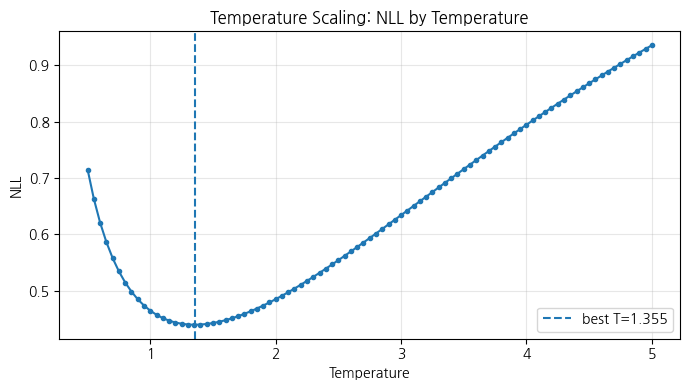

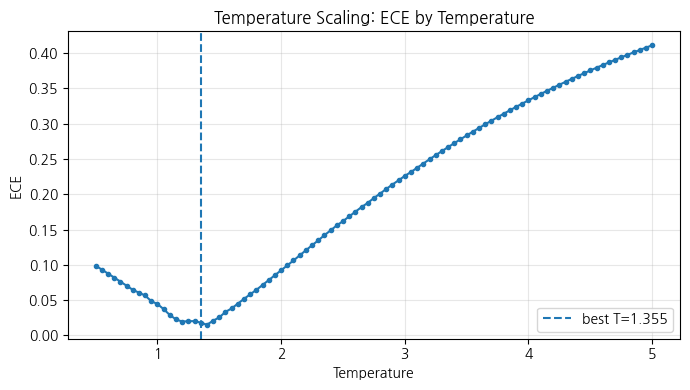

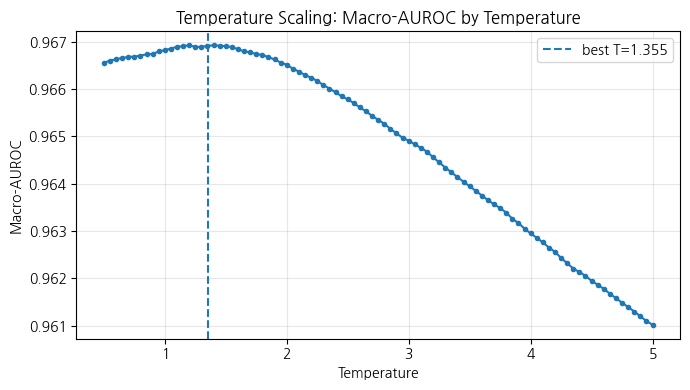

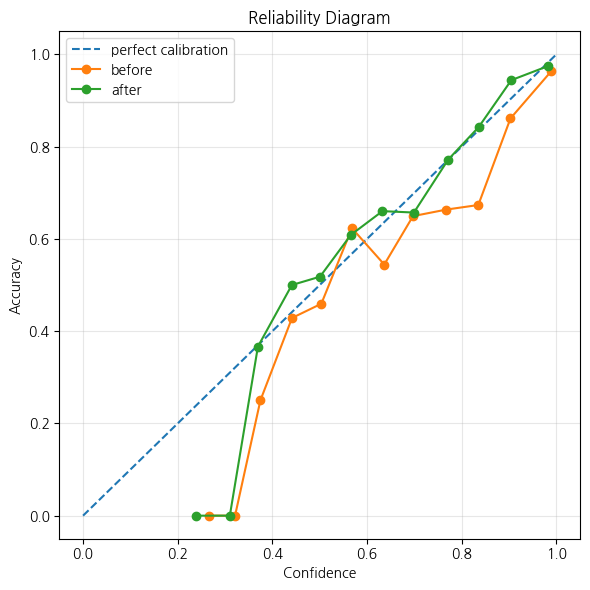

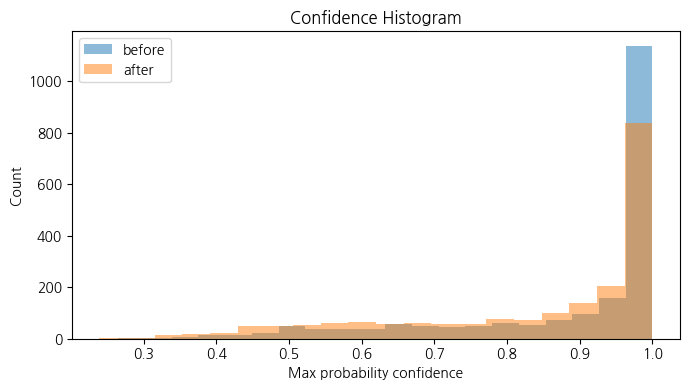

Temperature Scaling 최종 결과
Optimal Temperature : 1.3547
NLL      : 0.464353 -> 0.439376
ECE      : 0.044550 -> 0.019226
Accuracy : 0.8482 -> 0.8482
AUROC    : 0.966819 -> 0.966914


In [54]:
# =========================================================
# Temperature Scaling for ConvNeXt model_C
# 목적:
# - model_C의 logits를 temperature로 보정
# - Before / After calibration 비교
# - Macro-AUROC, class-wise AUROC, Accuracy, NLL, ECE 확인
# =========================================================

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    log_loss,
)
import matplotlib.pyplot as plt


# ---------------------------------------------------------
# 0. loader 준비
# ---------------------------------------------------------

if "safe_val_loader" in globals():
    temp_loader = safe_val_loader
elif "val_loader" in globals():
    temp_loader = DataLoader(
        val_loader.dataset,
        batch_size=32,
        shuffle=False,
        num_workers=0,
        pin_memory=False,
    )
else:
    raise RuntimeError("safe_val_loader 또는 val_loader가 필요합니다.")

if "model_C" not in globals():
    raise RuntimeError("model_C가 필요합니다.")


# ---------------------------------------------------------
# 1. logits 수집
# ---------------------------------------------------------

def collect_logits_and_labels(model, loader):
    model.eval()

    logits_list = []
    ys_list = []

    with torch.no_grad():
        for x, y in tqdm(loader, desc="collect logits", leave=False):
            x = x.to(device)
            logits = model(x)

            logits_list.append(logits.detach().cpu())
            ys_list.append(y.detach().cpu())

    logits = torch.cat(logits_list, dim=0)
    ys = torch.cat(ys_list, dim=0)

    return logits, ys


logits_cpu, ys_cpu = collect_logits_and_labels(model_C, temp_loader)

logits = logits_cpu.to(device)
ys = ys_cpu.to(device)

ys_np = ys_cpu.numpy()


# ---------------------------------------------------------
# 2. ECE 계산 함수
# ---------------------------------------------------------

def compute_ece(probs, labels, n_bins=15):
    confidences = probs.max(axis=1)
    predictions = probs.argmax(axis=1)
    accuracies = (predictions == labels)

    bin_boundaries = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0

    rows = []

    for i in range(n_bins):
        bin_lower = bin_boundaries[i]
        bin_upper = bin_boundaries[i + 1]

        in_bin = (confidences > bin_lower) & (confidences <= bin_upper)
        prop_in_bin = in_bin.mean()

        if prop_in_bin > 0:
            acc_in_bin = accuracies[in_bin].mean()
            conf_in_bin = confidences[in_bin].mean()
            ece += np.abs(acc_in_bin - conf_in_bin) * prop_in_bin

            rows.append({
                "bin_lower": bin_lower,
                "bin_upper": bin_upper,
                "count": int(in_bin.sum()),
                "accuracy": acc_in_bin,
                "confidence": conf_in_bin,
                "gap": abs(acc_in_bin - conf_in_bin),
            })

    return ece, pd.DataFrame(rows)


def softmax_np(x):
    x = x - x.max(axis=1, keepdims=True)
    exp_x = np.exp(x)
    return exp_x / exp_x.sum(axis=1, keepdims=True)


# ---------------------------------------------------------
# 3. Temperature Scaling 모듈
# ---------------------------------------------------------

class ModelWithTemperature(nn.Module):
    def __init__(self):
        super().__init__()
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def temperature_scale(self, logits):
        temperature = self.temperature.clamp(min=1e-4)
        return logits / temperature

    def forward(self, logits):
        return self.temperature_scale(logits)


temp_model = ModelWithTemperature().to(device)

criterion_nll = nn.CrossEntropyLoss()

before_nll = criterion_nll(logits, ys).item()

optimizer = torch.optim.LBFGS(
    [temp_model.temperature],
    lr=0.01,
    max_iter=100,
    line_search_fn="strong_wolfe",
)

def eval_loss():
    optimizer.zero_grad()
    scaled_logits = temp_model(logits)
    loss = criterion_nll(scaled_logits, ys)
    loss.backward()
    return loss

optimizer.step(eval_loss)

best_temperature = temp_model.temperature.detach().cpu().item()

with torch.no_grad():
    scaled_logits = temp_model(logits)
    after_nll = criterion_nll(scaled_logits, ys).item()


# ---------------------------------------------------------
# 4. Before / After 확률 계산
# ---------------------------------------------------------

logits_np = logits_cpu.numpy()
scaled_logits_np = scaled_logits.detach().cpu().numpy()

probs_before = softmax_np(logits_np)
probs_after = softmax_np(scaled_logits_np)

preds_before = probs_before.argmax(axis=1)
preds_after = probs_after.argmax(axis=1)


# ---------------------------------------------------------
# 5. 평가 함수
# ---------------------------------------------------------

def evaluate_calibration_result(ys, probs, preds, title):
    acc = accuracy_score(ys, preds)

    macro_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average="macro",
    )

    per_auc = roc_auc_score(
        ys,
        probs,
        multi_class="ovr",
        average=None,
    )

    nll = log_loss(
        ys,
        probs,
        labels=np.arange(len(CLASSES)),
    )

    ece, ece_table = compute_ece(
        probs,
        ys,
        n_bins=15,
    )

    report = classification_report(
        ys,
        preds,
        target_names=CLASSES,
        output_dict=True,
        zero_division=0,
    )

    print("=" * 90)
    print(title)
    print(f"accuracy    : {acc:.4f}")
    print(f"macro-AUROC : {macro_auc:.6f}")
    print(f"NLL         : {nll:.6f}")
    print(f"ECE         : {ece:.6f}")

    print("\nclass-wise AUROC")
    for c, v in zip(CLASSES, per_auc):
        print(f"{c:6s}: {v:.6f}")

    print("\nclassification report")
    print(classification_report(
        ys,
        preds,
        target_names=CLASSES,
        digits=3,
        zero_division=0,
    ))

    return {
        "accuracy": acc,
        "macro_auroc": macro_auc,
        "per_class_auroc": dict(zip(CLASSES, per_auc)),
        "nll": nll,
        "ece": ece,
        "ece_table": ece_table,
        "report": report,
    }


before_result = evaluate_calibration_result(
    ys_np,
    probs_before,
    preds_before,
    title="Before Temperature Scaling",
)

after_result = evaluate_calibration_result(
    ys_np,
    probs_after,
    preds_after,
    title=f"After Temperature Scaling T={best_temperature:.4f}",
)


# ---------------------------------------------------------
# 6. 요약표
# ---------------------------------------------------------

summary_df = pd.DataFrame([
    {
        "setting": "before",
        "temperature": 1.0,
        "accuracy": before_result["accuracy"],
        "macro_auroc": before_result["macro_auroc"],
        "nll": before_result["nll"],
        "ece": before_result["ece"],
    },
    {
        "setting": "after",
        "temperature": best_temperature,
        "accuracy": after_result["accuracy"],
        "macro_auroc": after_result["macro_auroc"],
        "nll": after_result["nll"],
        "ece": after_result["ece"],
    }
])

print("\nTemperature Scaling Summary")
display(summary_df)

class_auc_rows = []

for c in CLASSES:
    class_auc_rows.append({
        "class": c,
        "before_auc": before_result["per_class_auroc"][c],
        "after_auc": after_result["per_class_auroc"][c],
        "delta_auc": after_result["per_class_auroc"][c] - before_result["per_class_auroc"][c],
    })

class_auc_df = pd.DataFrame(class_auc_rows).sort_values(
    "delta_auc",
    ascending=False,
)

print("\nClass-wise AUROC change")
display(class_auc_df)


# ---------------------------------------------------------
# 7. Temperature sweep
# ---------------------------------------------------------

sweep_rows = []

for T in np.arange(0.5, 5.05, 0.05):
    scaled = logits_np / T
    p = softmax_np(scaled)
    pred = p.argmax(axis=1)

    macro_auc = roc_auc_score(
        ys_np,
        p,
        multi_class="ovr",
        average="macro",
    )

    nll = log_loss(
        ys_np,
        p,
        labels=np.arange(len(CLASSES)),
    )

    ece, _ = compute_ece(p, ys_np, n_bins=15)

    sweep_rows.append({
        "temperature": round(float(T), 2),
        "accuracy": accuracy_score(ys_np, pred),
        "macro_auroc": macro_auc,
        "nll": nll,
        "ece": ece,
    })

temperature_sweep_df = pd.DataFrame(sweep_rows)

print("\nTemperature sweep 결과")
display(
    temperature_sweep_df.sort_values("nll", ascending=True).head(20)
)


# ---------------------------------------------------------
# 8. 시각화
# ---------------------------------------------------------

plot_df = temperature_sweep_df.sort_values("temperature")

plt.figure(figsize=(7, 4))
plt.plot(plot_df["temperature"], plot_df["nll"], marker="o", markersize=3)
plt.axvline(best_temperature, linestyle="--", label=f"best T={best_temperature:.3f}")
plt.xlabel("Temperature")
plt.ylabel("NLL")
plt.title("Temperature Scaling: NLL by Temperature")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(plot_df["temperature"], plot_df["ece"], marker="o", markersize=3)
plt.axvline(best_temperature, linestyle="--", label=f"best T={best_temperature:.3f}")
plt.xlabel("Temperature")
plt.ylabel("ECE")
plt.title("Temperature Scaling: ECE by Temperature")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(plot_df["temperature"], plot_df["macro_auroc"], marker="o", markersize=3)
plt.axvline(best_temperature, linestyle="--", label=f"best T={best_temperature:.3f}")
plt.xlabel("Temperature")
plt.ylabel("Macro-AUROC")
plt.title("Temperature Scaling: Macro-AUROC by Temperature")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 9. Reliability Diagram
# ---------------------------------------------------------

before_ece_table = before_result["ece_table"]
after_ece_table = after_result["ece_table"]

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], linestyle="--", label="perfect calibration")

if len(before_ece_table) > 0:
    plt.plot(
        before_ece_table["confidence"],
        before_ece_table["accuracy"],
        marker="o",
        label="before",
    )

if len(after_ece_table) > 0:
    plt.plot(
        after_ece_table["confidence"],
        after_ece_table["accuracy"],
        marker="o",
        label="after",
    )

plt.xlabel("Confidence")
plt.ylabel("Accuracy")
plt.title("Reliability Diagram")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 10. Confidence Histogram
# ---------------------------------------------------------

conf_before = probs_before.max(axis=1)
conf_after = probs_after.max(axis=1)

plt.figure(figsize=(7, 4))
plt.hist(conf_before, bins=20, alpha=0.5, label="before")
plt.hist(conf_after, bins=20, alpha=0.5, label="after")
plt.xlabel("Max probability confidence")
plt.ylabel("Count")
plt.title("Confidence Histogram")
plt.legend()
plt.tight_layout()
plt.show()


# ---------------------------------------------------------
# 11. 최종 해석 보조 출력
# ---------------------------------------------------------

print("=" * 90)
print("Temperature Scaling 최종 결과")
print(f"Optimal Temperature : {best_temperature:.4f}")
print(f"NLL      : {before_result['nll']:.6f} -> {after_result['nll']:.6f}")
print(f"ECE      : {before_result['ece']:.6f} -> {after_result['ece']:.6f}")
print(f"Accuracy : {before_result['accuracy']:.4f} -> {after_result['accuracy']:.4f}")
print(f"AUROC    : {before_result['macro_auroc']:.6f} -> {after_result['macro_auroc']:.6f}")
print("=" * 90)

### 17. HAM10000 ConvNeXt + Clinical Metadata Multimodal Experiment

In [11]:
# ============================================================
# HAM10000 ConvNeXt + Clinical Metadata Multimodal Experiment
# Image feature + Age/Sex/Localization metadata
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights


# -----------------------------
# 1. Config
# -----------------------------
SEED = 42
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 5
LR = 1e-4
NUM_CLASSES = 7
DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
META_CSV = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)


# -----------------------------
# 2. Load metadata
# -----------------------------
df = pd.read_csv(META_CSV)

label_map = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "df": 3,
    "mel": 4,
    "nv": 5,
    "vasc": 6,
}
idx_to_label = {v: k for k, v in label_map.items()}

df["label"] = df["dx"].map(label_map)

# age missing 처리
df["age"] = df["age"].fillna(df["age"].median())

# sex/localization missing 처리
df["sex"] = df["sex"].fillna("unknown")
df["localization"] = df["localization"].fillna("unknown")


# -----------------------------
# 3. Image path mapping
# -----------------------------
image_dirs = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2"),
]

image_path_map = {}
for img_dir in image_dirs:
    for fname in os.listdir(img_dir):
        if fname.endswith(".jpg"):
            image_id = fname.replace(".jpg", "")
            image_path_map[image_id] = os.path.join(img_dir, fname)

df["image_path"] = df["image_id"].map(image_path_map)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Data size:", len(df))
print(df["dx"].value_counts())


# -----------------------------
# 4. Train/Valid split
# -----------------------------
train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("Train:", len(train_df), "Valid:", len(valid_df))


# -----------------------------
# 5. Metadata preprocessing
# -----------------------------
meta_cols_num = ["age"]
meta_cols_cat = ["sex", "localization"]

meta_preprocessor = ColumnTransformer(
    transformers=[
        ("age", StandardScaler(), meta_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), meta_cols_cat),
    ]
)

train_meta = meta_preprocessor.fit_transform(train_df)
valid_meta = meta_preprocessor.transform(valid_df)

# sparse matrix일 경우 dense로 변환
if hasattr(train_meta, "toarray"):
    train_meta = train_meta.toarray()
    valid_meta = valid_meta.toarray()

train_meta = train_meta.astype(np.float32)
valid_meta = valid_meta.astype(np.float32)

META_DIM = train_meta.shape[1]
print("Metadata feature dim:", META_DIM)


# -----------------------------
# 6. Dataset
# -----------------------------
class HAM10000MultimodalDataset(Dataset):
    def __init__(self, df, meta_features, transform=None):
        self.df = df
        self.meta_features = meta_features
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        meta = torch.tensor(self.meta_features[idx], dtype=torch.float32)
        label = torch.tensor(row["label"], dtype=torch.long)

        return image, meta, label


train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

valid_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),
])

train_ds = HAM10000MultimodalDataset(train_df, train_meta, train_tfms)
valid_ds = HAM10000MultimodalDataset(valid_df, valid_meta, valid_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


# -----------------------------
# 7. Multimodal ConvNeXt model
# -----------------------------
class ConvNeXtMetadataModel(nn.Module):
    def __init__(self, meta_dim, num_classes=7, freeze_backbone=False):
        super().__init__()

        try:
            weights = ConvNeXt_Tiny_Weights.DEFAULT
            self.backbone = convnext_tiny(weights=weights)
            print("Loaded ImageNet pretrained ConvNeXt-Tiny")
        except Exception as e:
            print("Pretrained weights load failed. Using random init.")
            print(e)
            self.backbone = convnext_tiny(weights=None)

        image_feat_dim = self.backbone.classifier[2].in_features

        # 핵심 수정:
        # classifier 전체를 Identity로 바꾸면 [B, 768, 1, 1]이 나옴.
        # 마지막 Linear만 제거하면 ConvNeXt 내부 flatten까지 유지되어 [B, 768]이 나옴.
        self.backbone.classifier[2] = nn.Identity()

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(image_feat_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, image, meta):
        image_feat = self.backbone(image)      # [B, 768]
        meta_feat = self.meta_mlp(meta)        # [B, 64]

        feat = torch.cat([image_feat, meta_feat], dim=1)  # [B, 832]
        logits = self.classifier(feat)                    # [B, 7]

        return logits


model = ConvNeXtMetadataModel(
    meta_dim=META_DIM,
    num_classes=NUM_CLASSES,
    freeze_backbone=False
).to(DEVICE)


# -----------------------------
# 8. Loss / Optimizer
# -----------------------------
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS
)


# -----------------------------
# 9. Train / Validate functions
# -----------------------------
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for images, metas, labels in loader:
        images = images.to(DEVICE)
        metas = metas.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images, metas)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


@torch.no_grad()
def validate(model, loader):
    model.eval()

    total_loss = 0
    all_probs = []
    all_preds = []
    all_labels = []

    for images, metas, labels in loader:
        images = images.to(DEVICE)
        metas = metas.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images, metas)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)

        total_loss += loss.item() * images.size(0)

        all_probs.append(probs.cpu().numpy())
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels_np = np.array(all_labels)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    try:
        macro_auroc = roc_auc_score(
            all_labels_np,
            all_probs,
            multi_class="ovr",
            average="macro"
        )
    except Exception as e:
        macro_auroc = np.nan
        print("AUROC calculation failed:", e)

    return avg_loss, acc, macro_auroc, all_labels, all_preds, all_probs


# -----------------------------
# 10. Training loop
# -----------------------------
best_auroc = -1
best_path = "convnext_metadata_multimodal_best.pth"

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)
    valid_loss, valid_acc, valid_auroc, y_true, y_pred, y_prob = validate(model, valid_loader)

    scheduler.step()

    print(
        f"[Epoch {epoch:02d}] "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"valid_loss={valid_loss:.4f} valid_acc={valid_acc:.4f} "
        f"valid_macro_AUROC={valid_auroc:.6f}"
    )

    if valid_auroc > best_auroc:
        best_auroc = valid_auroc
        torch.save(model.state_dict(), best_path)
        print(f"  -> saved best model: {best_path}")


# -----------------------------
# 11. Final report
# -----------------------------
print("\nBest valid Macro-AUROC:", best_auroc)

print("\nClassification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[idx_to_label[i] for i in range(NUM_CLASSES)],
        digits=4
    )
)

# 클래스별 AUROC
print("\nClass-wise AUROC:")
for i in range(NUM_CLASSES):
    binary_true = (np.array(y_true) == i).astype(int)
    class_prob = y_prob[:, i]

    try:
        auc = roc_auc_score(binary_true, class_prob)
        print(f"{idx_to_label[i]:5s}: {auc:.6f}")
    except Exception as e:
        print(f"{idx_to_label[i]:5s}: AUROC failed ({e})")

DEVICE: cuda
Data size: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
Train: 8012 Valid: 2003
Metadata feature dim: 19
Loaded ImageNet pretrained ConvNeXt-Tiny
[Epoch 01] train_loss=0.7240 train_acc=0.7500 | valid_loss=0.4857 valid_acc=0.8318 valid_macro_AUROC=0.962214
  -> saved best model: convnext_metadata_multimodal_best.pth
[Epoch 02] train_loss=0.4269 train_acc=0.8459 | valid_loss=0.3782 valid_acc=0.8672 valid_macro_AUROC=0.978402
  -> saved best model: convnext_metadata_multimodal_best.pth
[Epoch 03] train_loss=0.2948 train_acc=0.8933 | valid_loss=0.3127 valid_acc=0.8937 valid_macro_AUROC=0.984793
  -> saved best model: convnext_metadata_multimodal_best.pth
[Epoch 04] train_loss=0.1883 train_acc=0.9365 | valid_loss=0.2929 valid_acc=0.9006 valid_macro_AUROC=0.987500
  -> saved best model: convnext_metadata_multimodal_best.pth
[Epoch 05] train_loss=0.1316 train_acc=0.9571 | valid_loss=0.2605 val

### 18. Cost-Sensitive Learning Experiment(ConvNeXt + Metadata )

In [12]:
# ============================================================
# HAM10000 ConvNeXt + Metadata
# Cost-Sensitive Learning Experiment
# Focus: penalize melanoma false negative, especially mel -> nv
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights


# -----------------------------
# 1. Config
# -----------------------------
SEED = 42
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS = 5
LR = 1e-4
NUM_CLASSES = 7

# Cost-sensitive strength
MEL_FN_COST = 3.0
MEL_TO_NV_COST = 5.0
COST_LAMBDA = 0.5

DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
META_CSV = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)


# -----------------------------
# 2. Load metadata
# -----------------------------
df = pd.read_csv(META_CSV)

label_map = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "df": 3,
    "mel": 4,
    "nv": 5,
    "vasc": 6,
}
idx_to_label = {v: k for k, v in label_map.items()}

MEL_IDX = label_map["mel"]
NV_IDX = label_map["nv"]

df["label"] = df["dx"].map(label_map)

df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna("unknown")
df["localization"] = df["localization"].fillna("unknown")


# -----------------------------
# 3. Image path mapping
# -----------------------------
image_dirs = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2"),
]

image_path_map = {}
for img_dir in image_dirs:
    for fname in os.listdir(img_dir):
        if fname.endswith(".jpg"):
            image_id = fname.replace(".jpg", "")
            image_path_map[image_id] = os.path.join(img_dir, fname)

df["image_path"] = df["image_id"].map(image_path_map)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Data size:", len(df))
print(df["dx"].value_counts())


# -----------------------------
# 4. Train/Valid split
# -----------------------------
train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("Train:", len(train_df), "Valid:", len(valid_df))


# -----------------------------
# 5. Metadata preprocessing
# -----------------------------
meta_cols_num = ["age"]
meta_cols_cat = ["sex", "localization"]

meta_preprocessor = ColumnTransformer(
    transformers=[
        ("age", StandardScaler(), meta_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), meta_cols_cat),
    ]
)

train_meta = meta_preprocessor.fit_transform(train_df)
valid_meta = meta_preprocessor.transform(valid_df)

if hasattr(train_meta, "toarray"):
    train_meta = train_meta.toarray()
    valid_meta = valid_meta.toarray()

train_meta = train_meta.astype(np.float32)
valid_meta = valid_meta.astype(np.float32)

META_DIM = train_meta.shape[1]
print("Metadata feature dim:", META_DIM)


# -----------------------------
# 6. Dataset
# -----------------------------
class HAM10000MultimodalDataset(Dataset):
    def __init__(self, df, meta_features, transform=None):
        self.df = df
        self.meta_features = meta_features
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")
        if self.transform:
            image = self.transform(image)

        meta = torch.tensor(self.meta_features[idx], dtype=torch.float32)
        label = torch.tensor(row["label"], dtype=torch.long)

        return image, meta, label


train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

valid_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_ds = HAM10000MultimodalDataset(train_df, train_meta, train_tfms)
valid_ds = HAM10000MultimodalDataset(valid_df, valid_meta, valid_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


# -----------------------------
# 7. Model
# -----------------------------
class ConvNeXtMetadataModel(nn.Module):
    def __init__(self, meta_dim, num_classes=7, freeze_backbone=False):
        super().__init__()

        try:
            weights = ConvNeXt_Tiny_Weights.DEFAULT
            self.backbone = convnext_tiny(weights=weights)
            print("Loaded ImageNet pretrained ConvNeXt-Tiny")
        except Exception as e:
            print("Pretrained weights load failed. Using random init.")
            print(e)
            self.backbone = convnext_tiny(weights=None)

        image_feat_dim = self.backbone.classifier[2].in_features

        # Keep ConvNeXt internal flatten, remove only final Linear
        self.backbone.classifier[2] = nn.Identity()

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(image_feat_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, image, meta):
        image_feat = self.backbone(image)      # [B, 768]
        meta_feat = self.meta_mlp(meta)        # [B, 64]
        feat = torch.cat([image_feat, meta_feat], dim=1)
        logits = self.classifier(feat)
        return logits


model = ConvNeXtMetadataModel(
    meta_dim=META_DIM,
    num_classes=NUM_CLASSES,
    freeze_backbone=False,
).to(DEVICE)


# -----------------------------
# 8. Cost Matrix + Custom Loss
# -----------------------------
def build_cost_matrix(num_classes, mel_idx, nv_idx, mel_fn_cost=3.0, mel_to_nv_cost=5.0):
    """
    cost_matrix[true_class, predicted_class]
    정답이 mel인데 다른 클래스로 갈 확률에 비용을 부여.
    특히 mel -> nv 비용을 가장 크게 설정.
    """
    cost = torch.ones(num_classes, num_classes)

    # 정답을 맞춘 경우 비용 0
    cost.fill_diagonal_(0.0)

    # melanoma false negative 전체 비용 증가
    cost[mel_idx, :] = mel_fn_cost
    cost[mel_idx, mel_idx] = 0.0

    # melanoma를 nv로 보는 오류를 가장 크게
    cost[mel_idx, nv_idx] = mel_to_nv_cost

    return cost


class CostSensitiveCrossEntropy(nn.Module):
    def __init__(self, cost_matrix, lambda_cost=0.5):
        super().__init__()
        self.register_buffer("cost_matrix", cost_matrix)
        self.lambda_cost = lambda_cost
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        """
        CE + expected misclassification cost

        CE:
          일반적인 정답 class 학습

        expected_cost:
          모델이 각 class로 예측할 확률 * 오진 비용
          정답이 mel일 때 nv/기타 class 확률이 높으면 loss 증가
        """
        ce_loss = self.ce(logits, targets)

        probs = torch.softmax(logits, dim=1)                 # [B, C]
        sample_cost = self.cost_matrix[targets]              # [B, C]
        expected_cost = (probs * sample_cost).sum(dim=1)     # [B]
        cost_loss = expected_cost.mean()

        total_loss = ce_loss + self.lambda_cost * cost_loss

        return total_loss


cost_matrix = build_cost_matrix(
    num_classes=NUM_CLASSES,
    mel_idx=MEL_IDX,
    nv_idx=NV_IDX,
    mel_fn_cost=MEL_FN_COST,
    mel_to_nv_cost=MEL_TO_NV_COST,
).to(DEVICE)

print("Cost matrix:")
print(pd.DataFrame(
    cost_matrix.detach().cpu().numpy(),
    index=[idx_to_label[i] for i in range(NUM_CLASSES)],
    columns=[idx_to_label[i] for i in range(NUM_CLASSES)],
))

criterion = CostSensitiveCrossEntropy(
    cost_matrix=cost_matrix,
    lambda_cost=COST_LAMBDA,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)


# -----------------------------
# 9. Train / Validate
# -----------------------------
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for images, metas, labels in loader:
        images = images.to(DEVICE)
        metas = metas.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()

        logits = model(images, metas)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


@torch.no_grad()
def validate(model, loader):
    model.eval()

    total_loss = 0
    all_probs = []
    all_preds = []
    all_labels = []

    for images, metas, labels in loader:
        images = images.to(DEVICE)
        metas = metas.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images, metas)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)

        total_loss += loss.item() * images.size(0)

        all_probs.append(probs.cpu().numpy())
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels_np = np.array(all_labels)
    all_preds_np = np.array(all_preds)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels_np, all_preds_np)

    try:
        macro_auroc = roc_auc_score(
            all_labels_np,
            all_probs,
            multi_class="ovr",
            average="macro",
        )
    except Exception as e:
        macro_auroc = np.nan
        print("AUROC calculation failed:", e)

    return avg_loss, acc, macro_auroc, all_labels_np, all_preds_np, all_probs


def get_mel_metrics(y_true, y_pred, y_prob):
    report = classification_report(
        y_true,
        y_pred,
        target_names=[idx_to_label[i] for i in range(NUM_CLASSES)],
        output_dict=True,
        zero_division=0,
    )

    mel_precision = report["mel"]["precision"]
    mel_recall = report["mel"]["recall"]
    mel_f1 = report["mel"]["f1-score"]

    mel_true = (y_true == MEL_IDX).astype(int)
    mel_prob = y_prob[:, MEL_IDX]

    try:
        mel_auc = roc_auc_score(mel_true, mel_prob)
    except Exception:
        mel_auc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    mel_fn_total = cm[MEL_IDX, :].sum() - cm[MEL_IDX, MEL_IDX]
    mel_to_nv = cm[MEL_IDX, NV_IDX]

    return {
        "mel_precision": mel_precision,
        "mel_recall": mel_recall,
        "mel_f1": mel_f1,
        "mel_auc": mel_auc,
        "mel_fn_total": mel_fn_total,
        "mel_to_nv": mel_to_nv,
    }


# -----------------------------
# 10. Training loop
# -----------------------------
best_score = -1
best_path = "convnext_metadata_cost_sensitive_best.pth"
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)

    valid_loss, valid_acc, valid_auroc, y_true, y_pred, y_prob = validate(
        model,
        valid_loader,
    )

    scheduler.step()

    mel_metrics = get_mel_metrics(y_true, y_pred, y_prob)

    # screening 목적이므로 Macro-AUROC + mel recall을 같이 고려
    selection_score = valid_auroc + 0.1 * mel_metrics["mel_recall"]

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "valid_macro_auroc": valid_auroc,
        **mel_metrics,
        "selection_score": selection_score,
    }
    history.append(row)

    print(
        f"[Epoch {epoch:02d}] "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"valid_loss={valid_loss:.4f} valid_acc={valid_acc:.4f} "
        f"macro_AUROC={valid_auroc:.6f} | "
        f"mel_P={mel_metrics['mel_precision']:.4f} "
        f"mel_R={mel_metrics['mel_recall']:.4f} "
        f"mel_F1={mel_metrics['mel_f1']:.4f} "
        f"mel_AUROC={mel_metrics['mel_auc']:.6f} "
        f"mel_FN={mel_metrics['mel_fn_total']} "
        f"mel_to_nv={mel_metrics['mel_to_nv']}"
    )

    if selection_score > best_score:
        best_score = selection_score
        torch.save(model.state_dict(), best_path)
        print(f"  -> saved best model: {best_path}")


# -----------------------------
# 11. Final report
# -----------------------------
history_df = pd.DataFrame(history)
display(history_df)

best_epoch = history_df.sort_values("selection_score", ascending=False).iloc[0]

print("\nBest epoch by Macro-AUROC + 0.1 * mel recall:")
print(best_epoch)

print("\nFinal Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[idx_to_label[i] for i in range(NUM_CLASSES)],
        digits=4,
        zero_division=0,
    )
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{idx_to_label[i]}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{idx_to_label[i]}" for i in range(NUM_CLASSES)],
)
display(cm_df)

print("\nClass-wise AUROC:")
for i in range(NUM_CLASSES):
    binary_true = (y_true == i).astype(int)
    class_prob = y_prob[:, i]

    try:
        auc = roc_auc_score(binary_true, class_prob)
        print(f"{idx_to_label[i]:5s}: {auc:.6f}")
    except Exception as e:
        print(f"{idx_to_label[i]:5s}: AUROC failed ({e})")

DEVICE: cuda
Data size: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
Train: 8012 Valid: 2003
Metadata feature dim: 19
Loaded ImageNet pretrained ConvNeXt-Tiny
Cost matrix:
       akiec  bcc  bkl   df  mel   nv  vasc
akiec    0.0  1.0  1.0  1.0  1.0  1.0   1.0
bcc      1.0  0.0  1.0  1.0  1.0  1.0   1.0
bkl      1.0  1.0  0.0  1.0  1.0  1.0   1.0
df       1.0  1.0  1.0  0.0  1.0  1.0   1.0
mel      3.0  3.0  3.0  3.0  0.0  5.0   3.0
nv       1.0  1.0  1.0  1.0  1.0  0.0   1.0
vasc     1.0  1.0  1.0  1.0  1.0  1.0   0.0
[Epoch 01] train_loss=1.0256 train_acc=0.7436 | valid_loss=0.7061 valid_acc=0.8138 macro_AUROC=0.961993 | mel_P=0.4758 mel_R=0.7489 mel_F1=0.5819 mel_AUROC=0.914030 mel_FN=56 mel_to_nv=33
  -> saved best model: convnext_metadata_cost_sensitive_best.pth
[Epoch 02] train_loss=0.6243 train_acc=0.8422 | valid_loss=0.5561 valid_acc=0.8727 macro_AUROC=0.978488 | mel_P=0.6955 mel_R=0.6861 mel

,epoch,train_loss,train_acc,valid_loss,valid_acc,valid_macro_auroc,mel_precision,mel_recall,mel_f1,mel_auc,mel_fn_total,mel_to_nv,selection_score
0,1,1.025637,0.743635,0.706070,0.813779,0.961993,0.475783,0.748879,0.581882,0.914030,56,33,1.036881
1,2,0.624287,0.842237,0.556127,0.872691,0.978488,0.695455,0.686099,0.690745,0.948818,70,56,1.047097
2,3,0.438667,0.893909,0.465592,0.879680,0.984149,0.704641,0.748879,0.726087,0.959540,56,33,1.059037
3,4,0.276315,0.933724,0.403682,0.907639,0.987428,0.816327,0.717489,0.763723,0.965594,63,47,1.059177
4,5,0.198756,0.954194,0.374999,0.915127,0.988742,0.757202,0.825112,0.789700,0.970157,39,26,1.071253



Best epoch by Macro-AUROC + 0.1 * mel recall:
epoch                 5.000000
train_loss            0.198756
train_acc             0.954194
valid_loss            0.374999
valid_acc             0.915127
valid_macro_auroc     0.988742
mel_precision         0.757202
mel_recall            0.825112
mel_f1                0.789700
mel_auc               0.970157
mel_fn_total         39.000000
mel_to_nv            26.000000
selection_score       1.071253
Name: 4, dtype: float64

Final Classification Report:
              precision    recall  f1-score   support

       akiec     0.7143    0.8462    0.7746        65
         bcc     0.8812    0.8641    0.8725       103
         bkl     0.8821    0.7818    0.8289       220
          df     0.8696    0.8696    0.8696        23
         mel     0.7572    0.8251    0.7897       223
          nv     0.9641    0.9605    0.9623      1341
        vasc     0.8929    0.8929    0.8929        28

    accuracy                         0.9151      2003
   macro

,pred_akiec,pred_bcc,pred_bkl,pred_df,pred_mel,pred_nv,pred_vasc
true_akiec,55,3,1,0,6,0,0
true_bcc,3,89,4,1,2,3,1
true_bkl,13,6,172,0,12,17,0
true_df,1,0,0,20,1,1,0
true_mel,2,0,10,1,184,26,0
true_nv,3,2,8,1,37,1288,2
true_vasc,0,1,0,0,1,1,25



Class-wise AUROC:
akiec: 0.995054
bcc  : 0.995294
bkl  : 0.980207
df   : 0.997211
mel  : 0.970157
nv   : 0.983829
vasc : 0.999439


### 18-2. Cost-Sensitive Learning Experimentpenalize(2-GPU사용만 다르며, 18번 실험과 중복된 내용)

In [13]:
# ============================================================
# HAM10000 ConvNeXt + Metadata
# Cost-Sensitive Learning Experiment
# Multi-GPU version for Kaggle T4 x2
# Focus: penalize melanoma false negative, especially mel -> nv
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights


# -----------------------------
# 1. Config
# -----------------------------
SEED = 42

# T4 x2에서는 64부터 시도
# OOM 발생 시 32로 낮추기
BATCH_SIZE = 64

IMG_SIZE = 224
EPOCHS = 5
LR = 1e-4
NUM_CLASSES = 7

# Cost-sensitive strength
MEL_FN_COST = 3.0
MEL_TO_NV_COST = 5.0
COST_LAMBDA = 0.5

DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
META_CSV = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)
print("CUDA available:", torch.cuda.is_available())
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))


# -----------------------------
# 2. Load metadata
# -----------------------------
df = pd.read_csv(META_CSV)

label_map = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "df": 3,
    "mel": 4,
    "nv": 5,
    "vasc": 6,
}
idx_to_label = {v: k for k, v in label_map.items()}

MEL_IDX = label_map["mel"]
NV_IDX = label_map["nv"]

df["label"] = df["dx"].map(label_map)

df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna("unknown")
df["localization"] = df["localization"].fillna("unknown")


# -----------------------------
# 3. Image path mapping
# -----------------------------
image_dirs = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2"),
]

image_path_map = {}
for img_dir in image_dirs:
    for fname in os.listdir(img_dir):
        if fname.endswith(".jpg"):
            image_id = fname.replace(".jpg", "")
            image_path_map[image_id] = os.path.join(img_dir, fname)

df["image_path"] = df["image_id"].map(image_path_map)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Data size:", len(df))
print(df["dx"].value_counts())


# -----------------------------
# 4. Train/Valid split
# -----------------------------
train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"],
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("Train:", len(train_df), "Valid:", len(valid_df))


# -----------------------------
# 5. Metadata preprocessing
# -----------------------------
meta_cols_num = ["age"]
meta_cols_cat = ["sex", "localization"]

meta_preprocessor = ColumnTransformer(
    transformers=[
        ("age", StandardScaler(), meta_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), meta_cols_cat),
    ]
)

train_meta = meta_preprocessor.fit_transform(train_df)
valid_meta = meta_preprocessor.transform(valid_df)

if hasattr(train_meta, "toarray"):
    train_meta = train_meta.toarray()
    valid_meta = valid_meta.toarray()

train_meta = train_meta.astype(np.float32)
valid_meta = valid_meta.astype(np.float32)

META_DIM = train_meta.shape[1]
print("Metadata feature dim:", META_DIM)


# -----------------------------
# 6. Dataset
# -----------------------------
class HAM10000MultimodalDataset(Dataset):
    def __init__(self, df, meta_features, transform=None):
        self.df = df
        self.meta_features = meta_features
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        meta = torch.tensor(self.meta_features[idx], dtype=torch.float32)
        label = torch.tensor(row["label"], dtype=torch.long)

        return image, meta, label


train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

valid_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_ds = HAM10000MultimodalDataset(train_df, train_meta, train_tfms)
valid_ds = HAM10000MultimodalDataset(valid_df, valid_meta, valid_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


# -----------------------------
# 7. Model
# -----------------------------
class ConvNeXtMetadataModel(nn.Module):
    def __init__(self, meta_dim, num_classes=7, freeze_backbone=False):
        super().__init__()

        try:
            weights = ConvNeXt_Tiny_Weights.DEFAULT
            self.backbone = convnext_tiny(weights=weights)
            print("Loaded ImageNet pretrained ConvNeXt-Tiny")
        except Exception as e:
            print("Pretrained weights load failed. Using random init.")
            print(e)
            self.backbone = convnext_tiny(weights=None)

        image_feat_dim = self.backbone.classifier[2].in_features

        # classifier 전체 제거 X
        # 마지막 Linear만 제거해야 ConvNeXt 내부 flatten이 유지되어 [B, 768] 출력
        self.backbone.classifier[2] = nn.Identity()

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(image_feat_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, image, meta):
        image_feat = self.backbone(image)      # [B, 768]
        meta_feat = self.meta_mlp(meta)        # [B, 64]
        feat = torch.cat([image_feat, meta_feat], dim=1)
        logits = self.classifier(feat)
        return logits


model = ConvNeXtMetadataModel(
    meta_dim=META_DIM,
    num_classes=NUM_CLASSES,
    freeze_backbone=False,
)

# Multi-GPU support
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs with DataParallel")
    model = nn.DataParallel(model)

model = model.to(DEVICE)


# -----------------------------
# 8. Cost Matrix + Custom Loss
# -----------------------------
def build_cost_matrix(num_classes, mel_idx, nv_idx, mel_fn_cost=3.0, mel_to_nv_cost=5.0):
    """
    cost_matrix[true_class, predicted_class]

    정답이 mel인데 다른 클래스로 예측하는 확률에 비용을 부여.
    특히 mel -> nv 오류를 가장 크게 설정.
    """
    cost = torch.ones(num_classes, num_classes)

    # 정답 class로 예측하는 경우 비용 0
    cost.fill_diagonal_(0.0)

    # melanoma false negative 전체 비용 증가
    cost[mel_idx, :] = mel_fn_cost
    cost[mel_idx, mel_idx] = 0.0

    # melanoma를 nv로 보는 오류를 가장 크게
    cost[mel_idx, nv_idx] = mel_to_nv_cost

    return cost


class CostSensitiveCrossEntropy(nn.Module):
    def __init__(self, cost_matrix, lambda_cost=0.5):
        super().__init__()
        self.register_buffer("cost_matrix", cost_matrix)
        self.lambda_cost = lambda_cost
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)

        probs = torch.softmax(logits, dim=1)                 # [B, C]
        sample_cost = self.cost_matrix[targets]              # [B, C]
        expected_cost = (probs * sample_cost).sum(dim=1)     # [B]
        cost_loss = expected_cost.mean()

        total_loss = ce_loss + self.lambda_cost * cost_loss

        return total_loss


cost_matrix = build_cost_matrix(
    num_classes=NUM_CLASSES,
    mel_idx=MEL_IDX,
    nv_idx=NV_IDX,
    mel_fn_cost=MEL_FN_COST,
    mel_to_nv_cost=MEL_TO_NV_COST,
).to(DEVICE)

print("Cost matrix:")
print(pd.DataFrame(
    cost_matrix.detach().cpu().numpy(),
    index=[idx_to_label[i] for i in range(NUM_CLASSES)],
    columns=[idx_to_label[i] for i in range(NUM_CLASSES)],
))

criterion = CostSensitiveCrossEntropy(
    cost_matrix=cost_matrix,
    lambda_cost=COST_LAMBDA,
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=1e-4,
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)


# -----------------------------
# 9. Train / Validate
# -----------------------------
def train_one_epoch(model, loader):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for images, metas, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        metas = metas.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images, metas)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


@torch.no_grad()
def validate(model, loader):
    model.eval()

    total_loss = 0
    all_probs = []
    all_preds = []
    all_labels = []

    for images, metas, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        metas = metas.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(images, metas)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)

        total_loss += loss.item() * images.size(0)

        all_probs.append(probs.cpu().numpy())
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels_np = np.array(all_labels)
    all_preds_np = np.array(all_preds)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels_np, all_preds_np)

    try:
        macro_auroc = roc_auc_score(
            all_labels_np,
            all_probs,
            multi_class="ovr",
            average="macro",
        )
    except Exception as e:
        macro_auroc = np.nan
        print("AUROC calculation failed:", e)

    return avg_loss, acc, macro_auroc, all_labels_np, all_preds_np, all_probs


def get_mel_metrics(y_true, y_pred, y_prob):
    report = classification_report(
        y_true,
        y_pred,
        target_names=[idx_to_label[i] for i in range(NUM_CLASSES)],
        output_dict=True,
        zero_division=0,
    )

    mel_precision = report["mel"]["precision"]
    mel_recall = report["mel"]["recall"]
    mel_f1 = report["mel"]["f1-score"]

    mel_true = (y_true == MEL_IDX).astype(int)
    mel_prob = y_prob[:, MEL_IDX]

    try:
        mel_auc = roc_auc_score(mel_true, mel_prob)
    except Exception:
        mel_auc = np.nan

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    mel_fn_total = cm[MEL_IDX, :].sum() - cm[MEL_IDX, MEL_IDX]
    mel_to_nv = cm[MEL_IDX, NV_IDX]

    return {
        "mel_precision": mel_precision,
        "mel_recall": mel_recall,
        "mel_f1": mel_f1,
        "mel_auc": mel_auc,
        "mel_fn_total": mel_fn_total,
        "mel_to_nv": mel_to_nv,
    }


def save_model_state(model, path):
    state_dict = model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict()
    torch.save(state_dict, path)


# -----------------------------
# 10. Training loop
# -----------------------------
best_score = -1
best_path = "convnext_metadata_cost_sensitive_best_multigpu.pth"
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader)

    valid_loss, valid_acc, valid_auroc, y_true, y_pred, y_prob = validate(
        model,
        valid_loader,
    )

    scheduler.step()

    mel_metrics = get_mel_metrics(y_true, y_pred, y_prob)

    # Screening 목적:
    # 전체 AUROC를 유지하면서 mel recall을 같이 고려
    selection_score = valid_auroc + 0.1 * mel_metrics["mel_recall"]

    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "valid_macro_auroc": valid_auroc,
        **mel_metrics,
        "selection_score": selection_score,
    }
    history.append(row)

    print(
        f"[Epoch {epoch:02d}] "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
        f"valid_loss={valid_loss:.4f} valid_acc={valid_acc:.4f} "
        f"macro_AUROC={valid_auroc:.6f} | "
        f"mel_P={mel_metrics['mel_precision']:.4f} "
        f"mel_R={mel_metrics['mel_recall']:.4f} "
        f"mel_F1={mel_metrics['mel_f1']:.4f} "
        f"mel_AUROC={mel_metrics['mel_auc']:.6f} "
        f"mel_FN={mel_metrics['mel_fn_total']} "
        f"mel_to_nv={mel_metrics['mel_to_nv']}"
    )

    if selection_score > best_score:
        best_score = selection_score
        save_model_state(model, best_path)
        print(f"  -> saved best model: {best_path}")


# -----------------------------
# 11. Final report
# -----------------------------
history_df = pd.DataFrame(history)
display(history_df)

best_epoch = history_df.sort_values("selection_score", ascending=False).iloc[0]

print("\nBest epoch by Macro-AUROC + 0.1 * mel recall:")
print(best_epoch)

print("\nFinal Classification Report:")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[idx_to_label[i] for i in range(NUM_CLASSES)],
        digits=4,
        zero_division=0,
    )
)

print("\nConfusion Matrix:")
cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
cm_df = pd.DataFrame(
    cm,
    index=[f"true_{idx_to_label[i]}" for i in range(NUM_CLASSES)],
    columns=[f"pred_{idx_to_label[i]}" for i in range(NUM_CLASSES)],
)
display(cm_df)

print("\nClass-wise AUROC:")
for i in range(NUM_CLASSES):
    binary_true = (y_true == i).astype(int)
    class_prob = y_prob[:, i]

    try:
        auc = roc_auc_score(binary_true, class_prob)
        print(f"{idx_to_label[i]:5s}: {auc:.6f}")
    except Exception as e:
        print(f"{idx_to_label[i]:5s}: AUROC failed ({e})")

DEVICE: cuda
CUDA available: True
GPU count: 2
GPU 0: Tesla T4
GPU 1: Tesla T4
Data size: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
Train: 8012 Valid: 2003
Metadata feature dim: 19
Loaded ImageNet pretrained ConvNeXt-Tiny
Using 2 GPUs with DataParallel
Cost matrix:
       akiec  bcc  bkl   df  mel   nv  vasc
akiec    0.0  1.0  1.0  1.0  1.0  1.0   1.0
bcc      1.0  0.0  1.0  1.0  1.0  1.0   1.0
bkl      1.0  1.0  0.0  1.0  1.0  1.0   1.0
df       1.0  1.0  1.0  0.0  1.0  1.0   1.0
mel      3.0  3.0  3.0  3.0  0.0  5.0   3.0
nv       1.0  1.0  1.0  1.0  1.0  0.0   1.0
vasc     1.0  1.0  1.0  1.0  1.0  1.0   0.0
[Epoch 01] train_loss=1.1063 train_acc=0.7242 | valid_loss=0.7410 valid_acc=0.8213 macro_AUROC=0.950571 | mel_P=0.5373 mel_R=0.6457 mel_F1=0.5866 mel_AUROC=0.911420 mel_FN=79 mel_to_nv=61
  -> saved best model: convnext_metadata_cost_sensitive_best_multigpu.pth
[Epoch 02] train_loss=0.6880 

,epoch,train_loss,train_acc,valid_loss,valid_acc,valid_macro_auroc,mel_precision,mel_recall,mel_f1,mel_auc,mel_fn_total,mel_to_nv,selection_score
0,1,1.106276,0.724164,0.740973,0.821268,0.950571,0.537313,0.645740,0.586558,0.911420,79,61,1.015145
1,2,0.688029,0.826385,0.585618,0.849226,0.970660,0.583643,0.704036,0.638211,0.943422,66,51,1.041063
2,3,0.489766,0.879056,0.511105,0.872192,0.981207,0.693966,0.721973,0.707692,0.954431,62,38,1.053405
3,4,0.347043,0.918123,0.438458,0.900150,0.984644,0.746667,0.753363,0.750000,0.961480,55,47,1.059980
4,5,0.264127,0.939840,0.407444,0.897654,0.986736,0.685824,0.802691,0.739669,0.967955,44,27,1.067006



Best epoch by Macro-AUROC + 0.1 * mel recall:
epoch                 5.000000
train_loss            0.264127
train_acc             0.939840
valid_loss            0.407444
valid_acc             0.897654
valid_macro_auroc     0.986736
mel_precision         0.685824
mel_recall            0.802691
mel_f1                0.739669
mel_auc               0.967955
mel_fn_total         44.000000
mel_to_nv            27.000000
selection_score       1.067006
Name: 4, dtype: float64

Final Classification Report:
              precision    recall  f1-score   support

       akiec     0.7361    0.8154    0.7737        65
         bcc     0.8598    0.8932    0.8762       103
         bkl     0.8513    0.7545    0.8000       220
          df     0.8095    0.7391    0.7727        23
         mel     0.6858    0.8027    0.7397       223
          nv     0.9598    0.9441    0.9519      1341
        vasc     0.8929    0.8929    0.8929        28

    accuracy                         0.8977      2003
   macro

,pred_akiec,pred_bcc,pred_bkl,pred_df,pred_mel,pred_nv,pred_vasc
true_akiec,53,3,2,1,6,0,0
true_bcc,1,92,2,1,3,3,1
true_bkl,11,6,166,0,16,21,0
true_df,1,2,1,17,1,1,0
true_mel,4,1,10,1,179,27,1
true_nv,2,2,14,1,55,1266,1
true_vasc,0,1,0,0,1,1,25



Class-wise AUROC:
akiec: 0.993395
bcc  : 0.991492
bkl  : 0.976337
df   : 0.996948
mel  : 0.967955
nv   : 0.982421
vasc : 0.998608


### 19. Cost-Sensitive Learning Weight Sweep

In [16]:
import gc
torch.cuda.empty_cache()
gc.collect()

6473

In [6]:
# ============================================================
# Cost-Sensitive Learning Weight Sweep
# ConvNeXt + Metadata
# 1-GPU Full Standalone Version
# train_ds / valid_ds 없어도 실행 가능
# ============================================================

import os
import gc
import random
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights


# -----------------------------
# 0. Cleanup / Config
# -----------------------------
gc.collect()
torch.cuda.empty_cache()

SEED = 42
BATCH_SIZE = 32
IMG_SIZE = 224
EPOCHS_PER_CONFIG = 3
LR = 1e-4
NUM_CLASSES = 7

DATA_DIR = "/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000"
META_CSV = os.path.join(DATA_DIR, "HAM10000_metadata.csv")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

SWEEP_CONFIGS = [
    {
        "name": "cost_3_5_lam05",
        "mel_fn_cost": 3.0,
        "mel_to_nv_cost": 5.0,
        "lambda_cost": 0.5,
    },
    {
        "name": "cost_4_6_lam05",
        "mel_fn_cost": 4.0,
        "mel_to_nv_cost": 6.0,
        "lambda_cost": 0.5,
    },
    {
        "name": "cost_3_7_lam05",
        "mel_fn_cost": 3.0,
        "mel_to_nv_cost": 7.0,
        "lambda_cost": 0.5,
    },
    {
        "name": "cost_3_5_lam08",
        "mel_fn_cost": 3.0,
        "mel_to_nv_cost": 5.0,
        "lambda_cost": 0.8,
    },
]

print("DEVICE:", DEVICE)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("Using GPU:", torch.cuda.get_device_name(0))


# -----------------------------
# 1. Load metadata
# -----------------------------
df = pd.read_csv(META_CSV)

label_map = {
    "akiec": 0,
    "bcc": 1,
    "bkl": 2,
    "df": 3,
    "mel": 4,
    "nv": 5,
    "vasc": 6,
}
idx_to_label = {v: k for k, v in label_map.items()}

MEL_IDX = label_map["mel"]
NV_IDX = label_map["nv"]

df["label"] = df["dx"].map(label_map)

df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna("unknown")
df["localization"] = df["localization"].fillna("unknown")


# -----------------------------
# 2. Image path mapping
# -----------------------------
image_dirs = [
    os.path.join(DATA_DIR, "HAM10000_images_part_1"),
    os.path.join(DATA_DIR, "HAM10000_images_part_2"),
]

image_path_map = {}
for img_dir in image_dirs:
    for fname in os.listdir(img_dir):
        if fname.endswith(".jpg"):
            image_id = fname.replace(".jpg", "")
            image_path_map[image_id] = os.path.join(img_dir, fname)

df["image_path"] = df["image_id"].map(image_path_map)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Data size:", len(df))
print(df["dx"].value_counts())


# -----------------------------
# 3. Train / Valid split
# -----------------------------
train_df, valid_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["label"],
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("Train:", len(train_df), "Valid:", len(valid_df))


# -----------------------------
# 4. Metadata preprocessing
# -----------------------------
meta_cols_num = ["age"]
meta_cols_cat = ["sex", "localization"]

meta_preprocessor = ColumnTransformer(
    transformers=[
        ("age", StandardScaler(), meta_cols_num),
        ("cat", OneHotEncoder(handle_unknown="ignore"), meta_cols_cat),
    ]
)

train_meta = meta_preprocessor.fit_transform(train_df)
valid_meta = meta_preprocessor.transform(valid_df)

if hasattr(train_meta, "toarray"):
    train_meta = train_meta.toarray()
    valid_meta = valid_meta.toarray()

train_meta = train_meta.astype(np.float32)
valid_meta = valid_meta.astype(np.float32)

META_DIM = train_meta.shape[1]
print("Metadata feature dim:", META_DIM)


# -----------------------------
# 5. Dataset
# -----------------------------
class HAM10000MultimodalDataset(Dataset):
    def __init__(self, df, meta_features, transform=None):
        self.df = df
        self.meta_features = meta_features
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        meta = torch.tensor(self.meta_features[idx], dtype=torch.float32)
        label = torch.tensor(row["label"], dtype=torch.long)

        return image, meta, label


train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(15),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

valid_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

train_ds = HAM10000MultimodalDataset(train_df, train_meta, train_tfms)
valid_ds = HAM10000MultimodalDataset(valid_df, valid_meta, valid_tfms)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
)

valid_loader = DataLoader(
    valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
)


# -----------------------------
# 6. Model
# -----------------------------
class ConvNeXtMetadataModel(nn.Module):
    def __init__(self, meta_dim, num_classes=7, freeze_backbone=False):
        super().__init__()

        try:
            weights = ConvNeXt_Tiny_Weights.DEFAULT
            self.backbone = convnext_tiny(weights=weights)
            print("Loaded ImageNet pretrained ConvNeXt-Tiny")
        except Exception as e:
            print("Pretrained weights load failed. Using random init.")
            print(e)
            self.backbone = convnext_tiny(weights=None)

        image_feat_dim = self.backbone.classifier[2].in_features

        # 마지막 Linear만 제거해야 [B, 768] feature가 나옴
        self.backbone.classifier[2] = nn.Identity()

        if freeze_backbone:
            for p in self.backbone.parameters():
                p.requires_grad = False

        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(image_feat_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, image, meta):
        image_feat = self.backbone(image)
        meta_feat = self.meta_mlp(meta)
        feat = torch.cat([image_feat, meta_feat], dim=1)
        logits = self.classifier(feat)
        return logits


# -----------------------------
# 7. Cost Matrix / Loss
# -----------------------------
def build_cost_matrix(num_classes, mel_idx, nv_idx, mel_fn_cost, mel_to_nv_cost):
    cost = torch.ones(num_classes, num_classes)
    cost.fill_diagonal_(0.0)

    cost[mel_idx, :] = mel_fn_cost
    cost[mel_idx, mel_idx] = 0.0
    cost[mel_idx, nv_idx] = mel_to_nv_cost

    return cost


class CostSensitiveCrossEntropy(nn.Module):
    def __init__(self, cost_matrix, lambda_cost=0.5):
        super().__init__()
        self.register_buffer("cost_matrix", cost_matrix)
        self.lambda_cost = lambda_cost
        self.ce = nn.CrossEntropyLoss()

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)

        probs = torch.softmax(logits, dim=1)
        sample_cost = self.cost_matrix[targets]
        expected_cost = (probs * sample_cost).sum(dim=1).mean()

        return ce_loss + self.lambda_cost * expected_cost


# -----------------------------
# 8. Train / Validate
# -----------------------------
def init_model():
    model = ConvNeXtMetadataModel(
        meta_dim=META_DIM,
        num_classes=NUM_CLASSES,
        freeze_backbone=False,
    )
    model = model.to(DEVICE)
    return model


def save_model_state(model, path):
    torch.save(model.state_dict(), path)


def train_one_epoch_sweep(model, loader, criterion, optimizer):
    model.train()

    total_loss = 0
    all_preds = []
    all_labels = []

    for images, metas, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        metas = metas.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad()

        logits = model(images, metas)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)

        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_labels, all_preds)

    return avg_loss, acc


@torch.no_grad()
def validate_sweep(model, loader, criterion):
    model.eval()

    total_loss = 0
    all_probs = []
    all_preds = []
    all_labels = []

    for images, metas, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        metas = metas.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        logits = model(images, metas)
        loss = criterion(logits, labels)

        probs = torch.softmax(logits, dim=1)

        total_loss += loss.item() * images.size(0)

        all_probs.append(probs.cpu().numpy())
        all_preds.extend(logits.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    y_prob = np.concatenate(all_probs, axis=0)
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)

    macro_auroc = roc_auc_score(
        y_true,
        y_prob,
        multi_class="ovr",
        average="macro",
    )

    return avg_loss, acc, macro_auroc, y_true, y_pred, y_prob


def get_mel_metrics(y_true, y_pred, y_prob):
    report = classification_report(
        y_true,
        y_pred,
        target_names=[idx_to_label[i] for i in range(NUM_CLASSES)],
        output_dict=True,
        zero_division=0,
    )

    mel_precision = report["mel"]["precision"]
    mel_recall = report["mel"]["recall"]
    mel_f1 = report["mel"]["f1-score"]

    mel_true = (y_true == MEL_IDX).astype(int)
    mel_prob = y_prob[:, MEL_IDX]

    mel_auc = roc_auc_score(mel_true, mel_prob)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    mel_fn_total = cm[MEL_IDX, :].sum() - cm[MEL_IDX, MEL_IDX]
    mel_to_nv = cm[MEL_IDX, NV_IDX]
    nv_to_mel = cm[NV_IDX, MEL_IDX]

    return {
        "mel_precision": mel_precision,
        "mel_recall": mel_recall,
        "mel_f1": mel_f1,
        "mel_auc": mel_auc,
        "mel_fn_total": mel_fn_total,
        "mel_to_nv": mel_to_nv,
        "nv_to_mel": nv_to_mel,
    }


# -----------------------------
# 9. Sweep Loop
# -----------------------------
all_results = []
best_global_score = -1
best_global_name = None

for cfg in SWEEP_CONFIGS:
    print("\n" + "=" * 80)
    print("Running config:", cfg)
    print("=" * 80)

    torch.cuda.empty_cache()
    gc.collect()

    cost_matrix = build_cost_matrix(
        num_classes=NUM_CLASSES,
        mel_idx=MEL_IDX,
        nv_idx=NV_IDX,
        mel_fn_cost=cfg["mel_fn_cost"],
        mel_to_nv_cost=cfg["mel_to_nv_cost"],
    ).to(DEVICE)

    print("Cost matrix:")
    display(pd.DataFrame(
        cost_matrix.detach().cpu().numpy(),
        index=[idx_to_label[i] for i in range(NUM_CLASSES)],
        columns=[idx_to_label[i] for i in range(NUM_CLASSES)],
    ))

    model = init_model()

    criterion = CostSensitiveCrossEntropy(
        cost_matrix=cost_matrix,
        lambda_cost=cfg["lambda_cost"],
    )

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=1e-4,
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS_PER_CONFIG,
    )

    best_config_score = -1
    best_config_row = None
    best_config_path = f"best_{cfg['name']}_1gpu.pth"

    for epoch in range(1, EPOCHS_PER_CONFIG + 1):
        train_loss, train_acc = train_one_epoch_sweep(
            model,
            train_loader,
            criterion,
            optimizer,
        )

        valid_loss, valid_acc, valid_auroc, y_true, y_pred, y_prob = validate_sweep(
            model,
            valid_loader,
            criterion,
        )

        scheduler.step()

        mel_metrics = get_mel_metrics(y_true, y_pred, y_prob)

        selection_score = (
            valid_auroc
            + 0.10 * mel_metrics["mel_recall"]
            + 0.03 * mel_metrics["mel_precision"]
            - 0.001 * mel_metrics["mel_to_nv"]
        )

        row = {
            "config": cfg["name"],
            "epoch": epoch,
            "mel_fn_cost": cfg["mel_fn_cost"],
            "mel_to_nv_cost": cfg["mel_to_nv_cost"],
            "lambda_cost": cfg["lambda_cost"],
            "train_loss": train_loss,
            "train_acc": train_acc,
            "valid_loss": valid_loss,
            "valid_acc": valid_acc,
            "valid_macro_auroc": valid_auroc,
            **mel_metrics,
            "selection_score": selection_score,
        }

        all_results.append(row)

        print(
            f"[{cfg['name']} | Epoch {epoch:02d}] "
            f"valid_acc={valid_acc:.4f} "
            f"macro_AUROC={valid_auroc:.6f} | "
            f"mel_P={mel_metrics['mel_precision']:.4f} "
            f"mel_R={mel_metrics['mel_recall']:.4f} "
            f"mel_F1={mel_metrics['mel_f1']:.4f} "
            f"mel_AUROC={mel_metrics['mel_auc']:.6f} "
            f"mel_FN={mel_metrics['mel_fn_total']} "
            f"mel_to_nv={mel_metrics['mel_to_nv']} "
            f"nv_to_mel={mel_metrics['nv_to_mel']} "
            f"score={selection_score:.6f}"
        )

        if selection_score > best_config_score:
            best_config_score = selection_score
            best_config_row = row
            save_model_state(model, best_config_path)
            print(f"  -> saved best for config: {best_config_path}")

        if selection_score > best_global_score:
            best_global_score = selection_score
            best_global_name = cfg["name"]

    print("\nBest row for config:")
    display(pd.DataFrame([best_config_row]))

    del model
    torch.cuda.empty_cache()
    gc.collect()


# -----------------------------
# 10. Final Sweep Summary
# -----------------------------
results_df = pd.DataFrame(all_results)

print("\nAll sweep results:")
display(results_df)

best_by_config = (
    results_df
    .sort_values("selection_score", ascending=False)
    .groupby("config")
    .head(1)
    .sort_values("selection_score", ascending=False)
    .reset_index(drop=True)
)

print("\nBest result by config:")
display(best_by_config)

print("\nBest global config:", best_global_name)
print("Best global score:", best_global_score)

print("\nKey comparison columns:")
display(
    best_by_config[
        [
            "config",
            "epoch",
            "mel_fn_cost",
            "mel_to_nv_cost",
            "lambda_cost",
            "valid_acc",
            "valid_macro_auroc",
            "mel_precision",
            "mel_recall",
            "mel_f1",
            "mel_auc",
            "mel_fn_total",
            "mel_to_nv",
            "nv_to_mel",
            "selection_score",
        ]
    ]
)

DEVICE: cuda
GPU count: 2
Using GPU: Tesla T4
Data size: 10015
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64
Train: 8012 Valid: 2003
Metadata feature dim: 19

Running config: {'name': 'cost_3_5_lam05', 'mel_fn_cost': 3.0, 'mel_to_nv_cost': 5.0, 'lambda_cost': 0.5}
Cost matrix:


,akiec,bcc,bkl,df,mel,nv,vasc
akiec,0.0,1.0,1.0,1.0,1.0,1.0,1.0
bcc,1.0,0.0,1.0,1.0,1.0,1.0,1.0
bkl,1.0,1.0,0.0,1.0,1.0,1.0,1.0
df,1.0,1.0,1.0,0.0,1.0,1.0,1.0
mel,3.0,3.0,3.0,3.0,0.0,5.0,3.0
nv,1.0,1.0,1.0,1.0,1.0,0.0,1.0
vasc,1.0,1.0,1.0,1.0,1.0,1.0,0.0


Loaded ImageNet pretrained ConvNeXt-Tiny
[cost_3_5_lam05 | Epoch 01] valid_acc=0.8028 macro_AUROC=0.961495 | mel_P=0.4799 mel_R=0.6951 mel_F1=0.5678 mel_AUROC=0.910072 mel_FN=68 mel_to_nv=36 nv_to_mel=108 score=1.009398
  -> saved best for config: best_cost_3_5_lam05_1gpu.pth
[cost_3_5_lam05 | Epoch 02] valid_acc=0.8772 macro_AUROC=0.979306 | mel_P=0.6982 mel_R=0.6951 mel_F1=0.6966 mel_AUROC=0.949997 mel_FN=68 mel_to_nv=53 nv_to_mel=35 score=1.016759
  -> saved best for config: best_cost_3_5_lam05_1gpu.pth
[cost_3_5_lam05 | Epoch 03] valid_acc=0.8912 macro_AUROC=0.983168 | mel_P=0.6932 mel_R=0.7803 mel_F1=0.7342 mel_AUROC=0.957757 mel_FN=49 mel_to_nv=40 nv_to_mel=42 score=1.041991
  -> saved best for config: best_cost_3_5_lam05_1gpu.pth

Best row for config:


,config,epoch,mel_fn_cost,mel_to_nv_cost,lambda_cost,train_loss,train_acc,valid_loss,valid_acc,valid_macro_auroc,mel_precision,mel_recall,mel_f1,mel_auc,mel_fn_total,mel_to_nv,nv_to_mel,selection_score
0,cost_3_5_lam05,3,3.0,5.0,0.5,0.40628,0.901273,0.470233,0.891163,0.983168,0.693227,0.780269,0.734177,0.957757,49,40,42,1.041991



Running config: {'name': 'cost_4_6_lam05', 'mel_fn_cost': 4.0, 'mel_to_nv_cost': 6.0, 'lambda_cost': 0.5}
Cost matrix:


...

,config,epoch,mel_fn_cost,mel_to_nv_cost,lambda_cost,train_loss,train_acc,valid_loss,valid_acc,valid_macro_auroc,mel_precision,mel_recall,mel_f1,mel_auc,mel_fn_total,mel_to_nv,nv_to_mel,selection_score
0,cost_3_5_lam05,1,3.0,5.0,0.5,1.023493,0.743884,0.729877,0.802796,0.961495,0.479876,0.695067,0.567766,0.910072,68,36,108,1.009398
1,cost_3_5_lam05,2,3.0,5.0,0.5,0.611962,0.846855,0.537742,0.877184,0.979306,0.698198,0.695067,0.696629,0.949997,68,53,35,1.016759
2,cost_3_5_lam05,3,3.0,5.0,0.5,0.406280,0.901273,0.470233,0.891163,0.983168,0.693227,0.780269,0.734177,0.957757,49,40,42,1.041991
3,cost_4_6_lam05,1,4.0,6.0,0.5,1.070711,0.733899,0.729637,0.827758,0.965221,0.623894,0.632287,0.628062,0.923157,82,47,56,1.000167
4,cost_4_6_lam05,2,4.0,6.0,0.5,0.649971,0.842611,0.570362,0.873689,0.978863,0.718750,0.618834,0.665060,0.948703,85,74,21,0.988308
5,cost_4_6_lam05,3,4.0,6.0,0.5,0.428011,0.901273,0.457809,0.891663,0.984477,0.659649,0.843049,0.740157,0.963581,35,23,66,1.065571
6,cost_3_7_lam05,1,3.0,7.0,0.5,1.125776,0.724538,0.754929,0.810784,0.958045,0.490798,0.717489,0.582878,0.918373,63,26,113,1.018518
7,cost_3_7_lam05,2,3.0,7.0,0.5,0.692338,0.834498,0.612461,0.830255,0.975738,0.470588,0.860987,0.608558,0.945294,31,17,150,1.058955
8,cost_3_7_lam05,3,3.0,7.0,0.5,0.470313,0.888417,0.496507,0.893160,0.981669,0.713675,0.748879,0.730853,0.955832,56,38,42,1.039968
9,cost_3_5_lam08,1,3.0,5.0,0.8,1.212630,0.738517,0.801936,0.831752,0.961925,0.583710,0.578475,0.581081,0.923220,94,64,51,0.973284



Best result by config:


,config,epoch,mel_fn_cost,mel_to_nv_cost,lambda_cost,train_loss,train_acc,valid_loss,valid_acc,valid_macro_auroc,mel_precision,mel_recall,mel_f1,mel_auc,mel_fn_total,mel_to_nv,nv_to_mel,selection_score
0,cost_4_6_lam05,3,4.0,6.0,0.5,0.428011,0.901273,0.457809,0.891663,0.984477,0.659649,0.843049,0.740157,0.963581,35,23,66,1.065571
1,cost_3_7_lam05,2,3.0,7.0,0.5,0.692338,0.834498,0.612461,0.830255,0.975738,0.470588,0.860987,0.608558,0.945294,31,17,150,1.058955
2,cost_3_5_lam05,3,3.0,5.0,0.5,0.406280,0.901273,0.470233,0.891163,0.983168,0.693227,0.780269,0.734177,0.957757,49,40,42,1.041991
3,cost_3_5_lam08,3,3.0,5.0,0.8,0.490692,0.901897,0.553225,0.886171,0.982410,0.695833,0.748879,0.721382,0.953698,56,42,45,1.036173



Best global config: cost_4_6_lam05
Best global score: 1.0655709952395387

Key comparison columns:


,config,epoch,mel_fn_cost,mel_to_nv_cost,lambda_cost,valid_acc,valid_macro_auroc,mel_precision,mel_recall,mel_f1,mel_auc,mel_fn_total,mel_to_nv,nv_to_mel,selection_score
0,cost_4_6_lam05,3,4.0,6.0,0.5,0.891663,0.984477,0.659649,0.843049,0.740157,0.963581,35,23,66,1.065571
1,cost_3_7_lam05,2,3.0,7.0,0.5,0.830255,0.975738,0.470588,0.860987,0.608558,0.945294,31,17,150,1.058955
2,cost_3_5_lam05,3,3.0,5.0,0.5,0.891163,0.983168,0.693227,0.780269,0.734177,0.957757,49,40,42,1.041991
3,cost_3_5_lam08,3,3.0,5.0,0.8,0.886171,0.982410,0.695833,0.748879,0.721382,0.953698,56,42,45,1.036173


### 20. Cascade Expert

In [7]:
need = [
    "meta",
    "CLASSES",
    "CLS2IDX",
    "HAMDataset",
    "safe_val_loader",
    "model_C",
    "model_ovr_mel",
    "ys",
    "base_probs",
    "ovr_mel_probs",
]

for name in need:
    print(f"{name:15s}:", "OK" if name in globals() else "MISSING")

meta           : OK
CLASSES        : OK
CLS2IDX        : OK
HAMDataset     : MISSING
safe_val_loader: MISSING
model_C        : MISSING
model_ovr_mel  : MISSING
ys             : MISSING
base_probs     : MISSING
ovr_mel_probs  : MISSING


In [33]:
# ============================================================
# Cascade Expert Experiment
# Baseline 7-class + Melanoma OVR Expert
# No retraining version
# ============================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_fscore_support,
)

# ============================================================
# 0. Make baseline_ovr_predictions.csv
# ============================================================
cascade_input_df = pd.DataFrame({
    "true_label": ys,
    "true_dx": [CLASSES[i] for i in ys],
    "ovr_mel_prob": ovr_mel_probs,
})

for i, cls in enumerate(CLASSES):
    cascade_input_df[f"prob_{cls}"] = base_probs[:, i]

cascade_input_df.to_csv("baseline_ovr_predictions.csv", index=False)

# ============================================================
# 1. Load prediction files
# ============================================================
# 아래 파일명은 본인 Kaggle output에 맞게 수정하세요.
#
# 필요한 컬럼 예시:
# - true_dx 또는 true_label
# - baseline_prob_akiec ... baseline_prob_vasc
# - ovr_mel_prob 또는 expert_mel_prob
#
# 기존 notebook에서 변수로 이미 가지고 있다면,
# 이 CSV 로드 부분은 건너뛰고 아래 DataFrame 컬럼만 맞추면 됩니다.

PRED_PATH = "baseline_ovr_predictions.csv"

df_pred = pd.read_csv(PRED_PATH)

print("Loaded:", df_pred.shape)
print(df_pred.head())

# ============================================================
# 2. Class setting
# ============================================================
classes = ["akiec", "bcc", "bkl", "df", "mel", "nv", "vasc"]
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

MEL_IDX = class_to_idx["mel"]
NV_IDX = class_to_idx["nv"]
NUM_CLASSES = len(classes)

# true label 처리
if "true_label" in df_pred.columns:
    y_true = df_pred["true_label"].values.astype(int)
elif "true_dx" in df_pred.columns:
    y_true = df_pred["true_dx"].map(class_to_idx).values.astype(int)
elif "dx" in df_pred.columns:
    y_true = df_pred["dx"].map(class_to_idx).values.astype(int)
else:
    raise ValueError("true_label, true_dx, dx 중 하나의 정답 컬럼이 필요합니다.")

# baseline probability columns 자동 탐색
baseline_prob_cols = []

for c in classes:
    candidates = [
        f"baseline_prob_{c}",
        f"prob_{c}",
        f"base_prob_{c}",
    ]

    found = None
    for col in candidates:
        if col in df_pred.columns:
            found = col
            break

    if found is None:
        raise ValueError(f"{c} 클래스의 baseline probability 컬럼을 찾지 못했습니다.")

    baseline_prob_cols.append(found)

baseline_probs = df_pred[baseline_prob_cols].values.astype(np.float32)

# OVR expert melanoma probability column 자동 탐색
expert_candidates = [
    "ovr_mel_prob",
    "expert_mel_prob",
    "mel_ovr_prob",
    "prob_mel_ovr",
    "ovr_prob_mel",
]

expert_col = None
for col in expert_candidates:
    if col in df_pred.columns:
        expert_col = col
        break

if expert_col is None:
    raise ValueError(
        "OVR Expert melanoma 확률 컬럼을 찾지 못했습니다. "
        "ovr_mel_prob 또는 expert_mel_prob 컬럼이 필요합니다."
    )

expert_mel_prob = df_pred[expert_col].values.astype(np.float32)

print("Baseline prob columns:", baseline_prob_cols)
print("Expert mel prob column:", expert_col)

# 확률 정규화 안전 처리
baseline_probs = baseline_probs / baseline_probs.sum(axis=1, keepdims=True)

# ============================================================
# 3. Metric functions
# ============================================================
def evaluate_prediction(y_true, y_prob, title=""):
    y_pred = y_prob.argmax(axis=1)

    acc = accuracy_score(y_true, y_pred)

    try:
        macro_auroc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro",
        )
    except Exception:
        macro_auroc = np.nan

    p, r, f1, _ = precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=[MEL_IDX],
        zero_division=0,
    )

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))

    mel_fn = cm[MEL_IDX, :].sum() - cm[MEL_IDX, MEL_IDX]
    mel_to_nv = cm[MEL_IDX, NV_IDX]
    nv_to_mel = cm[NV_IDX, MEL_IDX]

    result = {
        "title": title,
        "accuracy": acc,
        "macro_auroc": macro_auroc,
        "mel_precision": p[0],
        "mel_recall": r[0],
        "mel_f1": f1[0],
        "mel_FN": int(mel_fn),
        "mel_to_nv": int(mel_to_nv),
        "nv_to_mel": int(nv_to_mel),
    }

    return result, y_pred, cm


def print_result(result):
    print("\n" + "=" * 70)
    print(result["title"])
    print("=" * 70)
    for k, v in result.items():
        if k == "title":
            continue
        if isinstance(v, float):
            print(f"{k}: {v:.6f}")
        else:
            print(f"{k}: {v}")


# ============================================================
# 4. Cascade function
# ============================================================
def make_cascade_probs(
    baseline_probs,
    expert_mel_prob,
    gate_threshold=0.15,
    expert_threshold=0.50,
    replace_mode="decision_only",
):
    """
    gate_threshold:
        baseline mel probability가 이 값 이상인 샘플만 Expert 적용 후보로 선택.

    expert_threshold:
        Expert melanoma probability가 이 값 이상이면 mel로 최종 판정.

    replace_mode:
        - "decision_only":
            확률 전체는 baseline을 유지하되, 조건을 만족한 샘플의 mel 확률만 크게 만들어
            최종 argmax가 mel이 되도록 함.
            Macro-AUROC 손상을 줄이는 보수적 방식.

        - "prob_replace":
            gate에 걸린 샘플의 mel 확률을 expert 확률로 교체한 뒤 재정규화.
            AUROC 변화까지 보고 싶을 때 사용.
    """

    cascade_probs = baseline_probs.copy()

    gate_mask = baseline_probs[:, MEL_IDX] >= gate_threshold
    expert_positive_mask = expert_mel_prob >= expert_threshold

    cascade_mask = gate_mask & expert_positive_mask

    if replace_mode == "decision_only":
        # argmax 의사결정만 mel로 유도.
        # 확률 분포 전체를 크게 흔들지 않기 위한 방식.
        current_max = cascade_probs.max(axis=1)
        cascade_probs[cascade_mask, MEL_IDX] = np.maximum(
            current_max[cascade_mask] + 1e-4,
            cascade_probs[cascade_mask, MEL_IDX],
        )

        cascade_probs = cascade_probs / cascade_probs.sum(axis=1, keepdims=True)

    elif replace_mode == "prob_replace":
        cascade_probs[gate_mask, MEL_IDX] = expert_mel_prob[gate_mask]
        cascade_probs = cascade_probs / cascade_probs.sum(axis=1, keepdims=True)

    else:
        raise ValueError("replace_mode must be 'decision_only' or 'prob_replace'")

    return cascade_probs, gate_mask, cascade_mask


# ============================================================
# 5. Baseline evaluation
# ============================================================
baseline_result, baseline_pred, baseline_cm = evaluate_prediction(
    y_true,
    baseline_probs,
    title="Baseline 7-class model",
)

print_result(baseline_result)

print("\nBaseline Classification Report")
print(classification_report(
    y_true,
    baseline_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
))

print("\nBaseline Confusion Matrix")
print(pd.DataFrame(baseline_cm, index=classes, columns=classes))


# ============================================================
# 6. Cascade sweep
# ============================================================
gate_thresholds = np.arange(0.05, 0.51, 0.05)
expert_thresholds = np.arange(0.30, 0.81, 0.05)

rows = []

for gate_th in gate_thresholds:
    for expert_th in expert_thresholds:
        cascade_probs, gate_mask, cascade_mask = make_cascade_probs(
            baseline_probs=baseline_probs,
            expert_mel_prob=expert_mel_prob,
            gate_threshold=gate_th,
            expert_threshold=expert_th,
            replace_mode="decision_only",
        )

        result, pred, cm = evaluate_prediction(
            y_true,
            cascade_probs,
            title=f"gate={gate_th:.2f}, expert={expert_th:.2f}",
        )

        row = result.copy()
        row["gate_threshold"] = round(float(gate_th), 2)
        row["expert_threshold"] = round(float(expert_th), 2)
        row["gate_count"] = int(gate_mask.sum())
        row["cascade_positive_count"] = int(cascade_mask.sum())

        # 의료 스크리닝 관점 점수:
        # mel recall과 mel_FN 감소를 우선하되, precision과 Macro-AUROC 붕괴는 방지
        row["selection_score"] = (
            row["mel_recall"] * 0.45
            + row["mel_f1"] * 0.25
            + row["macro_auroc"] * 0.20
            + row["accuracy"] * 0.10
        )

        rows.append(row)

sweep_df = pd.DataFrame(rows)

# baseline보다 mel recall이 개선되거나 같은 후보 중심으로 정렬
sweep_df["delta_mel_recall"] = sweep_df["mel_recall"] - baseline_result["mel_recall"]
sweep_df["delta_macro_auroc"] = sweep_df["macro_auroc"] - baseline_result["macro_auroc"]
sweep_df["delta_accuracy"] = sweep_df["accuracy"] - baseline_result["accuracy"]
sweep_df["delta_mel_FN"] = sweep_df["mel_FN"] - baseline_result["mel_FN"]
sweep_df["delta_mel_to_nv"] = sweep_df["mel_to_nv"] - baseline_result["mel_to_nv"]
sweep_df["delta_nv_to_mel"] = sweep_df["nv_to_mel"] - baseline_result["nv_to_mel"]

sweep_df = sweep_df.sort_values(
    ["selection_score", "mel_recall", "mel_f1", "macro_auroc"],
    ascending=False,
).reset_index(drop=True)

print("\n" + "=" * 70)
print("Cascade Sweep Top 20")
print("=" * 70)

display_cols = [
    "gate_threshold",
    "expert_threshold",
    "accuracy",
    "macro_auroc",
    "mel_precision",
    "mel_recall",
    "mel_f1",
    "mel_FN",
    "mel_to_nv",
    "nv_to_mel",
    "gate_count",
    "cascade_positive_count",
    "delta_mel_recall",
    "delta_macro_auroc",
    "delta_mel_FN",
    "delta_mel_to_nv",
    "delta_nv_to_mel",
    "selection_score",
]

print(sweep_df[display_cols].head(20))


# ============================================================
# 7. Best cascade evaluation
# ============================================================
best = sweep_df.iloc[0]

best_gate = best["gate_threshold"]
best_expert = best["expert_threshold"]

best_cascade_probs, best_gate_mask, best_cascade_mask = make_cascade_probs(
    baseline_probs=baseline_probs,
    expert_mel_prob=expert_mel_prob,
    gate_threshold=best_gate,
    expert_threshold=best_expert,
    replace_mode="decision_only",
)

best_result, best_pred, best_cm = evaluate_prediction(
    y_true,
    best_cascade_probs,
    title=f"Best Cascade Expert | gate={best_gate:.2f}, expert={best_expert:.2f}",
)

print_result(best_result)

print("\nBest Cascade Classification Report")
print(classification_report(
    y_true,
    best_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
))

print("\nBest Cascade Confusion Matrix")
print(pd.DataFrame(best_cm, index=classes, columns=classes))

print("\nCascade operating counts")
print("Gate candidate count:", int(best_gate_mask.sum()))
print("Expert-positive cascade count:", int(best_cascade_mask.sum()))


# ============================================================
# 8. Save outputs
# ============================================================
sweep_df.to_csv("cascade_expert_sweep.csv", index=False)

cascade_result_df = df_pred.copy()
cascade_result_df["baseline_pred"] = baseline_pred
cascade_result_df["baseline_pred_dx"] = [idx_to_class[i] for i in baseline_pred]
cascade_result_df["cascade_pred"] = best_pred
cascade_result_df["cascade_pred_dx"] = [idx_to_class[i] for i in best_pred]
cascade_result_df["cascade_gate_candidate"] = best_gate_mask
cascade_result_df["cascade_expert_positive"] = best_cascade_mask

for i, cls in enumerate(classes):
    cascade_result_df[f"cascade_prob_{cls}"] = best_cascade_probs[:, i]

cascade_result_df.to_csv("cascade_expert_predictions.csv", index=False)

summary = {
    "best_gate_threshold": best_gate,
    "best_expert_threshold": best_expert,
    "baseline_accuracy": baseline_result["accuracy"],
    "baseline_macro_auroc": baseline_result["macro_auroc"],
    "baseline_mel_precision": baseline_result["mel_precision"],
    "baseline_mel_recall": baseline_result["mel_recall"],
    "baseline_mel_f1": baseline_result["mel_f1"],
    "baseline_mel_FN": baseline_result["mel_FN"],
    "baseline_mel_to_nv": baseline_result["mel_to_nv"],
    "baseline_nv_to_mel": baseline_result["nv_to_mel"],
    "cascade_accuracy": best_result["accuracy"],
    "cascade_macro_auroc": best_result["macro_auroc"],
    "cascade_mel_precision": best_result["mel_precision"],
    "cascade_mel_recall": best_result["mel_recall"],
    "cascade_mel_f1": best_result["mel_f1"],
    "cascade_mel_FN": best_result["mel_FN"],
    "cascade_mel_to_nv": best_result["mel_to_nv"],
    "cascade_nv_to_mel": best_result["nv_to_mel"],
    "gate_candidate_count": int(best_gate_mask.sum()),
    "cascade_positive_count": int(best_cascade_mask.sum()),
}

pd.DataFrame([summary]).to_csv("cascade_expert_summary.csv", index=False)

print("\nSaved files:")
print("- cascade_expert_sweep.csv")
print("- cascade_expert_predictions.csv")
print("- cascade_expert_summary.csv")

print("\nFinal Summary")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

Loaded: (2003, 10)
   true_label true_dx  ovr_mel_prob    prob_akiec      prob_bcc  prob_bkl  \
0           5      nv      0.846167  4.426147e-03  3.541213e-03  0.001180   
1           5      nv      0.523415  6.727779e-06  9.838608e-07  0.000279   
2           4     mel      0.863661  3.415245e-02  4.219316e-04  0.203440   
3           5      nv      0.887165  3.860161e-08  1.136534e-06  0.000007   
4           2     bkl      0.835962  8.867591e-03  6.428337e-06  0.722501   

    prob_df  prob_mel   prob_nv     prob_vasc  
0  0.000352  0.038229  0.952270  8.377651e-07  
1  0.000009  0.002493  0.997210  1.801066e-06  
2  0.000105  0.727990  0.033678  2.123029e-04  
3  0.000005  0.000663  0.999313  1.102684e-05  
4  0.000265  0.157235  0.111037  8.817045e-05  
Baseline prob columns: ['prob_akiec', 'prob_bcc', 'prob_bkl', 'prob_df', 'prob_mel', 'prob_nv', 'prob_vasc']
Expert mel prob column: ovr_mel_prob

Baseline 7-class model
accuracy: 0.847728
macro_auroc: 0.969942
mel_precision: 0.69

## 20. Conservative Cascade Expert Experiment

ys: (2003,)
base_probs: (2003, 7)
ovr_mel_probs: (2003,)
CLASSES: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

Baseline ConvNeXt 7-class
accuracy        : 0.847728
macro_auroc     : 0.969942
mel_auroc       : 0.921542
mel_precision   : 0.692771
mel_recall      : 0.515695
mel_f1          : 0.591260
macro_f1        : 0.746567
mel_FN          : 108
mel_to_nv       : 87
nv_to_mel       : 35

Baseline classification report
              precision    recall  f1-score   support

       akiec     0.6571    0.7077    0.6815        65
         bcc     0.7241    0.8155    0.7671       103
         bkl     0.7879    0.5909    0.6753       220
          df     0.9000    0.7826    0.8372        23
         mel     0.6928    0.5157    0.5913       223
          nv     0.8900    0.9597    0.9236      1341
        vasc     0.9000    0.6429    0.7500        28

    accuracy                         0.8477      2003
   macro avg     0.7931    0.7164    0.7466      2003
weighted avg     0.8410    0.

,akiec,bcc,bkl,df,mel,nv,vasc
akiec,46,6,5,1,1,6,0
bcc,2,84,4,0,0,13,0
bkl,17,9,130,0,13,50,1
df,1,1,0,18,1,2,0
mel,3,2,14,1,115,87,1
nv,0,9,10,0,35,1287,0
vasc,1,5,2,0,1,1,18



Conservative Cascade top 30 by selection_score


,mode,gate_threshold,expert_threshold,boost_alpha,accuracy,macro_auroc,mel_precision,mel_recall,mel_f1,mel_FN,...,update_count,delta_accuracy,delta_macro_auroc,delta_mel_precision,delta_mel_recall,delta_mel_f1,delta_mel_FN,delta_mel_to_nv,delta_nv_to_mel,selection_score
0,score_boost,0.25,0.90,0.4,0.850724,0.970245,0.678756,0.587444,0.629808,92,...,121,0.002996,0.000302,-0.014015,0.071749,0.038548,-16,-12,8,0.678464
1,margin_boost,0.25,0.90,0.4,0.850724,0.970204,0.678756,0.587444,0.629808,92,...,69,0.002996,0.000261,-0.014015,0.071749,0.038548,-16,-12,8,0.678457
2,score_boost,0.25,0.90,0.3,0.850225,0.970179,0.680851,0.573991,0.622871,95,...,121,0.002496,0.000237,-0.011920,0.058296,0.031611,-13,-9,7,0.675888
3,margin_boost,0.25,0.90,0.3,0.850225,0.970153,0.680851,0.573991,0.622871,95,...,69,0.002496,0.000211,-0.011920,0.058296,0.031611,-13,-9,7,0.675884
4,score_boost,0.30,0.85,0.4,0.850225,0.970162,0.679144,0.569507,0.619512,96,...,132,0.002496,0.000220,-0.013627,0.053812,0.028253,-12,-10,6,0.674673
5,margin_boost,0.30,0.85,0.4,0.850225,0.970150,0.679144,0.569507,0.619512,96,...,70,0.002496,0.000208,-0.013627,0.053812,0.028253,-12,-10,6,0.674671
6,score_boost,0.30,0.85,0.3,0.850225,0.970118,0.679144,0.569507,0.619512,96,...,132,0.002496,0.000176,-0.013627,0.053812,0.028253,-12,-10,6,0.674666
7,margin_boost,0.30,0.85,0.3,0.850225,0.970116,0.679144,0.569507,0.619512,96,...,70,0.002496,0.000174,-0.013627,0.053812,0.028253,-12,-10,6,0.674666
8,margin_boost,0.30,0.75,0.4,0.850724,0.970136,0.675393,0.578475,0.623188,94,...,80,0.002996,0.000194,-0.017378,0.062780,0.031929,-14,-11,7,0.674081
9,score_boost,0.30,0.75,0.4,0.850724,0.970112,0.675393,0.578475,0.623188,94,...,157,0.002996,0.000170,-0.017378,0.062780,0.031929,-14,-11,7,0.674077



Filtered practical candidates


...


Selected best source: filtered practical candidate


,mode,gate_threshold,expert_threshold,boost_alpha,accuracy,macro_auroc,mel_precision,mel_recall,mel_f1,mel_FN,...,update_count,delta_accuracy,delta_macro_auroc,delta_mel_precision,delta_mel_recall,delta_mel_f1,delta_mel_FN,delta_mel_to_nv,delta_nv_to_mel,selection_score
0,score_boost,0.2,0.5,0.4,0.849725,0.97014,0.645161,0.627803,0.636364,83,...,216,0.001997,0.000198,-0.04761,0.112108,0.045104,-25,-18,17,0.653965



Selected Conservative Cascade
accuracy        : 0.849725
macro_auroc     : 0.970140
mel_auroc       : 0.922036
mel_precision   : 0.645161
mel_recall      : 0.627803
mel_f1          : 0.636364
macro_f1        : 0.754803
mel_FN          : 83
mel_to_nv       : 69
nv_to_mel       : 52

Selected Conservative Cascade classification report
              precision    recall  f1-score   support

       akiec     0.6818    0.6923    0.6870        65
         bcc     0.7368    0.8155    0.7742       103
         bkl     0.8141    0.5773    0.6755       220
          df     0.9000    0.7826    0.8372        23
         mel     0.6452    0.6278    0.6364       223
          nv     0.9007    0.9471    0.9233      1341
        vasc     0.9000    0.6429    0.7500        28

    accuracy                         0.8497      2003
   macro avg     0.7969    0.7265    0.7548      2003
weighted avg     0.8472    0.8497    0.8454      2003


Selected Conservative Cascade confusion matrix


,akiec,bcc,bkl,df,mel,nv,vasc
akiec,45,5,5,1,3,6,0
bcc,2,84,4,0,0,13,0
bkl,14,9,127,0,20,49,1
df,1,1,0,18,1,2,0
mel,3,1,8,1,140,69,1
nv,0,9,10,0,52,1270,0
vasc,1,5,2,0,1,1,18



Operating counts
gate_count  : 252
expert_count: 823
update_count: 216


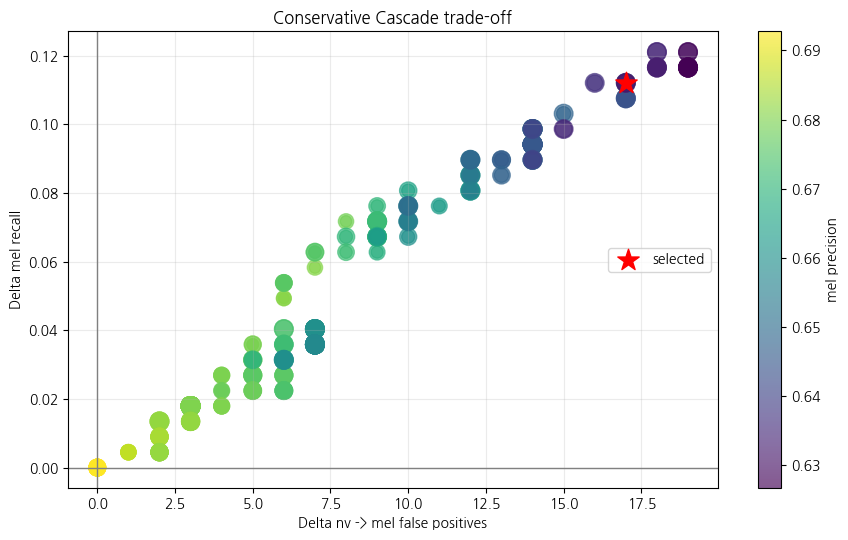

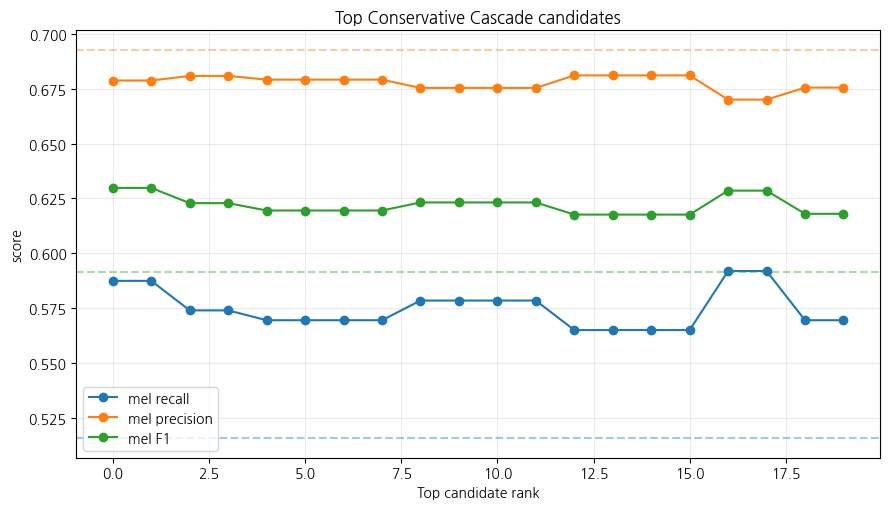


Saved files:
- conservative_cascade_sweep.csv
- conservative_cascade_filtered_candidates.csv
- conservative_cascade_predictions.csv
- conservative_cascade_summary.csv

Final Summary
selected_source: filtered practical candidate
mode: score_boost
gate_threshold: 0.200000
expert_threshold: 0.500000
boost_alpha: 0.400000
baseline_accuracy: 0.847728
baseline_macro_auroc: 0.969942
baseline_mel_precision: 0.692771
baseline_mel_recall: 0.515695
baseline_mel_f1: 0.591260
baseline_mel_FN: 108
baseline_mel_to_nv: 87
baseline_nv_to_mel: 35
cascade_accuracy: 0.849725
cascade_macro_auroc: 0.970140
cascade_mel_precision: 0.645161
cascade_mel_recall: 0.627803
cascade_mel_f1: 0.636364
cascade_mel_FN: 83
cascade_mel_to_nv: 69
cascade_nv_to_mel: 52
delta_accuracy: 0.001997
delta_macro_auroc: 0.000198
delta_mel_precision: -0.047610
delta_mel_recall: 0.112108
delta_mel_f1: 0.045104
delta_mel_FN: -25
delta_mel_to_nv: -18
delta_nv_to_mel: 17
gate_count: 252
expert_count: 823
update_count: 216


In [34]:
# ============================================================
# Conservative Cascade Expert Experiment
# 목적:
# - 기존 Cascade가 mel recall은 크게 올렸지만 precision / nv->mel FP가 크게 악화됨
# - 더 보수적인 gate, expert threshold, boost 방식으로 균형점 탐색
#
# 필요 변수:
# - ys
# - base_probs
# - ovr_mel_probs
# - CLASSES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
)

# ------------------------------------------------------------
# Safety checks
# ------------------------------------------------------------
required_vars = ["ys", "base_probs", "ovr_mel_probs", "CLASSES"]
missing = [v for v in required_vars if v not in globals()]

if missing:
    raise RuntimeError(
        f"필요한 변수가 없습니다: {missing}\n"
        "먼저 model_C와 model_ovr_mel로 ys, base_probs, ovr_mel_probs를 만든 뒤 실행하세요."
    )

ys = np.asarray(ys)
base_probs = np.asarray(base_probs, dtype=np.float32)
ovr_mel_probs = np.asarray(ovr_mel_probs, dtype=np.float32)

base_probs = base_probs / base_probs.sum(axis=1, keepdims=True)

MEL_IDX = CLASSES.index("mel")
NV_IDX = CLASSES.index("nv")
NUM_CLASSES = len(CLASSES)

print("ys:", ys.shape)
print("base_probs:", base_probs.shape)
print("ovr_mel_probs:", ovr_mel_probs.shape)
print("CLASSES:", CLASSES)

# ------------------------------------------------------------
# Metric helper
# ------------------------------------------------------------
def evaluate_probs(y_true, probs, title=""):
    preds = probs.argmax(axis=1)

    acc = accuracy_score(y_true, preds)

    macro_auc = roc_auc_score(
        y_true,
        probs,
        multi_class="ovr",
        average="macro",
    )

    per_auc = roc_auc_score(
        y_true,
        probs,
        multi_class="ovr",
        average=None,
    )

    report = classification_report(
        y_true,
        preds,
        target_names=CLASSES,
        output_dict=True,
        zero_division=0,
    )

    cm = confusion_matrix(
        y_true,
        preds,
        labels=list(range(NUM_CLASSES)),
    )

    mel_fn = cm[MEL_IDX, :].sum() - cm[MEL_IDX, MEL_IDX]
    mel_to_nv = cm[MEL_IDX, NV_IDX]
    nv_to_mel = cm[NV_IDX, MEL_IDX]

    result = {
        "accuracy": acc,
        "macro_auroc": macro_auc,
        "mel_auroc": per_auc[MEL_IDX],
        "mel_precision": report["mel"]["precision"],
        "mel_recall": report["mel"]["recall"],
        "mel_f1": report["mel"]["f1-score"],
        "macro_f1": report["macro avg"]["f1-score"],
        "mel_FN": int(mel_fn),
        "mel_to_nv": int(mel_to_nv),
        "nv_to_mel": int(nv_to_mel),
    }

    return result, preds, cm


def print_result(title, result):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    for k, v in result.items():
        if isinstance(v, float):
            print(f"{k:16s}: {v:.6f}")
        else:
            print(f"{k:16s}: {v}")


# ------------------------------------------------------------
# Conservative cascade functions
# ------------------------------------------------------------
def make_conservative_cascade_probs(
    base_probs,
    ovr_mel_probs,
    gate_threshold=0.15,
    expert_threshold=0.60,
    boost_alpha=0.20,
    mode="score_boost",
):
    """
    gate_threshold:
        baseline mel probability가 이 값 이상인 샘플만 expert 적용 후보.

    expert_threshold:
        OVR expert mel probability가 이 값 이상일 때만 보정.

    boost_alpha:
        expert 확률을 얼마나 반영할지 조절.
        높을수록 recall 증가 가능성이 크지만 FP도 증가 가능.

    mode:
        score_boost:
            gate + expert 조건을 만족한 샘플에 대해서만
            mel 확률을 expert 확률 방향으로 부분 이동.

        margin_boost:
            expert가 baseline mel 확률보다 충분히 높을 때만 부분 이동.
            가장 보수적인 방식.
    """

    probs = base_probs.copy()

    gate_mask = probs[:, MEL_IDX] >= gate_threshold
    expert_mask = ovr_mel_probs >= expert_threshold

    if mode == "score_boost":
        update_mask = gate_mask & expert_mask

    elif mode == "margin_boost":
        margin_mask = (ovr_mel_probs - probs[:, MEL_IDX]) >= 0.20
        update_mask = gate_mask & expert_mask & margin_mask

    else:
        raise ValueError("mode must be 'score_boost' or 'margin_boost'")

    old_mel = probs[update_mask, MEL_IDX].copy()

    probs[update_mask, MEL_IDX] = (
        (1.0 - boost_alpha) * probs[update_mask, MEL_IDX]
        + boost_alpha * ovr_mel_probs[update_mask]
    )

    # mel 확률이 증가한 만큼 다른 클래스 확률을 비율로 줄여 전체 합 1 유지
    delta = probs[update_mask, MEL_IDX] - old_mel

    if update_mask.sum() > 0:
        other_sum = 1.0 - old_mel
        other_sum = np.clip(other_sum, 1e-8, None)

        scale = (1.0 - probs[update_mask, MEL_IDX]) / other_sum

        for c in range(NUM_CLASSES):
            if c != MEL_IDX:
                probs[update_mask, c] = probs[update_mask, c] * scale

    probs = probs / probs.sum(axis=1, keepdims=True)

    return probs, gate_mask, expert_mask, update_mask


# ------------------------------------------------------------
# Baseline evaluation
# ------------------------------------------------------------
baseline_result, baseline_pred, baseline_cm = evaluate_probs(
    ys,
    base_probs,
    title="Baseline",
)

print_result("Baseline ConvNeXt 7-class", baseline_result)

print("\nBaseline classification report")
print(classification_report(
    ys,
    baseline_pred,
    target_names=CLASSES,
    digits=4,
    zero_division=0,
))

print("\nBaseline confusion matrix")
display(pd.DataFrame(baseline_cm, index=CLASSES, columns=CLASSES))


# ------------------------------------------------------------
# Conservative sweep
# ------------------------------------------------------------
gate_thresholds = np.arange(0.10, 0.51, 0.05)
expert_thresholds = np.arange(0.50, 0.91, 0.05)
boost_alphas = [0.10, 0.20, 0.30, 0.40]
modes = ["score_boost", "margin_boost"]

rows = []

for mode in modes:
    for gate_th in gate_thresholds:
        for expert_th in expert_thresholds:
            for boost_alpha in boost_alphas:
                probs, gate_mask, expert_mask, update_mask = make_conservative_cascade_probs(
                    base_probs=base_probs,
                    ovr_mel_probs=ovr_mel_probs,
                    gate_threshold=gate_th,
                    expert_threshold=expert_th,
                    boost_alpha=boost_alpha,
                    mode=mode,
                )

                result, pred, cm = evaluate_probs(
                    ys,
                    probs,
                    title=f"{mode} gate={gate_th:.2f}, expert={expert_th:.2f}, boost={boost_alpha:.2f}",
                )

                row = result.copy()
                row["mode"] = mode
                row["gate_threshold"] = round(float(gate_th), 2)
                row["expert_threshold"] = round(float(expert_th), 2)
                row["boost_alpha"] = round(float(boost_alpha), 2)

                row["gate_count"] = int(gate_mask.sum())
                row["expert_count"] = int(expert_mask.sum())
                row["update_count"] = int(update_mask.sum())

                row["delta_accuracy"] = row["accuracy"] - baseline_result["accuracy"]
                row["delta_macro_auroc"] = row["macro_auroc"] - baseline_result["macro_auroc"]
                row["delta_mel_precision"] = row["mel_precision"] - baseline_result["mel_precision"]
                row["delta_mel_recall"] = row["mel_recall"] - baseline_result["mel_recall"]
                row["delta_mel_f1"] = row["mel_f1"] - baseline_result["mel_f1"]
                row["delta_mel_FN"] = row["mel_FN"] - baseline_result["mel_FN"]
                row["delta_mel_to_nv"] = row["mel_to_nv"] - baseline_result["mel_to_nv"]
                row["delta_nv_to_mel"] = row["nv_to_mel"] - baseline_result["nv_to_mel"]

                # 보수적 선택 점수:
                # recall 상승은 보상하되,
                # precision 하락, nv->mel 증가, macro-AUROC 하락은 강하게 패널티.
                row["selection_score"] = (
                    row["mel_recall"] * 0.30
                    + row["mel_precision"] * 0.20
                    + row["mel_f1"] * 0.25
                    + row["macro_auroc"] * 0.15
                    + row["accuracy"] * 0.10
                    - max(0, -row["delta_macro_auroc"]) * 2.00
                    - max(0, -row["delta_mel_precision"]) * 0.40
                    - max(0, row["delta_nv_to_mel"]) / len(ys) * 4.00
                )

                rows.append(row)

conservative_df = pd.DataFrame(rows)

# 기본 정렬: selection_score 우선
conservative_df = conservative_df.sort_values(
    ["selection_score", "mel_f1", "mel_recall", "macro_auroc"],
    ascending=False,
).reset_index(drop=True)

display_cols = [
    "mode",
    "gate_threshold",
    "expert_threshold",
    "boost_alpha",
    "accuracy",
    "macro_auroc",
    "mel_precision",
    "mel_recall",
    "mel_f1",
    "mel_FN",
    "mel_to_nv",
    "nv_to_mel",
    "update_count",
    "delta_accuracy",
    "delta_macro_auroc",
    "delta_mel_precision",
    "delta_mel_recall",
    "delta_mel_f1",
    "delta_mel_FN",
    "delta_mel_to_nv",
    "delta_nv_to_mel",
    "selection_score",
]

print("\nConservative Cascade top 30 by selection_score")
display(conservative_df[display_cols].head(30))

# ------------------------------------------------------------
# Candidate filters
# ------------------------------------------------------------
# 보고서용으로 쓸 만한 후보:
# - baseline보다 recall 증가
# - mel precision이 너무 무너지지 않음
# - nv->mel 증가가 baseline 대비 50건 이하
# - macro-AUROC 하락이 0.003 이하

filtered_df = conservative_df[
    (conservative_df["delta_mel_recall"] > 0)
    & (conservative_df["mel_precision"] >= 0.55)
    & (conservative_df["delta_nv_to_mel"] <= 50)
    & (conservative_df["delta_macro_auroc"] >= -0.003)
].copy()

filtered_df = filtered_df.sort_values(
    ["mel_f1", "mel_recall", "selection_score"],
    ascending=False,
).reset_index(drop=True)

print("\nFiltered practical candidates")
if len(filtered_df) > 0:
    display(filtered_df[display_cols].head(20))
    best_row = filtered_df.iloc[0]
    best_source = "filtered practical candidate"
else:
    print("조건을 만족하는 후보가 없습니다. selection_score 1위 후보를 사용합니다.")
    best_row = conservative_df.iloc[0]
    best_source = "best by selection_score"

print("\nSelected best source:", best_source)
display(pd.DataFrame([best_row])[display_cols])

# ------------------------------------------------------------
# Final selected conservative cascade
# ------------------------------------------------------------
best_probs, best_gate_mask, best_expert_mask, best_update_mask = make_conservative_cascade_probs(
    base_probs=base_probs,
    ovr_mel_probs=ovr_mel_probs,
    gate_threshold=float(best_row["gate_threshold"]),
    expert_threshold=float(best_row["expert_threshold"]),
    boost_alpha=float(best_row["boost_alpha"]),
    mode=best_row["mode"],
)

best_result, best_pred, best_cm = evaluate_probs(
    ys,
    best_probs,
    title="Selected Conservative Cascade",
)

print_result("Selected Conservative Cascade", best_result)

print("\nSelected Conservative Cascade classification report")
print(classification_report(
    ys,
    best_pred,
    target_names=CLASSES,
    digits=4,
    zero_division=0,
))

print("\nSelected Conservative Cascade confusion matrix")
display(pd.DataFrame(best_cm, index=CLASSES, columns=CLASSES))

print("\nOperating counts")
print("gate_count  :", int(best_gate_mask.sum()))
print("expert_count:", int(best_expert_mask.sum()))
print("update_count:", int(best_update_mask.sum()))

# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------
plt.figure(figsize=(9, 5.5))

plt.scatter(
    conservative_df["delta_nv_to_mel"],
    conservative_df["delta_mel_recall"],
    c=conservative_df["mel_precision"],
    s=np.clip(conservative_df["update_count"], 15, 180),
    alpha=0.65,
)

plt.colorbar(label="mel precision")
plt.axhline(0, color="gray", linewidth=1)
plt.axvline(0, color="gray", linewidth=1)

plt.scatter(
    best_row["delta_nv_to_mel"],
    best_row["delta_mel_recall"],
    marker="*",
    s=260,
    color="red",
    label="selected",
)

plt.xlabel("Delta nv -> mel false positives")
plt.ylabel("Delta mel recall")
plt.title("Conservative Cascade trade-off")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5.2))

top_plot = conservative_df.head(20).copy()
x = np.arange(len(top_plot))

plt.plot(x, top_plot["mel_recall"], marker="o", label="mel recall")
plt.plot(x, top_plot["mel_precision"], marker="o", label="mel precision")
plt.plot(x, top_plot["mel_f1"], marker="o", label="mel F1")
plt.axhline(baseline_result["mel_recall"], linestyle="--", color="tab:blue", alpha=0.4)
plt.axhline(baseline_result["mel_precision"], linestyle="--", color="tab:orange", alpha=0.4)
plt.axhline(baseline_result["mel_f1"], linestyle="--", color="tab:green", alpha=0.4)

plt.xlabel("Top candidate rank")
plt.ylabel("score")
plt.title("Top Conservative Cascade candidates")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Save outputs
# ------------------------------------------------------------
conservative_df.to_csv("conservative_cascade_sweep.csv", index=False)
filtered_df.to_csv("conservative_cascade_filtered_candidates.csv", index=False)

pred_df = pd.DataFrame({
    "true_label": ys,
    "true_dx": [CLASSES[i] for i in ys],
    "baseline_pred": baseline_pred,
    "baseline_pred_dx": [CLASSES[i] for i in baseline_pred],
    "conservative_cascade_pred": best_pred,
    "conservative_cascade_pred_dx": [CLASSES[i] for i in best_pred],
    "ovr_mel_prob": ovr_mel_probs,
    "gate_candidate": best_gate_mask,
    "expert_positive": best_expert_mask,
    "updated_by_cascade": best_update_mask,
})

for i, cls in enumerate(CLASSES):
    pred_df[f"baseline_prob_{cls}"] = base_probs[:, i]
    pred_df[f"conservative_cascade_prob_{cls}"] = best_probs[:, i]

pred_df.to_csv("conservative_cascade_predictions.csv", index=False)

summary = {
    "selected_source": best_source,
    "mode": best_row["mode"],
    "gate_threshold": float(best_row["gate_threshold"]),
    "expert_threshold": float(best_row["expert_threshold"]),
    "boost_alpha": float(best_row["boost_alpha"]),

    "baseline_accuracy": baseline_result["accuracy"],
    "baseline_macro_auroc": baseline_result["macro_auroc"],
    "baseline_mel_precision": baseline_result["mel_precision"],
    "baseline_mel_recall": baseline_result["mel_recall"],
    "baseline_mel_f1": baseline_result["mel_f1"],
    "baseline_mel_FN": baseline_result["mel_FN"],
    "baseline_mel_to_nv": baseline_result["mel_to_nv"],
    "baseline_nv_to_mel": baseline_result["nv_to_mel"],

    "cascade_accuracy": best_result["accuracy"],
    "cascade_macro_auroc": best_result["macro_auroc"],
    "cascade_mel_precision": best_result["mel_precision"],
    "cascade_mel_recall": best_result["mel_recall"],
    "cascade_mel_f1": best_result["mel_f1"],
    "cascade_mel_FN": best_result["mel_FN"],
    "cascade_mel_to_nv": best_result["mel_to_nv"],
    "cascade_nv_to_mel": best_result["nv_to_mel"],

    "delta_accuracy": best_result["accuracy"] - baseline_result["accuracy"],
    "delta_macro_auroc": best_result["macro_auroc"] - baseline_result["macro_auroc"],
    "delta_mel_precision": best_result["mel_precision"] - baseline_result["mel_precision"],
    "delta_mel_recall": best_result["mel_recall"] - baseline_result["mel_recall"],
    "delta_mel_f1": best_result["mel_f1"] - baseline_result["mel_f1"],
    "delta_mel_FN": best_result["mel_FN"] - baseline_result["mel_FN"],
    "delta_mel_to_nv": best_result["mel_to_nv"] - baseline_result["mel_to_nv"],
    "delta_nv_to_mel": best_result["nv_to_mel"] - baseline_result["nv_to_mel"],

    "gate_count": int(best_gate_mask.sum()),
    "expert_count": int(best_expert_mask.sum()),
    "update_count": int(best_update_mask.sum()),
}

pd.DataFrame([summary]).to_csv("conservative_cascade_summary.csv", index=False)

print("\nSaved files:")
print("- conservative_cascade_sweep.csv")
print("- conservative_cascade_filtered_candidates.csv")
print("- conservative_cascade_predictions.csv")
print("- conservative_cascade_summary.csv")

print("\nFinal Summary")
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")

## 21. 5-Fold CV + OOF Temperature Scaling + mel Threshold Analysis5-Fold CV + OOF Temperature Scaling + mel Threshold Analysis

In [ ]:
# ============================================================
# HAM10000 ConvNeXt + Metadata
# 5-Fold CV + OOF Temperature Scaling + mel Threshold Analysis
# ============================================================

import os
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score,
    confusion_matrix,
    precision_recall_fscore_support,
)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

# -----------------------------
# Config
# -----------------------------
SEED = 42
N_SPLITS = 5
EPOCHS = 3          # 빠른 검증용. 최종은 5~8 권장
BATCH_SIZE = 32     # 메모리 문제 있으면 16
LR = 2e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE = 224
NUM_WORKERS = 2

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

print("DEVICE:", DEVICE)
print("GPU count:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# -----------------------------
# Path auto-detect
# -----------------------------
INPUT_ROOT = Path("/kaggle/input")

metadata_candidates = list(INPUT_ROOT.rglob("HAM10000_metadata.csv"))
assert len(metadata_candidates) > 0, "HAM10000_metadata.csv 파일을 찾지 못했습니다."

META_PATH = metadata_candidates[0]
DATA_ROOT = META_PATH.parent

print("META_PATH:", META_PATH)
print("DATA_ROOT:", DATA_ROOT)

df = pd.read_csv(META_PATH)

# image path mapping
image_paths = {}
for p in INPUT_ROOT.rglob("*.jpg"):
    image_paths[p.stem] = str(p)

df["image_path"] = df["image_id"].map(image_paths)
df = df.dropna(subset=["image_path"]).reset_index(drop=True)

print("Total samples:", len(df))
print(df["dx"].value_counts())

# -----------------------------
# Label mapping
# -----------------------------
classes = sorted(df["dx"].unique())
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}
df["label"] = df["dx"].map(class_to_idx)

NUM_CLASSES = len(classes)
MEL_IDX = class_to_idx["mel"]

print("Classes:", classes)
print("mel index:", MEL_IDX)

# -----------------------------
# Dataset
# -----------------------------
class HAMMetadataDataset(Dataset):
    def __init__(self, frame, meta_array, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.meta_array = meta_array.astype(np.float32)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row["image_path"]).convert("RGB")

        if self.transform:
            image = self.transform(image)

        meta = torch.tensor(self.meta_array[idx], dtype=torch.float32)
        label = torch.tensor(row["label"], dtype=torch.long)

        return image, meta, label

train_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(15),
    T.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.10),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

valid_tfms = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

# -----------------------------
# Model
# -----------------------------
class ConvNeXtMetadataModel(nn.Module):
    def __init__(self, meta_dim, num_classes):
        super().__init__()

        weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
        self.backbone = convnext_tiny(weights=weights)

        # Important:
        # classifier 전체를 Identity로 바꾸면 [B, 768, 1, 1]이 나올 수 있음.
        # 마지막 Linear만 제거해서 [B, 768] feature를 유지.
        image_feat_dim = self.backbone.classifier[2].in_features
        self.backbone.classifier[2] = nn.Identity()

        self.meta_mlp = nn.Sequential(
            nn.Linear(meta_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.20),
            nn.Linear(64, 64),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(image_feat_dim + 64, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            nn.Linear(256, num_classes),
        )

    def forward(self, image, meta):
        image_feat = self.backbone(image)   # [B, 768]
        meta_feat = self.meta_mlp(meta)     # [B, 64]
        feat = torch.cat([image_feat, meta_feat], dim=1)
        logits = self.classifier(feat)
        return logits

# -----------------------------
# Train / Validate
# -----------------------------
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()

    total_loss = 0.0
    y_true, y_pred = [], []

    for images, metas, labels in loader:
        images = images.to(DEVICE)
        metas = metas.to(DEVICE)
        labels = labels.to(DEVICE)

        optimizer.zero_grad()
        logits = model(images, metas)
        loss = criterion(logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)

        preds = logits.argmax(dim=1)
        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)

    return avg_loss, acc


@torch.no_grad()
def validate(model, loader, criterion):
    model.eval()

    total_loss = 0.0
    y_true = []
    y_pred = []
    y_prob = []
    y_logits = []

    for images, metas, labels in loader:
        images = images.to(DEVICE)
        metas = metas.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model(images, metas)
        loss = criterion(logits, labels)

        probs = F.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        total_loss += loss.item() * labels.size(0)

        y_true.extend(labels.detach().cpu().numpy())
        y_pred.extend(preds.detach().cpu().numpy())
        y_prob.append(probs.detach().cpu().numpy())
        y_logits.append(logits.detach().cpu().numpy())

    y_prob = np.concatenate(y_prob, axis=0)
    y_logits = np.concatenate(y_logits, axis=0)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(y_true, y_pred)

    try:
        macro_auroc = roc_auc_score(
            y_true,
            y_prob,
            multi_class="ovr",
            average="macro",
        )
    except Exception:
        macro_auroc = np.nan

    return avg_loss, acc, macro_auroc, y_true, y_pred, y_prob, y_logits

# -----------------------------
# Temperature Scaling
# -----------------------------
class TemperatureScaler(nn.Module):
    def __init__(self):
        super().__init__()
        self.log_temp = nn.Parameter(torch.zeros(1))

    def forward(self, logits):
        temp = torch.exp(self.log_temp)
        return logits / temp

def fit_temperature(logits_np, labels_np, max_iter=200):
    logits = torch.tensor(logits_np, dtype=torch.float32).to(DEVICE)
    labels = torch.tensor(labels_np, dtype=torch.long).to(DEVICE)

    scaler = TemperatureScaler().to(DEVICE)
    optimizer = torch.optim.LBFGS([scaler.log_temp], lr=0.1, max_iter=max_iter)
    criterion = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        scaled_logits = scaler(logits)
        loss = criterion(scaled_logits, labels)
        loss.backward()
        return loss

    optimizer.step(closure)

    temp = torch.exp(scaler.log_temp).item()

    with torch.no_grad():
        scaled_probs = F.softmax(scaler(logits), dim=1).cpu().numpy()

    return temp, scaled_probs

def expected_calibration_error(y_true, y_prob, n_bins=15):
    confidences = y_prob.max(axis=1)
    predictions = y_prob.argmax(axis=1)
    accuracies = predictions == y_true

    ece = 0.0
    bin_edges = np.linspace(0.0, 1.0, n_bins + 1)

    for i in range(n_bins):
        low, high = bin_edges[i], bin_edges[i + 1]
        mask = (confidences > low) & (confidences <= high)

        if mask.sum() > 0:
            bin_acc = accuracies[mask].mean()
            bin_conf = confidences[mask].mean()
            ece += (mask.sum() / len(y_true)) * abs(bin_acc - bin_conf)

    return ece

# -----------------------------
# mel threshold sweep
# -----------------------------
def apply_mel_threshold(y_prob, mel_idx, threshold):
    preds = y_prob.argmax(axis=1)

    mel_prob = y_prob[:, mel_idx]
    preds = preds.copy()
    preds[mel_prob >= threshold] = mel_idx

    return preds

def sweep_mel_threshold(y_true, y_prob, mel_idx):
    rows = []

    for th in np.arange(0.05, 0.81, 0.05):
        pred = apply_mel_threshold(y_prob, mel_idx, th)

        acc = accuracy_score(y_true, pred)
        p, r, f1, _ = precision_recall_fscore_support(
            y_true,
            pred,
            labels=[mel_idx],
            zero_division=0,
        )

        cm = confusion_matrix(y_true, pred, labels=list(range(NUM_CLASSES)))
        mel_fn = cm[mel_idx, :].sum() - cm[mel_idx, mel_idx]
        mel_to_nv = cm[mel_idx, class_to_idx["nv"]] if "nv" in class_to_idx else np.nan
        nv_to_mel = cm[class_to_idx["nv"], mel_idx] if "nv" in class_to_idx else np.nan

        rows.append({
            "threshold": round(float(th), 2),
            "accuracy": acc,
            "mel_precision": p[0],
            "mel_recall": r[0],
            "mel_f1": f1[0],
            "mel_FN": int(mel_fn),
            "mel_to_nv": int(mel_to_nv),
            "nv_to_mel": int(nv_to_mel),
        })

    result = pd.DataFrame(rows)

    # 의료 스크리닝 관점: recall 우선, precision/F1 붕괴 방지
    result["selection_score"] = (
        result["mel_recall"] * 0.60
        + result["mel_f1"] * 0.30
        + result["accuracy"] * 0.10
    )

    return result.sort_values("selection_score", ascending=False).reset_index(drop=True)

# -----------------------------
# 5-Fold CV
# -----------------------------
meta_cols_numeric = ["age"]
meta_cols_categorical = ["sex", "localization"]

df["age"] = df["age"].fillna(df["age"].median())
df["sex"] = df["sex"].fillna("unknown")
df["localization"] = df["localization"].fillna("unknown")

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)

oof_logits = np.zeros((len(df), NUM_CLASSES), dtype=np.float32)
oof_probs = np.zeros((len(df), NUM_CLASSES), dtype=np.float32)
oof_labels = df["label"].values.copy()
fold_summaries = []

for fold, (train_idx, valid_idx) in enumerate(skf.split(df, df["label"]), start=1):
    print("\n" + "=" * 70)
    print(f"Fold {fold}/{N_SPLITS}")
    print("=" * 70)

    train_df = df.iloc[train_idx].reset_index(drop=True)
    valid_df = df.iloc[valid_idx].reset_index(drop=True)

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), meta_cols_numeric),
            ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), meta_cols_categorical),
        ]
    )

    train_meta = preprocessor.fit_transform(train_df)
    valid_meta = preprocessor.transform(valid_df)

    meta_dim = train_meta.shape[1]
    print("meta_dim:", meta_dim)

    train_ds = HAMMetadataDataset(train_df, train_meta, transform=train_tfms)
    valid_ds = HAMMetadataDataset(valid_df, valid_meta, transform=valid_tfms)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    valid_loader = DataLoader(
        valid_ds,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
    )

    model = ConvNeXtMetadataModel(meta_dim=meta_dim, num_classes=NUM_CLASSES).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=LR,
        weight_decay=WEIGHT_DECAY,
    )

    best_macro_auroc = -1
    best_pack = None

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        valid_loss, valid_acc, valid_auroc, y_true, y_pred, y_prob, y_logits = validate(
            model,
            valid_loader,
            criterion,
        )

        print(
            f"[Fold {fold} | Epoch {epoch}] "
            f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
            f"valid_loss={valid_loss:.4f} valid_acc={valid_acc:.4f} "
            f"macro_AUROC={valid_auroc:.6f}"
        )

        if valid_auroc > best_macro_auroc:
            best_macro_auroc = valid_auroc
            best_pack = {
                "y_true": y_true,
                "y_pred": y_pred,
                "y_prob": y_prob,
                "y_logits": y_logits,
                "valid_acc": valid_acc,
                "valid_auroc": valid_auroc,
            }

    oof_logits[valid_idx] = best_pack["y_logits"]
    oof_probs[valid_idx] = best_pack["y_prob"]

    fold_summaries.append({
        "fold": fold,
        "valid_acc": best_pack["valid_acc"],
        "macro_auroc": best_pack["valid_auroc"],
    })

    print(f"Fold {fold} best macro_AUROC:", best_pack["valid_auroc"])

# -----------------------------
# OOF Evaluation
# -----------------------------
print("\n" + "=" * 70)
print("OOF Evaluation")
print("=" * 70)

oof_pred = oof_probs.argmax(axis=1)

oof_acc = accuracy_score(oof_labels, oof_pred)
oof_macro_auroc = roc_auc_score(
    oof_labels,
    oof_probs,
    multi_class="ovr",
    average="macro",
)

print("OOF Accuracy:", oof_acc)
print("OOF Macro-AUROC:", oof_macro_auroc)

print("\nOOF Classification Report")
print(classification_report(
    oof_labels,
    oof_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
))

# class-wise AUROC
print("\nOOF Class-wise AUROC")
for i, cls in enumerate(classes):
    binary_true = (oof_labels == i).astype(int)
    cls_auc = roc_auc_score(binary_true, oof_probs[:, i])
    print(f"{cls:5s}: {cls_auc:.6f}")

# -----------------------------
# OOF Temperature Scaling
# -----------------------------
print("\n" + "=" * 70)
print("OOF Temperature Scaling")
print("=" * 70)

nll_before = F.cross_entropy(
    torch.tensor(oof_logits, dtype=torch.float32),
    torch.tensor(oof_labels, dtype=torch.long),
).item()

ece_before = expected_calibration_error(oof_labels, oof_probs)

best_temp, calibrated_probs = fit_temperature(oof_logits, oof_labels)

nll_after = F.cross_entropy(
    torch.tensor(np.log(np.clip(calibrated_probs, 1e-8, 1.0)), dtype=torch.float32),
    torch.tensor(oof_labels, dtype=torch.long),
).item()

ece_after = expected_calibration_error(oof_labels, calibrated_probs)

calibrated_pred = calibrated_probs.argmax(axis=1)
calibrated_acc = accuracy_score(oof_labels, calibrated_pred)
calibrated_macro_auroc = roc_auc_score(
    oof_labels,
    calibrated_probs,
    multi_class="ovr",
    average="macro",
)

print(f"Temperature: {best_temp:.4f}")
print(f"NLL before: {nll_before:.6f}")
print(f"NLL after : {nll_after:.6f}")
print(f"ECE before: {ece_before:.6f}")
print(f"ECE after : {ece_after:.6f}")
print(f"Calibrated Accuracy: {calibrated_acc:.6f}")
print(f"Calibrated Macro-AUROC: {calibrated_macro_auroc:.6f}")

# -----------------------------
# OOF mel Threshold Sweep
# -----------------------------
print("\n" + "=" * 70)
print("OOF mel Threshold Sweep after Calibration")
print("=" * 70)

threshold_result = sweep_mel_threshold(
    y_true=oof_labels,
    y_prob=calibrated_probs,
    mel_idx=MEL_IDX,
)

print(threshold_result.head(15))

best_threshold_row = threshold_result.iloc[0]
best_threshold = best_threshold_row["threshold"]

print("\nBest threshold by selection_score")
print(best_threshold_row)

best_threshold_pred = apply_mel_threshold(
    calibrated_probs,
    MEL_IDX,
    best_threshold,
)

print("\nClassification Report with Best mel Threshold")
print(classification_report(
    oof_labels,
    best_threshold_pred,
    target_names=classes,
    digits=4,
    zero_division=0,
))

cm = confusion_matrix(oof_labels, best_threshold_pred, labels=list(range(NUM_CLASSES)))
print("\nConfusion Matrix")
print(pd.DataFrame(cm, index=classes, columns=classes))

# -----------------------------
# Save Results
# -----------------------------
fold_summary_df = pd.DataFrame(fold_summaries)

oof_result_df = pd.DataFrame({
    "image_id": df["image_id"],
    "true_label": oof_labels,
    "true_dx": df["dx"],
    "pred_before_threshold": oof_pred,
    "pred_before_threshold_dx": [idx_to_class[i] for i in oof_pred],
    "pred_after_threshold": best_threshold_pred,
    "pred_after_threshold_dx": [idx_to_class[i] for i in best_threshold_pred],
})

for i, cls in enumerate(classes):
    oof_result_df[f"prob_{cls}"] = oof_probs[:, i]
    oof_result_df[f"calibrated_prob_{cls}"] = calibrated_probs[:, i]

fold_summary_df.to_csv("cv_fold_summary.csv", index=False)
threshold_result.to_csv("cv_oof_mel_threshold_sweep.csv", index=False)
oof_result_df.to_csv("cv_oof_predictions_calibrated.csv", index=False)

summary = {
    "n_splits": N_SPLITS,
    "epochs": EPOCHS,
    "oof_accuracy": oof_acc,
    "oof_macro_auroc": oof_macro_auroc,
    "temperature": best_temp,
    "nll_before": nll_before,
    "nll_after": nll_after,
    "ece_before": ece_before,
    "ece_after": ece_after,
    "calibrated_accuracy": calibrated_acc,
    "calibrated_macro_auroc": calibrated_macro_auroc,
    "best_mel_threshold": best_threshold,
    "best_threshold_mel_precision": best_threshold_row["mel_precision"],
    "best_threshold_mel_recall": best_threshold_row["mel_recall"],
    "best_threshold_mel_f1": best_threshold_row["mel_f1"],
    "best_threshold_mel_FN": best_threshold_row["mel_FN"],
    "best_threshold_mel_to_nv": best_threshold_row["mel_to_nv"],
    "best_threshold_nv_to_mel": best_threshold_row["nv_to_mel"],
}

pd.DataFrame([summary]).to_csv("cv_calibration_threshold_summary.csv", index=False)

print("\nSaved files:")
print("- cv_fold_summary.csv")
print("- cv_oof_mel_threshold_sweep.csv")
print("- cv_oof_predictions_calibrated.csv")
print("- cv_calibration_threshold_summary.csv")

print("\nFinal Summary")
for k, v in summary.items():
    print(f"{k}: {v}")